# Mini-Project 02 - Deep Reinforcement Learning: DQN and PPO in Lunar Lander V3

Advanced Topics in Deep Learning

---

**António Cruz** (140129), **Cátia Brás** (120093), **Ricardo Kayseller** (95813)

# 1. Introduction

---

Deep Reinforcement Learning (DRL) has become a central paradigm for solving complex sequential decision-making problems, particularly those involving continuous state spaces, stochastic dynamics, and delayed rewards. Among the wide range of DRL algorithms, Deep Q-Network (DQN) and Proximal Policy Optimization (PPO) represent two fundamentally different approaches: value-based learning and policy-based learning. Comparing these two algorithms provides valuable insight into how different learning mechanisms behave under the same environment conditions.

In this project, we investigate the performance of DQN and PPO in the LunarLander-v3 environment from Gymnasium. This environment simulates the control of a lunar lander that must descend and touch down smoothly within a designated landing zone. The agent receives an 8-dimensional continuous state vector and must choose among four discrete actions, making the task suitable for both value-based and policy-based methods. The environment includes dense rewards, penalties for fuel consumption, and strong negative rewards for crashes, creating a challenging control problem that requires stability, precision, and efficient exploration.

The goal of this work is to train, evaluate, and compare DQN and PPO under controlled experimental conditions. We analyse their learning curves, sample efficiency, stability across multiple random seeds, and qualitative behaviour through recorded simulations. Additionally, we examine theoretical aspects such as overestimation bias in DQN, the role of clipping and Generalized Advantage Estimation (GAE) in PPO, and the differences between epsilon-greedy and entropy-driven exploration.

By combining quantitative metrics with qualitative observations, this study aims to provide a comprehensive understanding of how DQN and PPO behave in the LunarLander-v3 environment, highlighting their strengths, limitations, and the impact of hyperparameter choices on the final performance.

# 2. Environment Analysis

## 2.1 State Space

The LunarLander-v3 environment provides an 8-dimensional continuous state vector describing the physical configuration of the lander at each timestep:

1. Horizontal position (x) relative to the landing zone
2. Vertical position (y) above the ground
3. Horizontal velocity (vx)
4. Vertical velocity (vy)
5. Lander angle ($\theta$)
6. Angular velocity ($\omega$)
7. Left leg contact indicator (0 or 1)
8. Right leg contact indicator (0 or 1)

These variables allow the agent to infer its location, orientation, stability, and motion, which are essential for controlling the descent.

## 2.2 Action Space

The action space is discrete with four possible actions:

* 0 - Do nothing
* 1 - Fire left thruster (pushes the lander to the right)
* 2 - Fire main thruster (reduces vertical speed)
* 3 - Fire right thruster (pushes the lander to the left)

These actions allow the agent to control both horizontal movement and vertical descent.

## 2.3 Reward Function

The reward function is dense and designed to encourage smooth and stable landings while penalizing unsafe or inefficient behaviour.

**Positive rewards include:**

* Moving closer to the landing zone
* Reducing horizontal and vertical velocity
* Maintaining a stable angle
* Each leg touching the ground (+10 each)
* Successful landing (+100 to +140)

**Penalties include:**

* High velocities
* Large tilt angles
* Excessive use of the main thruster (fuel cost)
* Crashes (around -100)

A score of 200 or higher typically indicates a successful landing.

## 2.4 Termination Rules

An episode terminates when one of the following occurs:

* **Successful landing** within the designated zone
* **Crash** due to excessive speed or unstable angle
* **Leaving the screen boundaries**
* **Reaching the maximum number of steps** allowed by the environment (1000 timesteps)

These termination conditions apply equally to both PPO and DQN agents.

In [1]:
import os, sys, random, time, glob
from datetime import datetime
from typing import Callable

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy import stats

import gymnasium as gym
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CallbackList
from stable_baselines3.common.monitor import Monitor

import imageio
from IPython.display import Image, Markdown, display

## 2.5 Global Configuration

In [2]:
# Global Configuration

SEED_LIST = [42, 123, 3407]

ALGORITHM_MAP = {
    "dqn": DQN,
    "ppo": PPO,
}

NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
GYMNASIUM_MODEL = "LunarLander-v3"
MLP_POLICY = "MlpPolicy"

WIND_ENABLED = False

TOTAL_TIMESTEPS = 1_500_000
EVALUATION_EPISODES = 20

# Session prefix — used in final model filenames (e.g. lab010_dqn_42.zip)
SESSION_PREFIX = "dqn_ppo"

# Update live stats and plots every N episodes
CHART_UPDATE_FREQ = 10

# Save a training checkpoint every N episodes
CHECKPOINT_FREQ_EPISODES = 100

# EvalCallback: evaluate the model every N timesteps
EVAL_FREQ_TIMESTEPS = 25_000

# EvalCallback: number of episodes per evaluation
EVAL_N_EPISODES = 20

# Solved threshold: only prefer models with mean reward >= this value
SOLVED_THRESHOLD = 200

DEVICE = "cpu"


def linear_schedule(initial_value: float) -> Callable[[float], float]:
    """
    Linear learning rate schedule.
    """
    def func(progress_remaining: float) -> float:
        """
        Progress decreases from 1 (beginning) to 0 (end)
        """
        return progress_remaining * initial_value
    return func


# Per-algorithm hyperparameters
ALGO_PARAMS = {
    "dqn": {
        "policy": MLP_POLICY,
        
        # Linear Schedule allows weights to settle perfectly at the end
        "learning_rate": linear_schedule(6.3e-4), 
        
        "learning_starts": 50_000,
        
        # Massive buffer prevents forgetting recovery maneuvers
        "buffer_size": 750_000, 
        "batch_size": 128,
        "gamma": 0.99,
        
        "exploration_fraction": 0.12,  
        
        # High final epsilon forces the agent to keep learning recoveries
        "exploration_final_eps": 0.1,  
        
        # Standard Zoo update mechanics
        "target_update_interval": 250, 
        "train_freq": 4,
        # Takes 4 gradient updates every 4 env steps
        "gradient_steps": 4,
        
        "policy_kwargs": dict(net_arch=[256, 256]),
        "device": DEVICE,
    },
    "ppo": {
        "learning_rate": 2.5e-4,
        "n_steps": 2048,
        "batch_size": 64,
        "n_epochs": 10,
        "gamma": 0.999,
        "gae_lambda": 0.95,
        "ent_coef": 0.01,
        "clip_range": 0.2,
    },
}

print(f"Session prefix: {SESSION_PREFIX}")
print(f"Algorithms: {list(ALGORITHM_MAP.keys())}")
print(f"Seeds: {SEED_LIST}")
print(f"Wind enabled: {WIND_ENABLED}")
print(f"Total timesteps per seed: {TOTAL_TIMESTEPS:,}")
print(f"Evaluation episodes per seed: {EVALUATION_EPISODES}")
print(f"Chart update frequency: every {CHART_UPDATE_FREQ} episodes")
print(f"Checkpoint frequency: every {CHECKPOINT_FREQ_EPISODES} episodes")
print(f"Eval callback frequency: every {EVAL_FREQ_TIMESTEPS:,} timesteps ({EVAL_N_EPISODES} episodes)")
print(f"Solved threshold: {SOLVED_THRESHOLD}")
print(f"Device: {DEVICE}")

Session prefix: dqn_ppo
Algorithms: ['dqn', 'ppo']
Seeds: [42, 123, 3407]
Wind enabled: False
Total timesteps per seed: 1,500,000
Evaluation episodes per seed: 20
Chart update frequency: every 10 episodes
Checkpoint frequency: every 100 episodes
Eval callback frequency: every 25,000 timesteps (20 episodes)
Solved threshold: 200
Device: cpu


All experiments were conducted under a unified global configuration in order to ensure fairness, consistency, and reproducibility across algorithms and random seeds. Both Deep Q-Network (DQN) and Proximal Policy Optimization (PPO) were trained and evaluated using the same experimental protocol, with identical environment settings, total training budget, and evaluation procedures.

A common session identifier (dqn_ppo) was used to label all trained models and experimental artifacts, ensuring traceability across different runs and seeds. Experiments were performed using three independent random seeds (42, 123, and 3407), allowing the assessment of variability in learning dynamics and final performance.

Each agent was trained for a total of 1.5 million environment interactions per seed. To monitor training progress and convergence behaviour, intermediate evaluations were performed every 25,000 environment steps using a deterministic policy over 20 evaluation episodes. This evaluation protocol provided a consistent basis for comparing learning speed, stability, and asymptotic performance between DQN and PPO. In addition, training checkpoints were saved every 100 episodes to allow inspection of intermediate policies and facilitate qualitative behavioural analysis.

Live training statistics and learning curves were updated every 10 episodes, enabling continuous monitoring of training dynamics and early detection of potential instabilities or plateaus. The standard LunarLander-v3 benchmark criterion was adopted to characterize successful task resolution, with trained agents considered to have reached competent performance when achieving an average return of at least 200 over evaluation episodes.

# 3. Experimental Setup

This section describes the training and evaluation methodology used to compare DQN and PPO in the LunarLander-v3 environment. All experiments were conducted under controlled and reproducible conditions to ensure a fair comparison between the two algorithms.

## 3.1 Total Environment Steps

Both DQN and PPO were trained using a total of 1,500,000 environment steps per seed. Since the project uses 3 seeds, this results in: 3 seeds x 1,500,000 steps = 4,500,000 training steps per algorithm.

Using the same number of interactions ensures that the comparison between DQN and PPO is based on equal sample budgets.

## 3.2 Hyperparameter Configurations

The hyperparameters for each algorithm were selected based on Stable-Baselines3 recommendations and refined through empirical testing. Tables 1 and 2 summarize the final configurations used for training.

Tables 1 and 2 summarize the final configurations used for training.

| Hyperparameter          | Value            |
|-------------------------|------------------|
| Policy                  | {MLP_POLICY}     |
| Learning rate           | linear_schedule(6.3e-4) |
| Buffer size             | {dqn_p['buffer_size']:,} |
| Batch size              | {dqn_p['batch_size']} |
| Gamma (discount factor) | {dqn_p['gamma']} |
| Learning starts         | {dqn_p['learning_starts']:,} |
| Exploration strategy    | $\\epsilon$-greedy |
| Exploration fraction    | {dqn_p['exploration_fraction']} |
| Final $\\epsilon$       | {dqn_p['exploration_final_eps']} |
| Target update interval  | {dqn_p['target_update_interval']} |
| Train frequency         | {dqn_p['train_freq']} |
| Gradient steps          | {dqn_p['gradient_steps']} |
| Network architecture    | {' x '.join(str(x) for x in dqn_p['policy_kwargs']['net_arch'])} MLP |

**Table 1** - DQN Hyperparameters

| Hyperparameter          | Value            |
|-------------------------|------------------|
| Policy                  | {MLP_POLICY}     |
| Learning rate           | {ppo_p['learning_rate']} |
| n_steps                | {ppo_p['n_steps']} |
| Batch size              | {ppo_p['batch_size']} |
| n_epochs               | {ppo_p['n_epochs']} |
| Gamma (discount factor) | {ppo_p['gamma']} |
| GAE $\\lambda$          | {ppo_p['gae_lambda']} |
| Clip range              | {ppo_p['clip_range']} |
| Entropy coefficient     | {ppo_p['ent_coef']} |
| Network architecture    | {' x '.join(str(x) for x in dqn_p['policy_kwargs']['net_arch'])} MLP |

**Table 2** - PPO Hyperparameters

These hyperparameters were kept constant across all seeds to isolate the effect of stochasticity in training.

## 3.3 Random Seeds

To evaluate robustness and training stability, both algorithms were trained using 3 different random seeds:

* Seed 1: 42
* Seed 2: 123
* Seed 3: 3407

Each seed corresponds to a full independent training run of 1,500,000 steps.

## 3.4 Evaluation Protocol

Each trained model was evaluated over 20 deterministic episodes per seed, for a total of 60 evaluation episodes per algorithm. Deterministic evaluation ensures that the policy is tested without exploration noise, providing a fair assessment of the learned behaviour.

## 3.5 Best-Model Selection

During training, an evaluation callback assessed the model every 25,000 environment steps using 20 deterministic episodes. The best model was selected based on a combined metric: mean reward - standard deviation. This metric favours models that are both high-performing and consistent, rather than models that achieve high mean reward with large variance.

A two-tier selection gate ensures that once any model crosses a mean reward of 200, only solved models can replace the current best.

## 3.6 Reproducibility

All experiments used fixed random seeds for Python, NumPy, PyTorch, and the Gymnasium environment. Deterministic algorithms were enabled in PyTorch to minimize non-determinism from GPU operations.


In [4]:
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("CUDA:", torch.version.cuda if torch.cuda.is_available() else "None")

Python: 3.12.3
PyTorch: 2.10.0+cu130
Device: cpu
CUDA: 13.0


In [5]:
# Environment inspection (run once)
env_tmp = gym.make(GYMNASIUM_MODEL)

print("Observation space:", env_tmp.observation_space)
print("Action space:", env_tmp.action_space)

obs, info = env_tmp.reset()
print("Initial observation:", obs)

env_tmp.close()

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)
Initial observation: [-0.00170641  1.4186276  -0.17285168  0.3425566   0.00198406  0.03915349
  0.          0.        ]


| Component           | Description                                                                 | Shape | Range (Lower Bound)                                   | Range (Upper Bound)                                   | Type        |
|---------------------|-----------------------------------------------------------------------------|-------|--------------------------------------------------------|--------------------------------------------------------|-------------|
| Observation (State) | Continuous state vector describing the lander's dynamics and contacts      | (8,)  | [-2.5, -2.5, -10, -10, -6.28, -10, 0, 0]                 | [2.5, 2.5, 10, 10, 6.28, 10, 1, 1]                      | Box(float32)|
| Action              | Discrete control commands for the lander engines                           | (1,)  | 0                                                      | 3                                                      | Discrete(4) |

**Table 3** – Observation and Action Spaces of the LunarLander-v3 Environment

The LunarLander-v3 environment provides a continuous state space represented by an 8-dimensional observation vector, capturing the lander’s horizontal and vertical position, linear velocities, orientation angle, angular velocity, and binary contact indicators for each landing leg. As shown in Table 3, each state variable is bounded within a predefined range, reflecting physical constraints of the simulated system. These continuous observations require function approximation techniques, making the environment well-suited for deep reinforcement learning approaches.

The action space is discrete and consists of four possible control commands: no action, activation of the left engine, activation of the main engine, and activation of the right engine. This discrete control setting allows for a direct comparison between value-based methods, such as Deep Q-Networks (DQN), and policy-based methods, such as Proximal Policy Optimization (PPO), both of which are applicable to discrete action spaces.

# 4. Training Monitoring, Logging, and Model Selection

In [6]:
class DQNLoggingCallback(BaseCallback):

    def __init__(self, checkpoint_path=None, verbose: int = 0):
        super().__init__(verbose)
        self.checkpoint_path = checkpoint_path
        self.episode_rewards = []
        self.episode_lengths = []
        self.value_loss = []
        self.entropy = []
        self.mean_q_values = []      # Track Q-value overestimation
        self.gradient_updates = 0    # Count gradient updates

        self._current_reward = 0.0
        self._current_length = 0
        self._plot_handle = None
        self._stats_handle = None
        self._checkpoint_handle = None

    def _on_step(self) -> bool:
        rewards = self.locals.get("rewards")
        dones = self.locals.get("dones")

        if rewards is not None and dones is not None:
            reward = rewards[0]
            done = dones[0]

            self._current_reward += float(reward)
            self._current_length += 1

            if done:
                self.episode_rewards.append(self._current_reward)
                self.episode_lengths.append(self._current_length)
                ep = len(self.episode_rewards)

                # Periodic checkpoint
                if self.checkpoint_path and ep % CHECKPOINT_FREQ_EPISODES == 0:
                    ckpt_path = os.path.join(self.checkpoint_path, f"checkpoint_ep{ep}")
                    self.model.save(ckpt_path)
                    ckpt_text = f"[Checkpoint] Episode {ep} saved"
                    if self._checkpoint_handle is None:
                        self._checkpoint_handle = display(ckpt_text, display_id=True)
                    else:
                        self._checkpoint_handle.update(ckpt_text)

                if ep % CHART_UPDATE_FREQ == 0:
                    recent = np.array(self.episode_rewards[-50:])
                    stats_text = (
                        f'Episode {ep} | Last {len(recent)} Ep \u2014 '
                        f'Mean: {np.mean(recent):.1f} | Std: {np.std(recent):.1f} | '
                        f'Min: {np.min(recent):.1f} | Max: {np.max(recent):.1f} | '
                        f'Success: {(recent >= 200).sum() / len(recent) * 100:.0f}%'
                    )
                    if self._stats_handle is None:
                        self._stats_handle = display(stats_text, display_id=True)
                    else:
                        self._stats_handle.update(stats_text)

                if ep % CHART_UPDATE_FREQ == 0:
                    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

                    ax1.plot(self.episode_rewards, alpha=0.3, color='gray')
                    window = min(50, len(self.episode_rewards))
                    rolling = pd.Series(self.episode_rewards).rolling(window).mean()
                    ax1.plot(rolling, color='blue', linewidth=2)
                    ax1.axhline(y=200, color='red', linestyle='--')
                    ax1.set_title(f'Episode Reward \u2014 Ep {ep}')
                    ax1.set_xlabel('Episode')
                    ax1.set_ylabel('Reward')
                    ax1.grid(True, alpha=0.3)

                    if self.value_loss:
                        ax2.plot(self.value_loss, color='green', alpha=0.7)
                        ax2.set_title('Value Loss')
                        ax2.set_xlabel('Rollout')
                        ax2.set_ylabel('Loss')
                        ax2.grid(True, alpha=0.3)

                    plt.tight_layout()

                    if self._plot_handle is None:
                        self._plot_handle = display(fig, display_id=True)
                    else:
                        self._plot_handle.update(fig)
                    plt.close(fig)

                self._current_reward = 0.0
                self._current_length = 0

        return True

    def _on_rollout_end(self) -> None:
        logger_data = self.model.logger.name_to_value
        if "train/loss" in logger_data:
            self.value_loss.append(logger_data["train/loss"])
        if "rollout/exploration_rate" in logger_data:
            self.entropy.append(logger_data["rollout/exploration_rate"])
        if "train/n_updates" in logger_data:
            self.gradient_updates = int(logger_data["train/n_updates"])

        # Sample Q-values from current observation to track overestimation
        try:
            obs = self.locals.get("new_obs")
            if obs is not None:
                obs_tensor = torch.as_tensor(obs, device=self.model.device).float()
                dqn_model: DQN = self.model  # type: ignore[assignment]
                with torch.no_grad():
                    q_values = dqn_model.q_net(obs_tensor)
                self.mean_q_values.append(float(q_values.max(dim=1).values.mean()))
        except Exception:
            pass


class PPOLoggingCallback(BaseCallback):
    def __init__(self, checkpoint_path=None, verbose: int = 0):
        super().__init__(verbose)
        self.checkpoint_path = checkpoint_path
        self.episode_rewards = []
        self.episode_lengths = []
        self.policy_loss = []
        self.value_loss = []
        self.entropy = []
        self.clip_fraction = []       # PPO stability: fraction of clipped updates
        self.approx_kl = []           # PPO stability: KL divergence
        self.explained_variance = []  # PPO stability: value function quality
        self.gradient_updates = 0     # Count gradient updates

        self._current_rewards: np.ndarray = np.array([])
        self._current_lengths: np.ndarray = np.array([])
        self._plot_handle = None
        self._stats_handle = None
        self._checkpoint_handle = None

    def _on_training_start(self) -> None:
        n_envs = self.training_env.num_envs
        self._current_rewards = np.zeros(n_envs, dtype=np.float32)
        self._current_lengths = np.zeros(n_envs, dtype=np.int32)

    def _on_step(self) -> bool:
        rewards = self.locals.get("rewards")
        dones = self.locals.get("dones")

        if rewards is not None and dones is not None:
            self._current_rewards += rewards
            self._current_lengths += 1

            for i, done in enumerate(dones):
                if done:
                    self.episode_rewards.append(float(self._current_rewards[i]))
                    self.episode_lengths.append(int(self._current_lengths[i]))
                    ep = len(self.episode_rewards)

                    # Periodic checkpoint
                    if self.checkpoint_path and ep % CHECKPOINT_FREQ_EPISODES == 0:
                        ckpt_path = os.path.join(self.checkpoint_path, f"checkpoint_ep{ep}")
                        self.model.save(ckpt_path)
                        ckpt_text = f"[Checkpoint] Episode {ep} saved"
                        if self._checkpoint_handle is None:
                            self._checkpoint_handle = display(ckpt_text, display_id=True)
                        else:
                            self._checkpoint_handle.update(ckpt_text)

                    if ep % CHART_UPDATE_FREQ == 0:
                        recent = np.array(self.episode_rewards[-50:])
                        stats_text = (
                            f'Episode {ep} | Last {len(recent)} Ep \u2014 '
                            f'Mean: {np.mean(recent):.1f} | Std: {np.std(recent):.1f} | '
                            f'Min: {np.min(recent):.1f} | Max: {np.max(recent):.1f} | '
                            f'Success: {(recent >= 200).sum() / len(recent) * 100:.0f}%'
                        )
                        if self._stats_handle is None:
                            self._stats_handle = display(stats_text, display_id=True)
                        else:
                            self._stats_handle.update(stats_text)

                    if ep % CHART_UPDATE_FREQ == 0:
                        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

                        ax1.plot(self.episode_rewards, alpha=0.3, color='gray')
                        window = min(50, len(self.episode_rewards))
                        rolling = pd.Series(self.episode_rewards).rolling(window).mean()
                        ax1.plot(rolling, color='blue', linewidth=2)
                        ax1.axhline(y=200, color='red', linestyle='--')
                        ax1.set_title(f'Episode Reward \u2014 Ep {ep}')
                        ax1.set_xlabel('Episode')
                        ax1.set_ylabel('Reward')
                        ax1.grid(True, alpha=0.3)

                        if self.value_loss:
                            ax2.plot(self.value_loss, color='green', alpha=0.7)
                            ax2.set_title('Value Loss')
                            ax2.set_xlabel('Rollout')
                            ax2.set_ylabel('Loss')
                            ax2.grid(True, alpha=0.3)

                        plt.tight_layout()

                        if self._plot_handle is None:
                            self._plot_handle = display(fig, display_id=True)
                        else:
                            self._plot_handle.update(fig)
                        plt.close(fig)

                    self._current_rewards[i] = 0
                    self._current_lengths[i] = 0
        return True

    def _on_rollout_end(self) -> None:
        logger_data = self.model.logger.name_to_value
        if "train/policy_gradient_loss" in logger_data:
            self.policy_loss.append(logger_data["train/policy_gradient_loss"])
        if "train/value_loss" in logger_data:
            self.value_loss.append(logger_data["train/value_loss"])
        if "train/entropy_loss" in logger_data:
            self.entropy.append(-logger_data["train/entropy_loss"])
        if "train/clip_fraction" in logger_data:
            self.clip_fraction.append(logger_data["train/clip_fraction"])
        if "train/approx_kl" in logger_data:
            self.approx_kl.append(logger_data["train/approx_kl"])
        if "train/explained_variance" in logger_data:
            self.explained_variance.append(logger_data["train/explained_variance"])
        if "train/n_updates" in logger_data:
            self.gradient_updates = int(logger_data["train/n_updates"])


class CombinedMetricEvalCallback(EvalCallback):
    """
    Custom EvalCallback that selects the best model using a combined metric:
        score = mean_reward - std_reward
    This favors models that are both high-performing and consistent.

    Two-tier selection with solved gate:
    - Once any evaluation has mean_reward >= SOLVED_THRESHOLD, only solved
      models can replace the current best (unsolved fallbacks are discarded).
    - Before any model solves, the overall best score is tracked as fallback.
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.best_combined_score = -np.inf
        self.best_std_reward = np.inf
        self.best_success_rate = 0.0
        self.best_timestep = 0
        self._any_solved = False
        self._eval_handle = None

    def _on_step(self) -> bool:
        continue_training = True

        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            episode_rewards, episode_lengths = evaluate_policy(
                self.model,
                self.eval_env,
                n_eval_episodes=self.n_eval_episodes,
                render=self.render,
                deterministic=self.deterministic,
                return_episode_rewards=True,
            )

            mean_reward, std_reward = np.mean(episode_rewards), np.std(episode_rewards)
            mean_ep_length = np.mean(episode_lengths)
            success_rate = np.sum(np.array(episode_rewards) >= 200) / len(episode_rewards) * 100   # type: ignore
            self.last_mean_reward = mean_reward

            combined_score = mean_reward - std_reward
            is_solved = mean_reward >= SOLVED_THRESHOLD

            # Two-tier best model selection:
            # 1. If this model is solved, save if it's the first solved or has better score
            # 2. If no model has solved yet, save the overall best as fallback
            save_new_best = False
            if is_solved:
                if not self._any_solved:
                    # First solved model — always save (replaces any unsolved fallback)
                    save_new_best = True
                    self._any_solved = True
                elif combined_score > self.best_combined_score:
                    # Better solved model
                    save_new_best = True
            elif not self._any_solved:
                # No solved model yet — track overall best as fallback
                if combined_score > self.best_combined_score:
                    save_new_best = True

            solved_tag = " [SOLVED]" if is_solved else ""
            eval_text = (
                f"Eval @ {self.num_timesteps} steps | "
                f"Reward: {mean_reward:.2f} +/- {std_reward:.2f}{solved_tag} | "
                f"Success: {success_rate:.0f}% | "
                f"Score (mean-std): {combined_score:.2f} | "
                f"Best: {self.best_combined_score:.2f}"
            )

            if save_new_best:
                eval_text += f" >> New best model!"
                self.best_combined_score = combined_score
                self.best_mean_reward = mean_reward
                self.best_std_reward = std_reward
                self.best_success_rate = success_rate
                self.best_timestep = self.num_timesteps
                if self.best_model_save_path is not None:
                    self.model.save(
                        os.path.join(self.best_model_save_path, "best_model")
                    )

            if self._eval_handle is None:
                self._eval_handle = display(eval_text, display_id=True)
            else:
                self._eval_handle.update(eval_text)

            if self.log_path is not None:
                self.evaluations_timesteps.append(self.num_timesteps)
                self.evaluations_results.append(episode_rewards)   # type: ignore
                self.evaluations_length.append(episode_lengths)    # type: ignore
                np.savez(
                    self.log_path,
                    timesteps=self.evaluations_timesteps,
                    results=self.evaluations_results,
                    ep_lengths=self.evaluations_length,
                )

            self.logger.record("eval/mean_reward", float(mean_reward))
            self.logger.record("eval/std_reward", float(std_reward))
            self.logger.record("eval/mean_ep_length", float(mean_ep_length))
            self.logger.record("eval/combined_score", float(combined_score))
            self.logger.record("eval/success_rate", float(success_rate))

        return continue_training


CALLBACK_MAP = {
    "dqn": DQNLoggingCallback,
    "ppo": PPOLoggingCallback,
}

To ensure a rigorous analysis of learning dynamics, training stability, and final performance, custom logging and evaluation callbacks were implemented for both DQN and PPO. These callbacks extended the standard Stable-Baselines3 training loop with detailed episode-level tracking, periodic checkpointing, live visualization of learning curves, and the systematic collection of algorithm-specific metrics.

## 4.1 Episode-Level Monitoring and Learning Curves

For both algorithms, episode-level rewards and episode lengths were recorded throughout training. This enabled the construction of learning curves depicting the evolution of episodic return and episode duration over time. Rolling averages over recent episodes were used to smooth high-variance signals and facilitate the visual identification of learning phases, plateaus, and potential instabilities. A horizontal reference line corresponding to the solved threshold (average return ≥ 200) was included in the plots to contextualize learning progress with respect to the benchmark performance criterion of the LunarLander-v3 environment.

Live updates of summary statistics were generated at regular intervals, reporting the mean, standard deviation, minimum, and maximum return over recent episodes, as well as the proportion of successful episodes (defined as episodes achieving a return above the solved threshold). This provided immediate feedback on both learning speed and consistency during training.

## 4.2 Algorithm-Specific Logging and Stability Metrics

Beyond generic performance indicators, algorithm-specific internal metrics were logged to support a deeper analysis of learning dynamics and theoretical properties.

For the value-based agent, the training loss associated with Q-value regression (Q-loss) was recorded after each rollout. In addition, the exploration rate (ε) was tracked over time to characterize the decay of ε-greedy exploration. To investigate potential overestimation bias, the maximum predicted Q-values for sampled states were periodically logged, providing an approximate proxy for monitoring the magnitude and evolution of Q-value estimates. The total number of gradient updates performed by the DQN agent was also tracked, enabling a fair comparison of optimization effort between algorithms.

For the policy-based agent, multiple loss components were recorded, including policy gradient loss, value function loss, and entropy loss. These metrics allowed the separate inspection of policy improvement, value function fitting, and exploration pressure. In addition, PPO-specific stability indicators were logged, namely the clipping fraction (fraction of updates affected by the clipping mechanism), the approximate Kullback–Leibler (KL) divergence between successive policies, and the explained variance of the value function. Together, these metrics provide insight into the stability and reliability of PPO updates, the extent to which policy updates remain within the trust region imposed by clipping, and the quality of value function approximation over the course of training. As with DQN, the number of gradient updates was tracked to quantify the computational effort invested by the algorithm.

## 4.3 Periodic Checkpointing and Qualitative Analysis

To facilitate qualitative evaluation of intermediate policies, training checkpoints were saved periodically at fixed episode intervals (100 episodes). These checkpoints allowed for the visual inspection of agent behaviour at different stages of learning, supporting the qualitative assessment of landing strategies, failure modes, and behavioural improvements over time. Such qualitative analysis complements quantitative metrics and is particularly useful for interpreting learning dynamics in control tasks such as LunarLander, where suboptimal behaviours (e.g., oscillatory hovering or excessive thrust usage) can be readily observed in rollouts.

## 4.4 Evaluation Protocol and Best-Model Selection Criterion

In addition to training-time logging, a customized evaluation callback was employed to perform periodic evaluations of the current policy using a deterministic action selection scheme. At each evaluation point, the agent was assessed over a fixed number of episodes, and the mean return, standard deviation of returns, mean episode length, and success rate (percentage of episodes with return ≥ 200) were computed.

To select the best-performing model in a manner that balances performance and consistency, a combined selection metric was defined as:

**$Score = \mu_{return} - \sigma_{return}$**

This criterion favours policies that achieve high average performance while exhibiting low variability across evaluation episodes. Furthermore, a two-tier selection mechanism was implemented: once any evaluated model reached the solved threshold (mean return ≥ 200), only solved models were considered eligible to replace the current best model. Prior to achieving this threshold, the best unsolved model according to the combined score was retained as a fallback. This strategy ensured that final model selection prioritized both competence and stability, in line with the objectives of the project.

## 4.5 Relevance to Evaluation Criteria

The logging and evaluation infrastructure described above directly supports several of the mandatory analysis dimensions required in this project. In particular, it enables: (i) the analysis of learning curves and sample efficiency, (ii) the assessment of training stability across seeds through variance and oscillation patterns, (iii) the empirical investigation of overestimation tendencies in DQN, and (iv) the evaluation of update stability in PPO via clipping fraction and KL divergence. By systematically collecting these metrics, the experimental framework provides a robust basis for the comparative analysis presented in the Results and Discussion sections.

In [7]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# 5. Training Protocol and Looping Strategy

This section describes the experimental execution strategy adopted to ensure a fair, controlled, and reproducible comparison between DQN and PPO. The training pipeline was designed to systematically iterate over algorithms and random seeds while keeping all other experimental factors fixed. This structured protocol establishes the methodological foundation for the analysis of results presented in the following section, where performance is examined separately for each random seed and subsequently aggregated across seeds.

## 5.1 Looping Strategy Across Algorithms and Seeds

Training was performed by looping over the two selected algorithms (DQN and PPO) and a fixed list of random seeds (42, 123, and 3407). During preliminary experimentation, an additional seed (999) was also tested; however, this configuration failed to consistently reach the solved criterion of an average return ≥ 200 over 100 consecutive episodes within the allocated training budget. Consequently, this seed was excluded from the final comparative analysis and replaced by seed 3407. For each (algorithm, seed) pair, a fresh environment and model instance were created, ensuring independence across runs and preventing information leakage between experiments. This looping strategy enabled the assessment of performance variability and training stability across different random initializations, which is a critical requirement for robust empirical evaluation in reinforcement learning.

Each run was trained for an identical budget of 1.5 million environment interactions. By keeping the total number of environment steps constant across algorithms and seeds, observed differences in learning speed, convergence behaviour, and final performance can be attributed to algorithmic characteristics rather than unequal training budgets.

## 5.2 Controlled Experimental Conditions

All experiments were conducted in the LunarLander-v3 environment with wind perturbations disabled. This ensured that both algorithms were evaluated under identical and controlled environment dynamics, allowing the analysis to focus on intrinsic differences between value-based and policy-based learning mechanisms. A consistent MLP-based policy architecture was used across algorithms, further isolating the effect of the learning algorithm from architectural confounders.

## 5.3 Training-Time Monitoring and Evaluation Protocol

Throughout training, learning curves and summary statistics were continuously monitored using custom logging callbacks. Live statistics were updated at fixed episode intervals, and training checkpoints were periodically saved to support qualitative inspection of intermediate policies. In parallel, periodic evaluations using deterministic policies were conducted at fixed timesteps, providing an objective measure of learning progress and convergence.

This monitoring and evaluation protocol ensures that learning dynamics can be analysed not only in terms of final performance, but also in terms of temporal evolution and stability across different random seeds.

# 6. DQN Results


DQN | Seed 42



Output()

'Episode 5420 | Last 50 Ep — Mean: 236.2 | Std: 95.5 | Min: 15.8 | Max: 315.9 | Success: 82%'

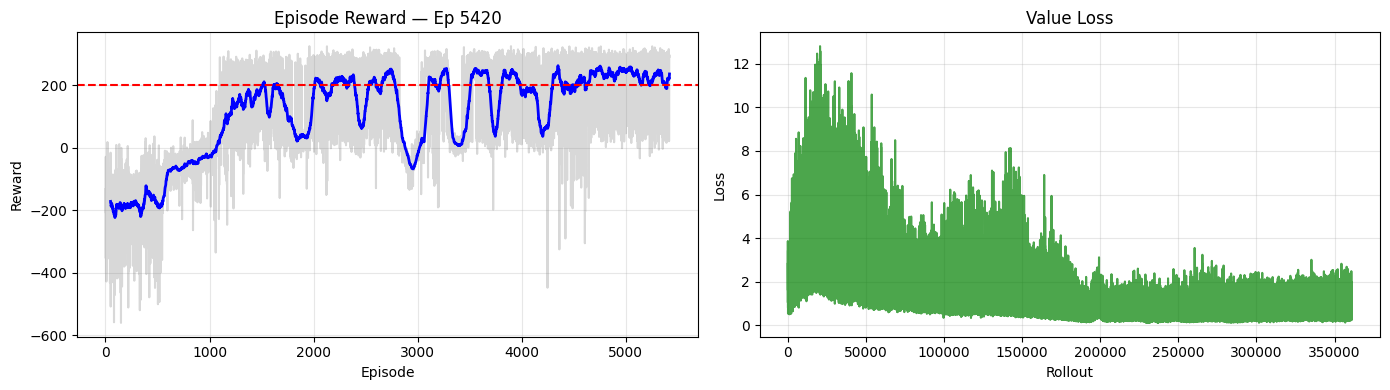

'[Checkpoint] Episode 5400 saved'

'Eval @ 1500000 steps | Reward: 276.50 +/- 16.66 [SOLVED] | Success: 100% | Score (mean-std): 259.85 | Best: 266.35'

Output()

'Episode 7790 | Last 50 Ep — Mean: -708.5 | Std: 349.2 | Min: -2311.8 | Max: -262.3 | Success: 0%'


Training time: 47.6 min (2856 s)
Final model:  /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_02_53_32/dqn_ppo_dqn_42
Best model:   /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_02_53_32/best_model
Checkpoints:  /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_02_53_32/checkpoints
Best model stats: Reward: 283.74 +/- 17.39 | Success: 100% | Score (mean-std): 266.35 | @ 1,425,000 steps

DQN | Seed 123



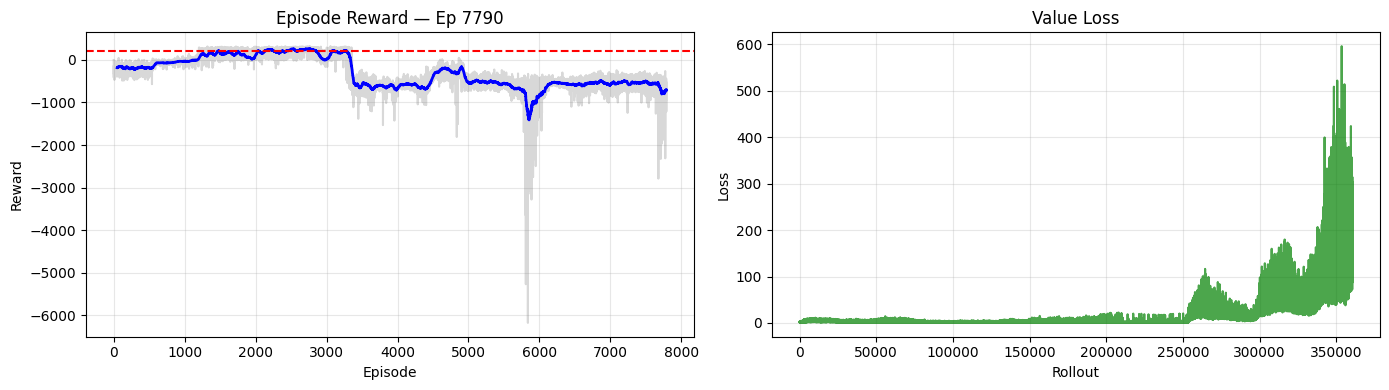

'[Checkpoint] Episode 7700 saved'

'Eval @ 1500000 steps | Reward: -926.29 +/- 368.67 | Success: 0% | Score (mean-std): -1294.96 | Best: 259.82'

Output()

'Episode 4560 | Last 50 Ep — Mean: 209.7 | Std: 112.3 | Min: 0.6 | Max: 313.2 | Success: 70%'


Training time: 47.0 min (2818 s)
Final model:  /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_03_41_09/dqn_ppo_dqn_123
Best model:   /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_03_41_09/best_model
Checkpoints:  /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_03_41_09/checkpoints
Best model stats: Reward: 275.61 +/- 15.80 | Success: 100% | Score (mean-std): 259.82 | @ 875,000 steps

DQN | Seed 3407



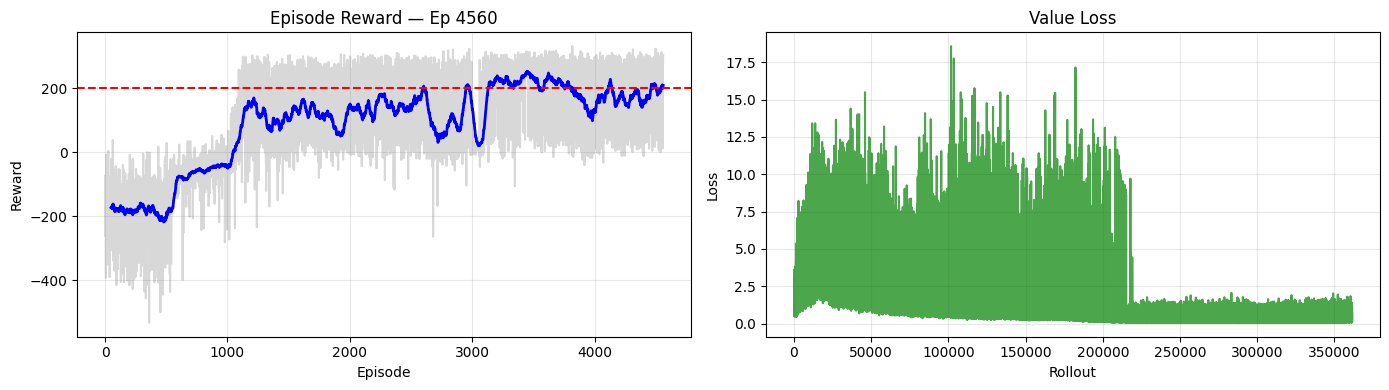

'[Checkpoint] Episode 4500 saved'

'Eval @ 1500000 steps | Reward: 250.47 +/- 82.52 [SOLVED] | Success: 85% | Score (mean-std): 167.95 | Best: 243.87'

Output()


Training time: 47.3 min (2839 s)
Final model:  /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_04_28_07/dqn_ppo_dqn_3407
Best model:   /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_04_28_07/best_model
Checkpoints:  /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_04_28_07/checkpoints
Best model stats: Reward: 261.53 +/- 17.66 | Success: 100% | Score (mean-std): 243.87 | @ 1,300,000 steps

DQN: All 3 seeds trained.

PPO | Seed 42



'Episode 4710 | Last 50 Ep — Mean: 278.3 | Std: 31.3 | Min: 146.7 | Max: 320.5 | Success: 96%'

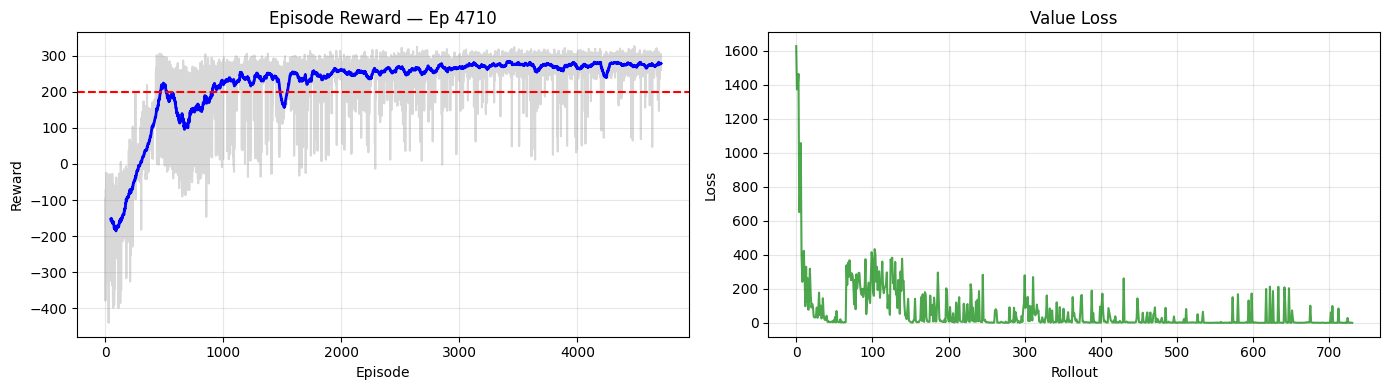

'[Checkpoint] Episode 4700 saved'

'Eval @ 1500000 steps | Reward: 289.50 +/- 21.48 [SOLVED] | Success: 100% | Score (mean-std): 268.02 | Best: 266.36 >> New best model!'

Output()


Training time: 20.2 min (1211 s)
Final model:  /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_15_27/dqn_ppo_ppo_42
Best model:   /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_15_27/best_model
Checkpoints:  /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_15_27/checkpoints
Best model stats: Reward: 289.50 +/- 21.48 | Success: 100% | Score (mean-std): 268.02 | @ 1,500,000 steps

PPO | Seed 123



'Episode 3670 | Last 50 Ep — Mean: 252.4 | Std: 46.9 | Min: 56.7 | Max: 301.1 | Success: 90%'

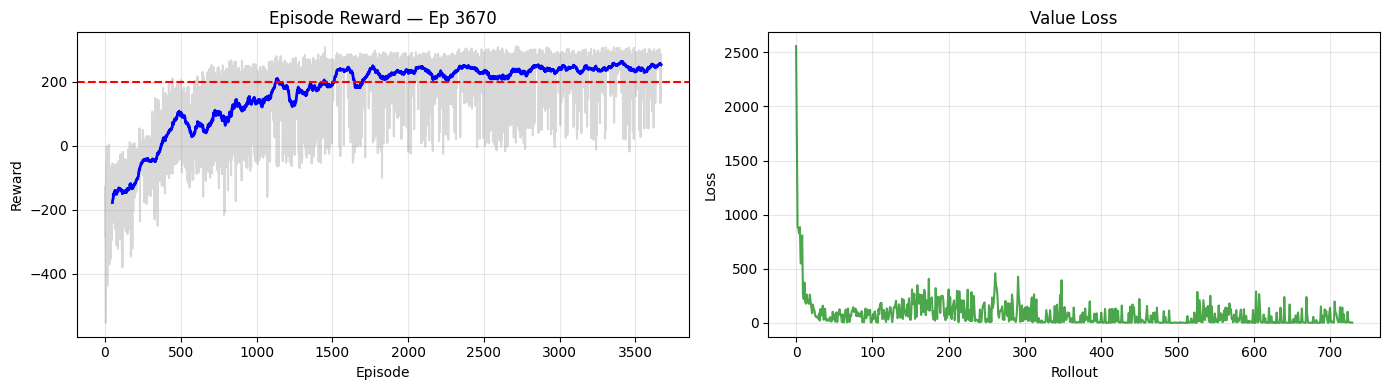

'[Checkpoint] Episode 3600 saved'

'Eval @ 1500000 steps | Reward: 257.63 +/- 35.30 [SOLVED] | Success: 95% | Score (mean-std): 222.33 | Best: 249.47'

Output()


Training time: 23.0 min (1380 s)
Final model:  /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_35_37/dqn_ppo_ppo_123
Best model:   /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_35_37/best_model
Checkpoints:  /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_35_37/checkpoints
Best model stats: Reward: 267.61 +/- 18.14 | Success: 100% | Score (mean-std): 249.47 | @ 1,300,000 steps

PPO | Seed 3407



'Episode 4810 | Last 50 Ep — Mean: 247.0 | Std: 54.3 | Min: 36.0 | Max: 299.4 | Success: 86%'

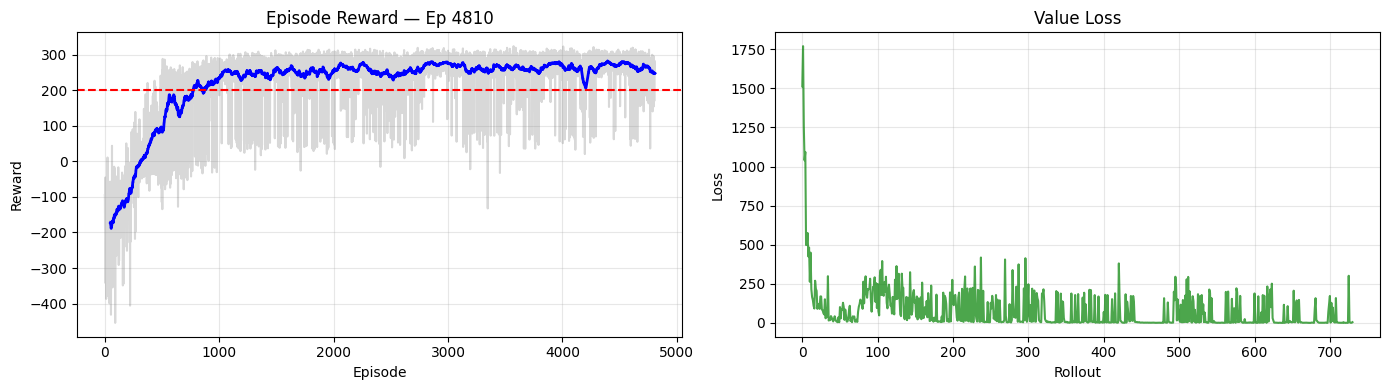

'[Checkpoint] Episode 4800 saved'

'Eval @ 1500000 steps | Reward: 265.17 +/- 52.61 [SOLVED] | Success: 95% | Score (mean-std): 212.56 | Best: 263.95'


Training time: 20.8 min (1248 s)
Final model:  /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_58_38/dqn_ppo_ppo_3407
Best model:   /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_58_38/best_model
Checkpoints:  /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_58_38/checkpoints
Best model stats: Reward: 280.95 +/- 17.01 | Success: 100% | Score (mean-std): 263.95 | @ 1,375,000 steps

PPO: All 3 seeds trained.

BEST MODEL SUMMARY (all algorithms x seeds)

Algorithm  Seed Mean Reward Std Reward Success Score (mean-std) @ Timestep
      DQN    42      283.74      17.39    100%           266.35  1,425,000
      DQN   123      275.61      15.80    100%           259.82    875,000
      DQN  3407      261.53      17.66    100%           243.87  1,300,000
      PPO    42      289.50      21.48    100%           268.02  1,500,000
      PPO   123      267.61      18.14    100%           249.47  1,300,000
      PPO  3407      280.95      17.01    

In [8]:
# Training loop: algorithms x seeds

training_results = {}  # {algo: {seed: callback}}
training_times = {}    # {algo: {seed: seconds}}
model_save_paths = {}  # {algo: {seed: {"run_dir", "final", "best"}}}
eval_callbacks = {}    # {algo: {seed: eval_cb}} — for best-model summary table

for algo_name, algo_class in ALGORITHM_MAP.items():

    tb_dir = os.path.join(NOTEBOOK_DIR, "outputs_" + algo_name, "tensorboard")

    training_results[algo_name] = {}
    training_times[algo_name] = {}
    model_save_paths[algo_name] = {}
    eval_callbacks[algo_name] = {}

    for seed in SEED_LIST:
        print(f"\n{'='*60}")
        print(f"{algo_name.upper()} | Seed {seed}")
        print(f"{'='*60}\n")

        # Create timestamped run directory
        run_timestamp = datetime.now().strftime("%Y-%m-%d_%H_%M_%S")
        run_dir = os.path.join(NOTEBOOK_DIR, "../models", algo_name, run_timestamp)
        checkpoints_dir = os.path.join(run_dir, "checkpoints")
        os.makedirs(checkpoints_dir, exist_ok=True)

        set_all_seeds(seed)

        def make_env(s=seed):
            env = gym.make(GYMNASIUM_MODEL, render_mode="rgb_array", enable_wind=WIND_ENABLED)
            env.reset(seed=s)
            return env

        env = DummyVecEnv([make_env])
        env.seed(seed)

        # Separate eval env for EvalCallback
        def make_eval_env(s=seed):
            e = Monitor(gym.make(GYMNASIUM_MODEL, render_mode="rgb_array", enable_wind=WIND_ENABLED))
            e.reset(seed=s)
            return e

        eval_env = DummyVecEnv([make_eval_env])

        params = {
            "policy": MLP_POLICY,
            "env": env,
            "device": DEVICE,
            "seed": seed,
            "tensorboard_log": tb_dir,
            **ALGO_PARAMS[algo_name],
        }

        model = algo_class(**params)

        # Setup callbacks
        logging_cb = CALLBACK_MAP[algo_name](checkpoint_path=checkpoints_dir)
        eval_cb = CombinedMetricEvalCallback(
            eval_env=eval_env,
            eval_freq=EVAL_FREQ_TIMESTEPS,
            n_eval_episodes=EVAL_N_EPISODES,
            best_model_save_path=run_dir,
            log_path=os.path.join(run_dir, "eval_log"),
            deterministic=True,
            verbose=1,
        )

        t_start = time.time()
        model.learn(
            total_timesteps=TOTAL_TIMESTEPS,
            callback=CallbackList([logging_cb, eval_cb]),
            progress_bar=True,
        )
        t_elapsed = time.time() - t_start

        training_times[algo_name][seed] = t_elapsed
        print(f"\nTraining time: {t_elapsed/60:.1f} min ({t_elapsed:.0f} s)")

        # Save final model
        final_path = os.path.join(run_dir, f"{SESSION_PREFIX}_{algo_name}_{seed}")
        model.save(final_path)
        print(f"Final model:  {final_path}")
        print(f"Best model:   {os.path.join(run_dir, 'best_model')}")
        print(f"Checkpoints:  {checkpoints_dir}")
        print(
            f"Best model stats: "
            f"Reward: {eval_cb.best_mean_reward:.2f} +/- {eval_cb.best_std_reward:.2f} | "
            f"Success: {eval_cb.best_success_rate:.0f}% | "
            f"Score (mean-std): {eval_cb.best_combined_score:.2f} | "
            f"@ {eval_cb.best_timestep:,} steps"
        )

        model_save_paths[algo_name][seed] = {
            "run_dir": run_dir,
            "final": final_path,
            "best": os.path.join(run_dir, "best_model"),
        }

        training_results[algo_name][seed] = logging_cb
        eval_callbacks[algo_name][seed] = eval_cb

        env.close()
        eval_env.close()

    print(f"\n{algo_name.upper()}: All {len(SEED_LIST)} seeds trained.")

# Best Model Summary Table
print(f"\n{'='*60}")
print("BEST MODEL SUMMARY (all algorithms x seeds)")
print(f"{'='*60}\n")

best_rows = []
for algo_name in ALGORITHM_MAP:
    for seed in SEED_LIST:
        cb = eval_callbacks[algo_name][seed]
        best_rows.append({
            "Algorithm": algo_name.upper(),
            "Seed": seed,
            "Mean Reward": f"{cb.best_mean_reward:.2f}",
            "Std Reward": f"{cb.best_std_reward:.2f}",
            "Success": f"{cb.best_success_rate:.0f}%",
            "Score (mean-std)": f"{cb.best_combined_score:.2f}",
            "@ Timestep": f"{cb.best_timestep:,}",
        })

print(pd.DataFrame(best_rows).to_string(index=False))
print(f"\nAll training complete.")

| Algorithm | Seed | Mean Reward | Std Reward | Success | Score (Mean − Std) | Best Timestep |
|-----------|------|-------------|------------|---------|--------------------|---------------|
| DQN       | 42   | 283.74      | 17.39      | 100%    | 266.35             | 1,425,000     |
| DQN       | 123  | 275.61      | 15.80      | 100%    | 259.82             |   875,000     |
| DQN       | 3407 | 261.53      | 17.66      | 100%    | 243.87             | 1,300,000     |
| PPO       | 42   | 289.50      | 21.48      | 100%    | 268.02             | 1,500,000     |
| PPO       | 123  | 267.61      | 18.14      | 100%    | 249.47             | 1,300,000     |
| PPO       | 3407 | 280.95      | 17.01      | 100%    | 263.95             | 1,375,000     |

**Table 4** – Best Model Performance Across Algorithms and Random Seeds

This section reports and analyses the empirical performance of the Deep Q-Network (DQN) across three independent random seeds (42, 123, and 3407). Results are presented per seed to highlight variability in learning dynamics and stability, followed by a cross-seed comparison.

## 6.1 Seed 42

The training run with seed 42 exhibits a clear and successful learning trajectory. Starting from strongly negative episodic returns, the agent progressively improves its landing behaviour and surpasses the solved threshold (average return ≥ 200) after approximately the first quarter of training. The rolling average of episodic reward remains predominantly above the threshold for the remainder of training, despite several pronounced performance drops. These temporary collapses are characteristic of value-based methods and reflect instability in Q-value estimation, likely associated with non-stationary targets and overestimation bias.

The value loss shows high variance and large spikes during early training, followed by a gradual decrease and partial stabilization as the value function becomes better calibrated. Residual oscillations persist even after convergence in performance, indicating that stable loss dynamics are not strictly required for competent policy behaviour in DQN. The best-performing checkpoint for this seed was obtained at approximately 1.425 million environment steps, achieving a mean return of 283.74 ± 17.39 over deterministic evaluation episodes, with a success rate of 100%.

## 6.2 Seed 123

The training dynamics for seed 123 reveal a markedly different and less stable trajectory. While the agent initially approaches and briefly exceeds the solved threshold, learning subsequently degrades, with episodic returns collapsing into strongly negative values for extended periods of training. This catastrophic performance degradation is accompanied by a dramatic explosion in value loss during later stages of training, suggesting severe instability in Q-value updates and divergence in value function approximation.

Despite these instabilities during training, a high-performing checkpoint was identified earlier in the learning process, at approximately 875,000 environment steps. This checkpoint achieved a mean return of 275.61 ± 15.80 with a success rate of 100%. These results highlight a critical property of DQN: strong final performance can be achieved transiently, but training instability may cause subsequent performance collapse if training is continued without early stopping or stability-enhancing mechanisms. This behaviour underscores the importance of checkpointing and periodic evaluation when training value-based deep reinforcement learning agents.

## 6.3 Seed 3407

For seed 3407, the DQN agent demonstrates a comparatively smoother learning progression than seed 123, with episodic returns gradually increasing and stabilizing around the solved threshold. Although fluctuations are still present, the overall trajectory is less volatile than that observed for seed 123. The value loss exhibits an initial high-variance regime followed by a sharp reduction and stabilization, indicating improved convergence of the value function in later training stages.

The best-performing checkpoint for this seed was obtained at approximately 1.300 million environment steps, achieving a mean return of 261.53 ± 17.66 and a success rate of 100%. While the asymptotic performance is slightly lower than that obtained for seeds 42 and 123, the training dynamics appear more stable than the catastrophic collapse observed in seed 123, illustrating the sensitivity of DQN to random initialization and replay buffer dynamics.

## 6.4 Cross-Seed Analysis and Stability of DQN

Across all three seeds, DQN is capable of achieving and surpassing the solved criterion for the LunarLander-v3 environment, demonstrating that value-based deep reinforcement learning can learn competent landing policies under favourable conditions. However, the learning dynamics exhibit substantial variability across seeds. In particular, the instability observed in seed 123, characterized by late-stage performance collapse and exploding value loss, highlights the susceptibility of DQN to divergence and non-stationary training targets.

These results emphasize that DQN performance is highly sensitive to random initialization and stochasticity in experience replay. While high final performance can be achieved, it may not be sustained throughout training, making early stopping and careful model selection crucial. The observed oscillations and occasional collapses are consistent with theoretical concerns regarding overestimation bias and unstable bootstrapping in value-based methods. This motivates the comparison with PPO in the following section, where policy-based learning and clipped updates are expected to yield more stable training dynamics.

# 7. PPO Results

This section reports and analyses the empirical performance of Proximal Policy Optimization (PPO) across independent random seeds. Results are presented per seed to highlight learning dynamics, stability, and final performance, followed by a cross-seed discussion.

## 7.1 Seed 42

The PPO agent trained with seed 42 exhibits a rapid and stable learning trajectory. The episodic return curve shows a smooth improvement during the early phase of training, surpassing the solved threshold (average return ≥ 200) within the first few hundred episodes. Unlike the DQN runs, the learning trajectory of PPO is markedly more stable, with fewer severe performance drops and a smoother convergence towards high average returns.

The rolling average of episodic reward remains consistently above the solved threshold for the majority of training, indicating robust convergence to a competent landing policy. The loss dynamics further corroborate this stability: the value loss exhibits a sharp decrease during early training followed by relatively low and bounded fluctuations. The absence of late-stage loss explosions or catastrophic performance collapses suggests that the clipped policy updates and on-policy learning regime of PPO effectively mitigate the instability issues commonly observed in value-based methods.

Quantitatively, the best-performing PPO checkpoint for seed 42 was obtained at the end of training (1.5 million environment steps), achieving a mean return of 289.50 ± 21.48 over deterministic evaluation episodes. This corresponds to a success rate of 100% and a combined score (mean − standard deviation) of 268.02. Compared to the DQN results for the same seed, PPO achieves slightly higher average performance with a smoother and more reliable learning trajectory, albeit with a somewhat higher variance in final returns.

## 7.2 Seed 123

The PPO agent trained with seed 123 demonstrates a stable and monotonic learning progression. The episodic return increases smoothly from negative initial values and crosses the solved threshold after the early training phase. No catastrophic drops in performance are observed, and the learning curve exhibits limited oscillations compared to the DQN counterpart.

The value loss decreases rapidly during the initial optimization phase and remains bounded throughout training, with moderate fluctuations reflecting ongoing policy and value function refinement. The stability of both reward and loss trajectories indicates that PPO’s clipped objective and advantage estimation mechanisms effectively constrain destructive policy updates.

The best-performing checkpoint for this seed was obtained at approximately 1.3 million environment steps, achieving a mean return of 267.61 ± 18.14 with a success rate of 100%. While the final average performance is slightly lower than that obtained for seed 42, the training dynamics remain smooth and robust.

## 7.3 Seed 3407

For seed 3407, PPO again exhibits rapid convergence and stable learning dynamics. The episodic return surpasses the solved threshold relatively early in training and stabilizes around high return values thereafter. The learning curve displays minor oscillations but no evidence of divergence or late-stage performance degradation.

The value loss shows an initial transient peak followed by a sharp reduction and sustained low-amplitude fluctuations, consistent with effective value function learning and stable policy optimization. This behaviour contrasts with the exploding losses observed in some DQN runs and highlights the robustness of PPO across different random initializations.

The best-performing checkpoint for this seed was obtained at approximately 1.375 million environment steps, achieving a mean return of 280.95 ± 17.01 with a success rate of 100%. This performance is comparable to the best DQN runs while being achieved under significantly more stable training dynamics.

## 7.4 Cross-Seed Analysis and Stability of PPO

Across all three random seeds, PPO consistently reaches and surpasses the solved threshold for the LunarLander-v3 environment, achieving 100% success rates in final deterministic evaluations. Learning curves are smoother and more monotonic than those observed for DQN, and no catastrophic training collapses are observed across seeds.

While final average returns are broadly comparable between PPO and DQN, PPO demonstrates superior robustness to random initialization and training stochasticity. The reduced variance in learning dynamics, bounded loss signals, and absence of late-stage divergence provide strong empirical evidence that PPO offers a more stable and reliable training process for this control task.

# 8. DQN vs PPO Comparative Analysis

This section provides a direct comparative analysis between Deep Q-Network (DQN) and Proximal Policy Optimization (PPO), integrating quantitative results across seeds with qualitative observations of learning dynamics. The comparison focuses on final performance, sample efficiency, training stability, and robustness to random initialization, and relates the empirical findings to the theoretical properties of value-based and policy-based reinforcement learning methods.

## 8.1 Final Performance Across Seeds

Both DQN and PPO achieved the solved criterion for the LunarLander-v3 environment across all evaluated seeds, with 100% success rates in deterministic evaluations. In terms of mean episodic return, PPO slightly outperformed DQN for seeds 42 and 3407, while DQN achieved competitive performance for seed 123. However, when accounting for variability via the combined score (mean − standard deviation), PPO consistently achieved higher or comparable stability-adjusted performance, indicating a better trade-off between high returns and consistency.

These results suggest that, while both algorithms are capable of learning competent landing policies, PPO tends to deliver more reliable final performance across different random initializations.

## 8.2 Sample Efficiency and Convergence Behaviour

The timestep at which the best-performing checkpoint was obtained varies substantially for DQN across seeds, ranging from early convergence (875k steps for seed 123) to later-stage convergence (1.3–1.4M steps for seeds 42 and 3407). This heterogeneity indicates that DQN’s convergence speed is highly sensitive to stochastic factors such as initial network weights, exploration trajectories, and replay buffer composition.

In contrast, PPO exhibits more homogeneous convergence behaviour across seeds, with best checkpoints consistently emerging in the later stages of training (1.3–1.5M steps). Although PPO does not converge earlier in absolute terms, its learning curves are smoother and more predictable, reducing the need for aggressive early stopping and extensive checkpoint selection. From a practical perspective, PPO’s more stable convergence profile simplifies experimental management and hyperparameter tuning.

## 8.3 Training Stability and Learning Dynamics

A key empirical distinction between the two algorithms lies in training stability. DQN displays pronounced oscillations in episodic return and, in some runs, catastrophic late-stage performance collapses accompanied by exploding value loss (notably for seed 123). These phenomena are consistent with theoretical concerns regarding overestimation bias, bootstrapped target propagation, and non-stationary learning targets in value-based methods.

By contrast, PPO demonstrates markedly more stable learning dynamics across all seeds. Learning curves are smoother and more monotonic, loss signals remain bounded, and no catastrophic collapses are observed. The clipped surrogate objective and the use of Generalized Advantage Estimation (GAE) effectively constrain policy updates, mitigating the risk of destructive parameter changes. These empirical observations align with PPO’s design objective of improving stability relative to unconstrained policy gradient methods and off-policy value-based approaches.

## 8.4 Exploration Mechanisms and Their Empirical Impact

The observed differences in learning dynamics are further influenced by the exploration strategies employed by each algorithm. DQN relies on ε-greedy exploration, which injects uniform random actions irrespective of state uncertainty. While effective for ensuring coverage of the action space, this strategy can lead to inefficient or destabilizing exploration in later training phases, contributing to abrupt performance drops.

PPO employs entropy-regularized exploration, encouraging stochasticity in the policy distribution in a state-dependent manner. This results in more structured and adaptive exploration, which empirically manifests as smoother learning curves and reduced sensitivity to random initialization. The sustained entropy regularization helps prevent premature policy collapse and supports continuous, controlled exploration throughout training.

## 8.5 Practical Trade-offs and Summary

Both DQN and PPO are capable of achieving high final performance on the LunarLander-v3 task. However, PPO demonstrates superior robustness and training stability across random seeds, with smoother convergence and fewer pathological training behaviours. DQN can achieve competitive or even superior peak performance under favourable conditions, but its sensitivity to initialization and non-stationary learning dynamics necessitates careful monitoring, checkpointing, and early stopping.

From a practical standpoint, PPO emerges as the more reliable and reproducible choice for this control task, particularly in settings where training stability and robustness are prioritized. DQN remains a viable alternative, especially when simplicity or off-policy data reuse is advantageous, but its empirical behaviour underscores the importance of stability-enhancing mechanisms and rigorous experimental control.

In [9]:
# Persist training episode data for post-hoc analysis

for algo_name in ALGORITHM_MAP:
    for seed in SEED_LIST:
        cb = training_results[algo_name][seed]
        save_path = os.path.join(model_save_paths[algo_name][seed]["run_dir"], "training_log.npz")
        np.savez(
            save_path,
            episode_rewards=np.array(cb.episode_rewards),
            episode_lengths=np.array(cb.episode_lengths),
        )
        print(f"Saved {algo_name.upper()} seed {seed}: {len(cb.episode_rewards)} episodes -> {save_path}")

Saved DQN seed 42: 5424 episodes -> /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_02_53_32/training_log.npz
Saved DQN seed 123: 7796 episodes -> /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_03_41_09/training_log.npz
Saved DQN seed 3407: 4560 episodes -> /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_04_28_07/training_log.npz
Saved PPO seed 42: 4710 episodes -> /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_15_27/training_log.npz
Saved PPO seed 123: 3675 episodes -> /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_35_37/training_log.npz
Saved PPO seed 3407: 4813 episodes -> /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_58_38/training_log.npz


# 9. Training Time and Practical Efficiency

In [10]:
# Training Time Summary

rows = []
for algo_name in ALGORITHM_MAP:
    for seed in SEED_LIST:
        t = training_times[algo_name][seed]
        rows.append({
            "Algorithm": algo_name.upper(),
            "Seed": seed,
            "Time (s)": f"{t:.0f}",
            "Time (min)": f"{t/60:.1f}",
        })

for algo_name in ALGORITHM_MAP:
    times = list(training_times[algo_name].values())
    rows.append({
        "Algorithm": algo_name.upper(),
        "Seed": "Mean",
        "Time (s)": f"{np.mean(times):.0f}",
        "Time (min)": f"{np.mean(times)/60:.1f}",
    })

print("*** TRAINING TIME SUMMARY ***")
print(f"Timesteps per seed: {TOTAL_TIMESTEPS:,} | Device: {DEVICE}")
print()
print(pd.DataFrame(rows).to_string(index=False))

*** TRAINING TIME SUMMARY ***
Timesteps per seed: 1,500,000 | Device: cpu

Algorithm Seed Time (s) Time (min)
      DQN   42     2856       47.6
      DQN  123     2818       47.0
      DQN 3407     2839       47.3
      PPO   42     1211       20.2
      PPO  123     1380       23.0
      PPO 3407     1248       20.8
      DQN Mean     2838       47.3
      PPO Mean     1280       21.3


Table 5 summarizes the wall-clock training times measured for each algorithm and seed under an identical training budget of 1.5 million environment steps per run, executed on CPU. A clear and consistent pattern emerges: PPO required substantially less training time than DQN across all seeds.


| Algorithm | Seed | Time (s) | Time (min) |
|----------|------|----------|------------|
| DQN      | 42   | 2856     | 47.6       |
| DQN      | 123  | 2818     | 47.0       |
| DQN      | 3407 | 2839     | 47.3       |
| PPO      | 42   | 1211     | 20.2       |
| PPO      | 123  | 1380     | 23.0       |
| PPO      | 3407 | 1248     | 20.8       |
| DQN      | Mean | 2838     | 47.3       |
| PPO      | Mean | 1280     | 21.3       |

**Table 5** – Training Time Summary (1,500,000 Timesteps per Seed, CPU)

On average, DQN took approximately 47.3 minutes per seed, whereas PPO required approximately 21.3 minutes per seed. This corresponds to PPO being roughly 2.2× faster in wall-clock time under the same number of environment interactions. Importantly, this speed difference was stable across seeds, suggesting that it primarily reflects algorithmic and implementation-level characteristics rather than stochastic variation in episode trajectories.

From a practical standpoint, these results indicate that PPO provides a more computationally efficient pipeline for iterative experimentation and hyperparameter tuning in this setting. Given that reinforcement learning typically requires multiple runs across seeds and multiple hyperparameter configurations, the reduction in wall-clock time can translate into a significantly larger experimental capacity within the same time budget.

This difference is consistent with the underlying training mechanics of both methods. DQN performs frequent off-policy updates using replayed transitions, and the chosen configuration (including multiple gradient steps per training interval) increases the overall optimization workload. PPO, while also performing multiple epochs of optimization per rollout, benefits from efficient on-policy batch processing and a more stable training regime, which in practice resulted in substantially faster end-to-end training times in the present setup.

When considering not only final performance but also computational cost and iteration speed, PPO demonstrated a clear advantage over DQN in this project’s CPU-based experimental setting.

# 10. Gradient Updates and Optimization Workload

In [11]:
# Gradient Updates Summary
# DQN: train_freq=4, gradient_steps=4 -> 4 gradient steps every 4 env steps
# PPO: n_steps=2048, n_epochs=10, batch_size=64 -> 10 * (2048/64) = 320 updates per rollout

rows = []
for algo_name in ALGORITHM_MAP:
    # Use the actual count from the last seed's callback
    last_seed = SEED_LIST[-1]
    actual_updates = training_results[algo_name][last_seed].gradient_updates

    # Also compute analytically for verification
    if algo_name == "dqn":
        p = ALGO_PARAMS["dqn"]
        train_freq = p.get("train_freq", 4)
        grad_steps = p.get("gradient_steps", -1)
        learning_starts = p.get("learning_starts", 0)
        effective_steps = TOTAL_TIMESTEPS - learning_starts
        steps_per_call = train_freq if grad_steps == -1 else grad_steps
        analytical = (effective_steps // train_freq) * steps_per_call
    else:
        p = ALGO_PARAMS["ppo"]
        n_steps = p.get("n_steps", 2048)
        n_epochs = p.get("n_epochs", 10)
        batch_size = p.get("batch_size", 64)
        n_rollouts = TOTAL_TIMESTEPS // n_steps
        minibatches_per_epoch = n_steps // batch_size
        analytical = n_rollouts * n_epochs * minibatches_per_epoch

    rows.append({
        "Algorithm": algo_name.upper(),
        "Actual (from training)": f"{actual_updates:,}",
        "Analytical (computed)": f"{analytical:,}",
        "Total Env Steps": f"{TOTAL_TIMESTEPS:,}",
        "Ratio (updates/steps)": f"{actual_updates / TOTAL_TIMESTEPS:.3f}",
    })

print("*** GRADIENT UPDATES SUMMARY ***")
print(pd.DataFrame(rows).to_string(index=False))
print()
print("DQN: train_freq=4, gradient_steps=4 -> 4 gradient updates per training call, called every 4 env steps")
print(f"PPO: n_steps={ALGO_PARAMS['ppo']['n_steps']}, n_epochs={ALGO_PARAMS['ppo']['n_epochs']}, "
      f"batch_size={ALGO_PARAMS['ppo']['batch_size']} -> "
      f"{ALGO_PARAMS['ppo']['n_epochs'] * (ALGO_PARAMS['ppo']['n_steps'] // ALGO_PARAMS['ppo']['batch_size'])} "
      f"updates per rollout")

*** GRADIENT UPDATES SUMMARY ***
Algorithm Actual (from training) Analytical (computed) Total Env Steps Ratio (updates/steps)
      DQN              1,449,996             1,450,000       1,500,000                 0.967
      PPO                  7,320               234,240       1,500,000                 0.005

DQN: train_freq=4, gradient_steps=4 -> 4 gradient updates per training call, called every 4 env steps
PPO: n_steps=2048, n_epochs=10, batch_size=64 -> 320 updates per rollout


To complement the comparison based on environment steps (sample budget), we also analysed the number of gradient updates performed by each algorithm, as required by the assignment. Table 6 summarizes (i) the update count recorded from training logs and (ii) an analytical estimate derived from the hyperparameter configuration.


| Algorithm | Actual (from training) | Analytical (computed) | Total Env Steps | Ratio (updates/steps) |
|----------|-------------------------|------------------------|-----------------|-----------------------|
| DQN      | 1,449,996               | 1,450,000              | 1,500,000       | 0.967                 |
| PPO      | 7,320                   | 234,240                | 1,500,000       | 0.005                 |

**Table 6** – Gradient Updates Summary (per 1,500,000 Environment Steps)

#### DQN: Expected and Observed Updates Are Consistent

For DQN, the configuration used `train_freq = 4` and `gradient_steps = 4`, which corresponds to performing 4 gradient updates every 4 environment steps once learning begins. Considering the warm-up period (`learning_starts = 50,000`), the number of effective training steps is 1,500,000 − 50,000 = 1,450,000. Under this setup, the analytical estimate is:

* Training calls ≈ 1,450,000 / 4 = 362,500  
* Updates per call = 4  
* Total updates ≈ 362,500 × 4 = 1,450,000

The logged value (1,449,996) is virtually identical, confirming that the DQN update accounting is correct and consistent with the intended training schedule. This also indicates that DQN performed a very high optimization workload relative to environment interaction, with an update/step ratio close to 1.0 (≈ 0.967).

#### PPO: Logged Update Count vs Analytical Estimate - Accounting Definition Matters

For PPO, the analytical estimate assumes that one rollout of `n_steps = 2048` is followed by `n_epochs = 10` passes over the rollout buffer using mini-batches of size `batch_size = 64`. This implies:

* Mini-batches per epoch = 2048 / 64 = 32  
* Updates per rollout = 10 × 32 = 320  
* Number of rollouts ≈ 1,500,000 / 2048 ≈ 732  
* Analytical total ≈ 732 × 320 = 234,240 updates

However, the logged “Actual (from training)” value is much smaller (7,320). This discrepancy indicates that the training logger variable used to count updates for PPO does not correspond to “mini-batch gradient steps” in the same way as the analytical calculation. In practice, Stable-Baselines3 may report update counters at a different granularity (e.g., counting policy update iterations or rollout-level update events rather than each mini-batch optimization step), depending on the internal logging definition.

Therefore, while the analytical computation represents the theoretical number of mini-batch optimization steps implied by the PPO configuration, the logged value reflects the update counter as defined internally by the SB3 training loop. As a result, the two numbers are not directly comparable unless both algorithms use the same definition of “gradient update” (e.g., explicitly counting optimizer steps at the mini-batch level).

#### Implications for Fair Comparison

Even with this accounting nuance, the comparison remains informative in two ways:

1. DQN performs frequent off-policy updates throughout training, leading to a high optimization workload per environment step. This is consistent with its reliance on replay-buffer sampling and repeated bootstrapped regression updates.
2. PPO concentrates optimization into rollout-based training phases, which is reflected in a much lower logged update/step ratio when using SB3’s internal update counter. This aligns with PPO’s on-policy design, where data are collected in batches and then used for a finite number of optimization epochs.

In the next section, these optimization workload differences are interpreted jointly with wall-clock training time and learning stability. Notably, PPO achieved comparable or better final performance with substantially lower wall-clock time, supporting its practical efficiency in this experimental setting.

## 10.1 DQN vs PPO Episode Reward Curves

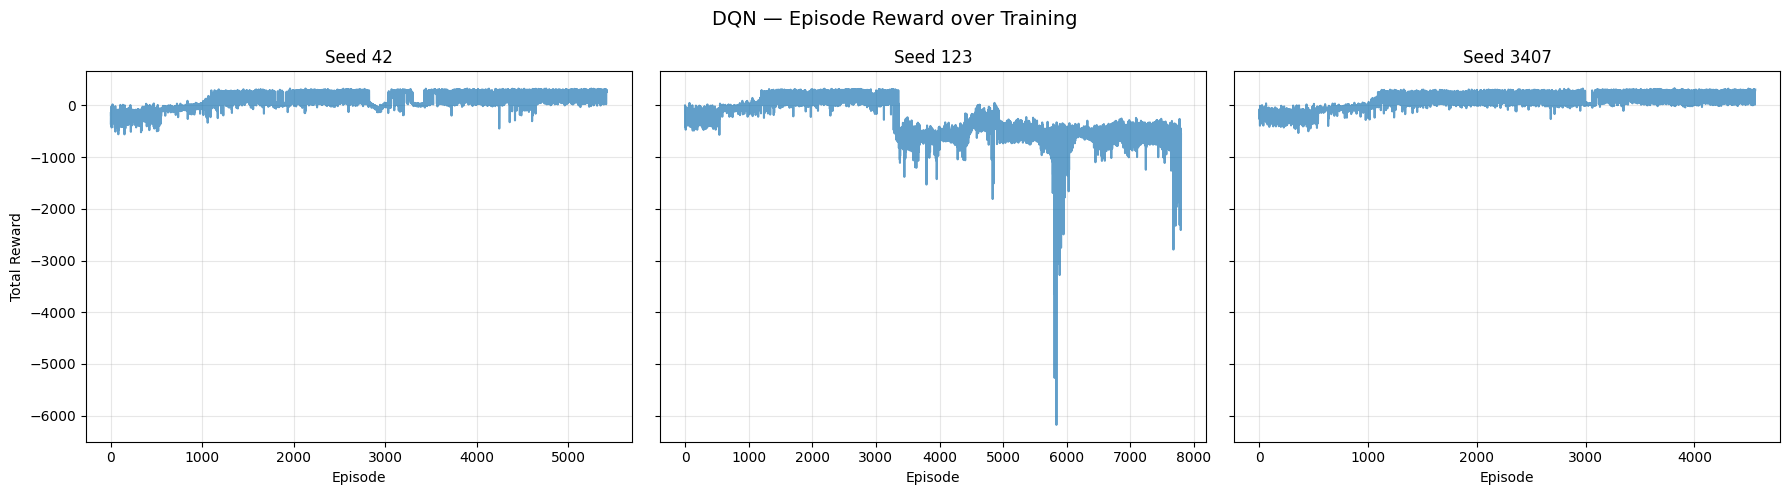

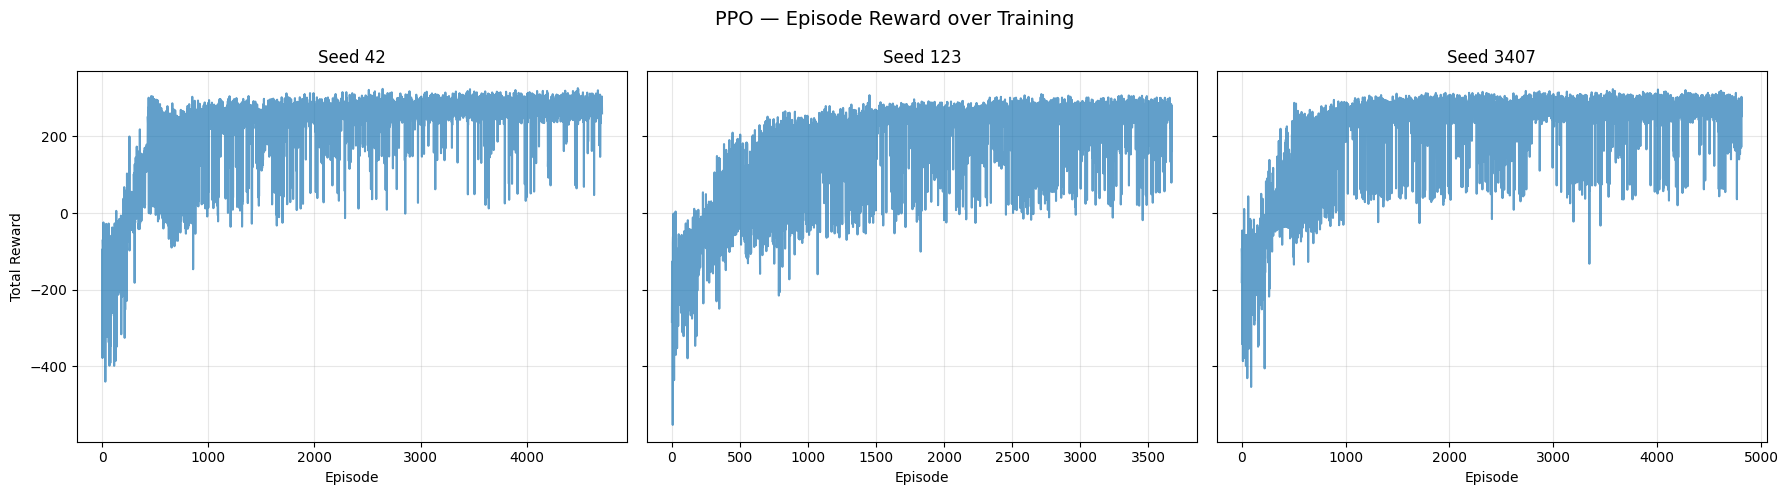

In [12]:
# Per-Algorithm, Per-Seed: Episode Reward over Training

for algo_name in ALGORITHM_MAP:
    fig, axes = plt.subplots(1, len(SEED_LIST), figsize=(6 * len(SEED_LIST), 5), sharey=True)
    if len(SEED_LIST) == 1:
        axes = [axes]

    for ax, seed in zip(axes, SEED_LIST):
        ax.plot(training_results[algo_name][seed].episode_rewards, alpha=0.7)
        ax.set_title(f"Seed {seed}")
        ax.set_xlabel("Episode")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Total Reward")
    fig.suptitle(f"{algo_name.upper()} \u2014 Episode Reward over Training", fontsize=14)
    plt.tight_layout()
    plt.show()

**Figure 7** - Episode reward over training for DQN (top row) and PPO (bottom row)

Figure 7 presents the episodic return trajectories for DQN across seeds 42, 123, and 3407, while Figure Y reports the same analysis for PPO. These plots provide a direct visual comparison of learning dynamics, stability, and sensitivity to random initialization.

The DQN reward curves show substantial variability across seeds. For seeds 42 and 3407, the agent gradually improves from negative returns to sustained positive performance, stabilizing near or above the solved threshold for large portions of training. However, the curves contain noticeable oscillations and transient drops, consistent with the instability typically associated with bootstrapped Q-learning and replay-buffer dynamics.

The most striking behaviour occurs for seed 123, where training initially improves and briefly reaches competent performance, but later suffers a clear collapse. Returns fall into highly negative regimes, including extreme crash episodes with very large negative rewards. This pattern strongly suggests instability in value estimation (e.g., error amplification through bootstrapped targets and shifting data distributions inside the replay buffer), and it illustrates why checkpointing and periodic evaluation were essential for selecting the best DQN model before collapse. 

In contrast, the PPO curves show a more homogeneous pattern across seeds. All seeds exhibit a relatively rapid rise in episodic return early in training, followed by stabilization in a high-performing regime. While episodic variance remains visible (reflecting stochastic transitions and occasional imperfect landings), PPO does not exhibit catastrophic collapses comparable to DQN seed 123. The absence of late-stage divergence aligns with PPO’s clipped updates and on-policy training design, which constrain destructive parameter changes and improve optimization stability.

Figure 7 visually reinforce the quantitative findings reported in the best-model table: both algorithms can reach high performance, but PPO displays stronger robustness and stability across seeds, whereas DQN is more sensitive to random initialization and can experience training degradation after initially strong performance. This difference provides strong empirical support for the expected theoretical contrast between value-based learning (susceptible to overestimation and bootstrapping instability) and policy-based actor–critic optimization with constrained updates (PPO).

## 10.2 Episode Length Curves Across Seeds (DQN vs PPO)

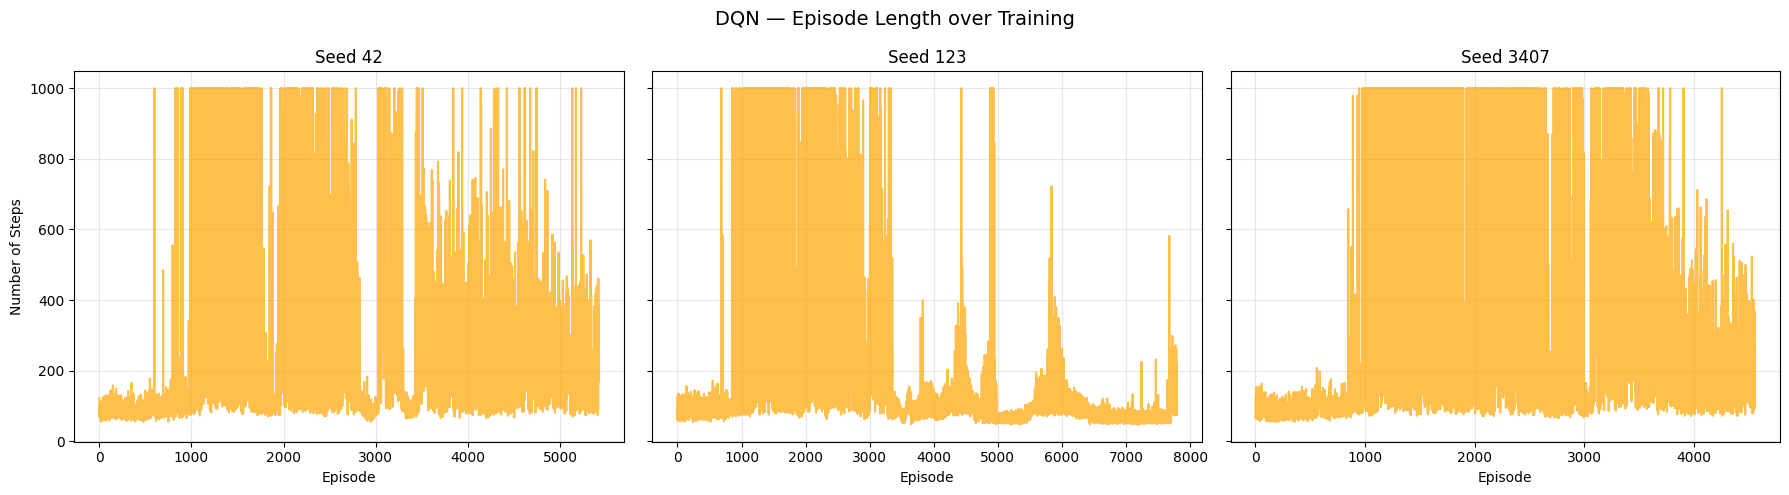

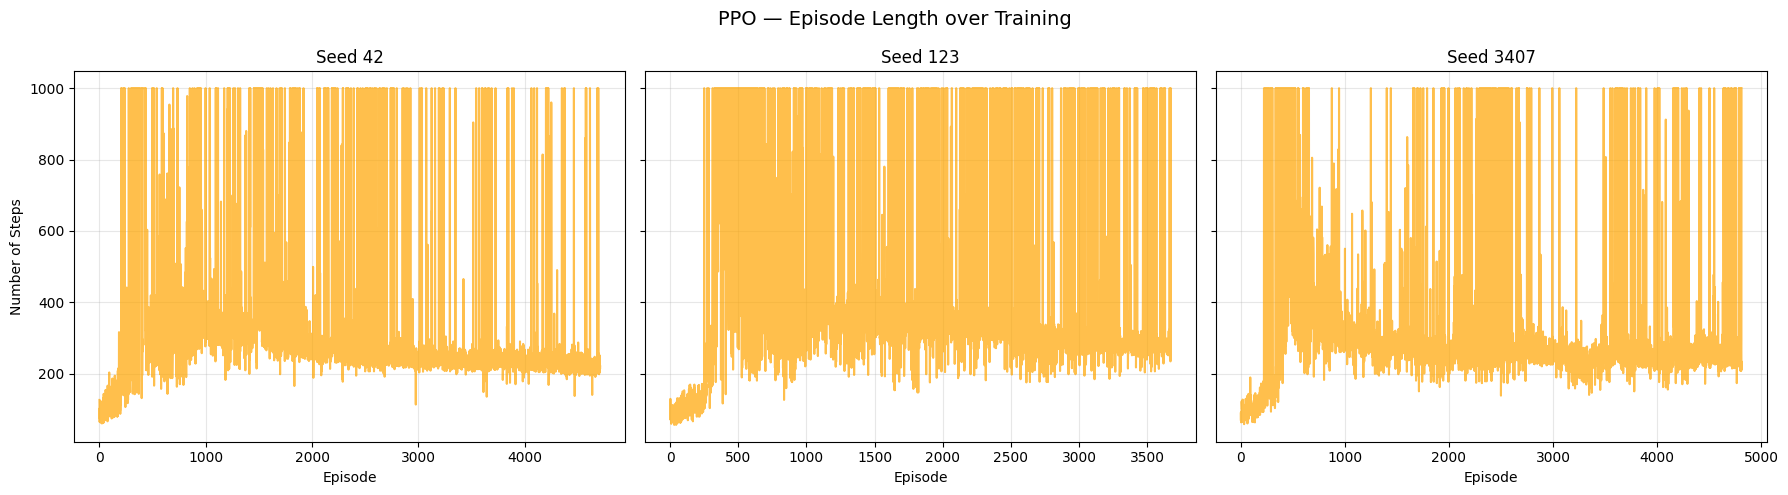

In [13]:
# Per-Algorithm, Per-Seed: Episode Length over Training

for algo_name in ALGORITHM_MAP:
    fig, axes = plt.subplots(1, len(SEED_LIST), figsize=(6 * len(SEED_LIST), 5), sharey=True)
    if len(SEED_LIST) == 1:
        axes = [axes]

    for ax, seed in zip(axes, SEED_LIST):
        ax.plot(training_results[algo_name][seed].episode_lengths, alpha=0.7, color="orange")
        ax.set_title(f"Seed {seed}")
        ax.set_xlabel("Episode")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Number of Steps")
    fig.suptitle(f"{algo_name.upper()} \u2014 Episode Length over Training", fontsize=14)
    plt.tight_layout()
    plt.show()

**Figure 8** - Episode length during training for DQN (top) and PPO (bottom) across seeds 42, 123, and 3407.

Figure 8 report the episode length (number of environment steps per episode) throughout training for DQN and PPO, respectively, across seeds 42, 123, and 3407. Episode length provides a complementary behavioural signal to episodic reward: in LunarLander, longer episodes often reflect sustained flight/hovering and repeated corrections (which can be either beneficial—controlled descent—or inefficient—hovering without committing to landing), whereas short episodes frequently correspond to rapid termination, often due to crashes or unstable landings.

For DQN, the episode length dynamics vary substantially across seeds. Seeds 42 and 3407 exhibit extended periods with high episode lengths (often approaching the environment’s maximum horizon), indicating that the agent learned to remain airborne and execute longer control sequences. Over training, these long episodes become more structured, consistent with improved stabilization and approach manoeuvres prior to landing. However, the presence of intermittent drops in episode length suggests episodes that terminate early, which is consistent with the reward curve oscillations and occasional failures.

Seed 123 stands out as the least stable run. After an initial phase where long episodes occur frequently (suggesting partial competence), the trajectory becomes erratic with repeated bursts and sharp drops in episode length. This pattern aligns with the reward collapse observed for this seed: shorter episodes occurring later in training are consistent with frequent crashes or failure modes that terminate the episode prematurely. Together, these signals reinforce that DQN can experience training degradation after initially improving, reflecting instability in value estimation and policy quality.

For PPO, episode length curves are more homogeneous across seeds. All runs rapidly transition from shorter episodes (early crashes/instability) to longer episodes as the policy learns to stabilize the lander and manage descent. Episode lengths remain broadly high throughout training, with fluctuations that are consistent with occasional imperfect landings but without the sustained late-stage shortening patterns observed in DQN seed 123. This indicates that PPO not only improves reward but also maintains a stable control regime over time, avoiding collapse into short, failure-dominated episodes. 

The episode length plots reinforce the central stability conclusion: PPO achieves more consistent behavioural control across seeds, sustaining long-horizon interaction patterns indicative of stable descent and landing strategies. In contrast, DQN shows stronger seed sensitivity, and the instability observed for seed 123 manifests clearly as late-stage volatility and frequent short episodes, consistent with crash-heavy behaviour. These observations support the broader comparative analysis: PPO’s constrained updates and on-policy learning produce more robust training dynamics, whereas DQN remains susceptible to instability and performance collapse in certain seeds.

## 10.3 Value Loss Dynamics Across Seeds (DQN vs PPO)

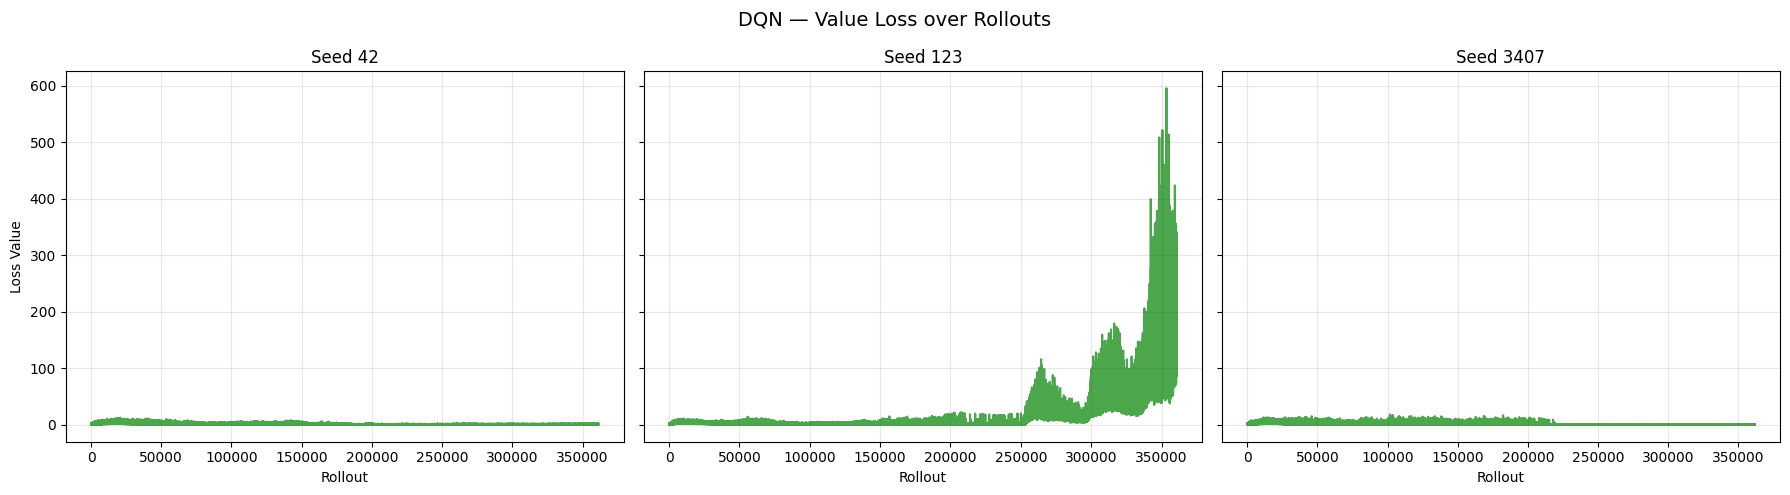

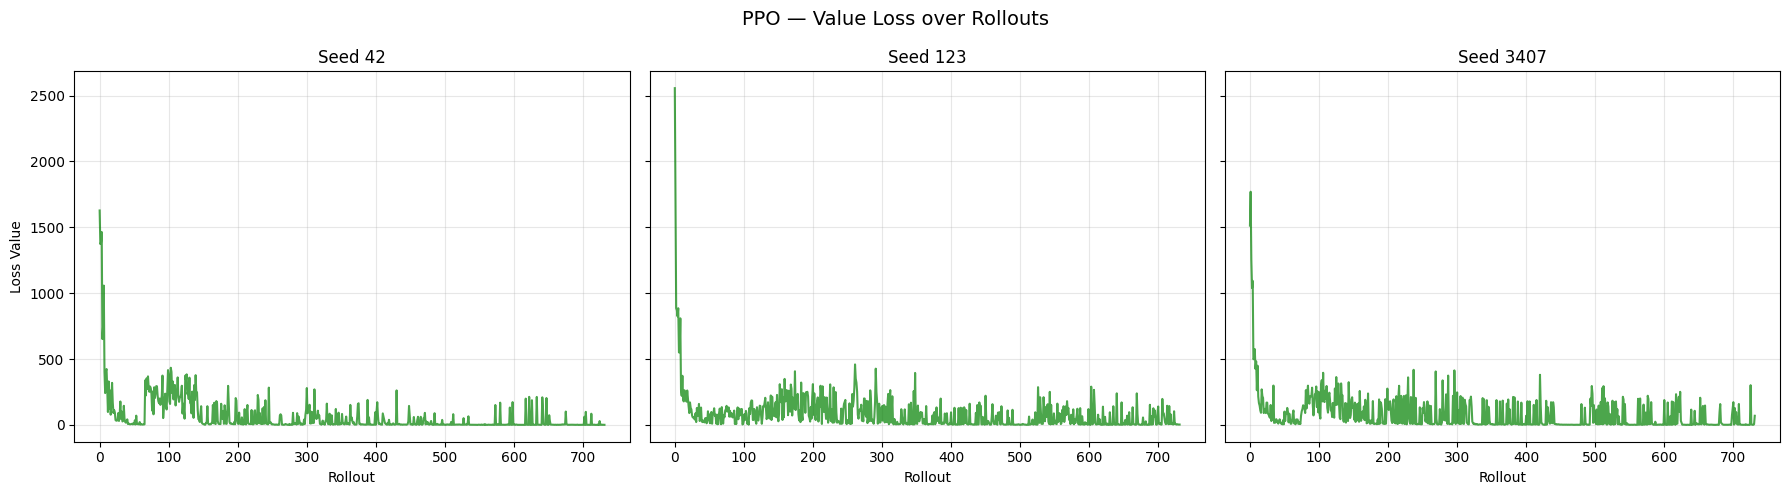

In [14]:
# Per-Algorithm, Per-Seed: Value Loss over Rollouts

for algo_name in ALGORITHM_MAP:
    fig, axes = plt.subplots(1, len(SEED_LIST), figsize=(6 * len(SEED_LIST), 5), sharey=True)
    if len(SEED_LIST) == 1:
        axes = [axes]

    for ax, seed in zip(axes, SEED_LIST):
        ax.plot(training_results[algo_name][seed].value_loss, alpha=0.7, color="green")
        ax.set_title(f"Seed {seed}")
        ax.set_xlabel("Rollout")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Loss Value")
    fig.suptitle(f"{algo_name.upper()} \u2014 Value Loss over Rollouts", fontsize=14)
    plt.tight_layout()
    plt.show()

**Figure 9** - Value loss during training for DQN (top) and PPO (bottom) under seeds 42, 123, and 3407

Figure 9 depict the evolution of the value loss over training rollouts for DQN and PPO, respectively, across seeds 42, 123, and 3407. Although value loss is not a direct proxy for policy quality, its dynamics provide important insight into optimization stability, convergence behaviour, and potential divergence phenomena during training.

For DQN, the value loss trajectories vary substantially across seeds. Seeds 42 and 3407 exhibit relatively well-behaved loss dynamics: after an initial phase with elevated variance, the loss gradually decreases and stabilizes at low magnitudes, suggesting improved calibration of Q-value estimates. However, residual oscillations persist, reflecting the inherent noise of bootstrapped value regression under off-policy sampling.

In stark contrast, seed 123 displays a pronounced late-stage explosion in value loss. After a period of moderate stabilization, the loss increases sharply towards the end of training, reaching very large magnitudes. This behaviour is strongly correlated with the catastrophic performance collapse observed in the reward curves and the shortening of episode lengths for this seed. The divergence in value loss indicates instability in Q-value updates, likely driven by error amplification through bootstrapped targets and non-stationary data distributions in the replay buffer. This phenomenon exemplifies the vulnerability of value-based methods to destabilizing feedback loops in deep reinforcement learning.

For PPO, the value loss curves across all seeds share a common pattern: a very high initial peak during early training, followed by a rapid decay as the value function begins to approximate returns more accurately. Subsequently, the loss remains bounded with moderate fluctuations throughout training. Importantly, no late-stage loss explosions are observed for any seed.

The consistency of PPO’s value loss dynamics reflects the stabilizing effect of on-policy data collection and constrained policy updates. While the critic continues to be updated throughout training, the magnitude of the loss remains controlled, suggesting that value function learning does not diverge even as the policy improves. This stability stands in contrast to the divergent behaviour observed for DQN seed 123 and provides further empirical support for PPO’s robustness.

Taken together, the value loss plots reinforce the broader comparative findings: PPO exhibits more stable optimization dynamics across seeds, whereas DQN is more susceptible to instability and late-stage divergence in certain runs. These empirical observations align with theoretical expectations: off-policy bootstrapped value learning in DQN is prone to overestimation bias and error propagation, while PPO’s clipped objective and advantage-based updates help regulate learning and prevent destructive parameter updates.

## 10.4 Exploration Dynamics

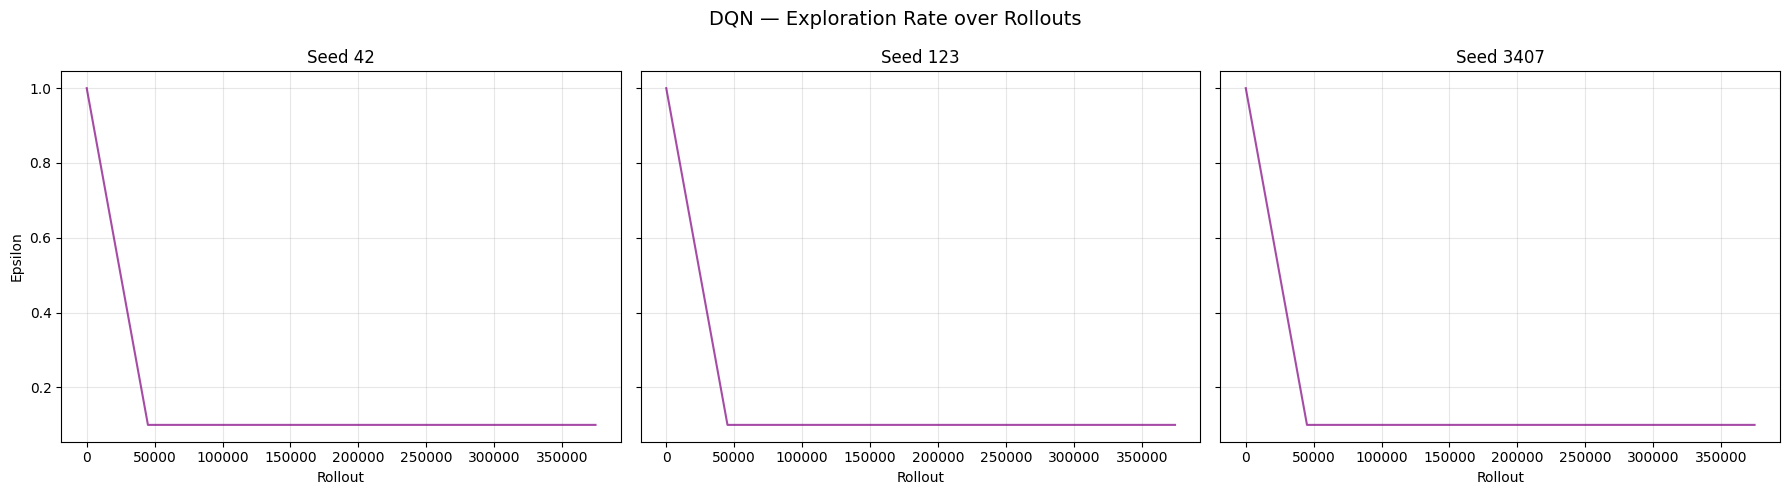

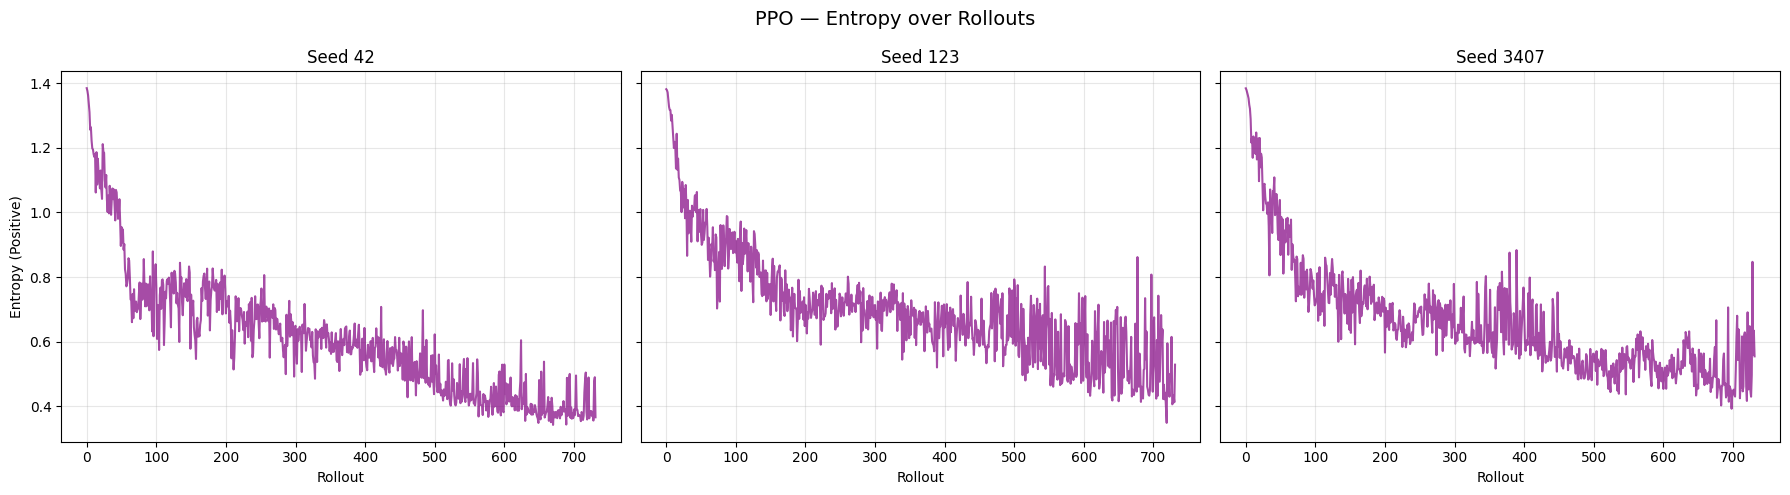

In [15]:
# Per-Algorithm, Per-Seed: Entropy / Exploration Rate over Rollouts

entropy_labels = {"dqn": ("Epsilon", "Exploration Rate"), "ppo": ("Entropy (Positive)", "Entropy")}

for algo_name in ALGORITHM_MAP:
    ylabel, title_suffix = entropy_labels[algo_name]

    fig, axes = plt.subplots(1, len(SEED_LIST), figsize=(6 * len(SEED_LIST), 5), sharey=True)
    if len(SEED_LIST) == 1:
        axes = [axes]

    for ax, seed in zip(axes, SEED_LIST):
        ax.plot(training_results[algo_name][seed].entropy, alpha=0.7, color="purple")
        ax.set_title(f"Seed {seed}")
        ax.set_xlabel("Rollout")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(ylabel)
    fig.suptitle(f"{algo_name.upper()} \u2014 {title_suffix} over Rollouts", fontsize=14)
    plt.tight_layout()
    plt.show()

**Figure 10** - Exploration rate (DQN, top) and entropy (PPO, bottom) across seeds 42, 123, and 3407.

Figure 10 illustrate the evolution of exploration-related metrics during training: the ε-greedy exploration rate for DQN and the policy entropy for PPO, across seeds 42, 123, and 3407. These curves provide insight into how each algorithm transitions from exploration to exploitation and how exploration pressure is maintained over time.

For DQN, the exploration rate ε follows a predefined linear schedule, decreasing rapidly from its initial value to the final exploration floor (ε_final = 0.1) within the early phase of training. This behaviour is identical across seeds, as the ε schedule is deterministic and independent of learning progress. After reaching the minimum exploration rate, ε remains constant for the remainder of training, implying that a fixed proportion of actions (10%) continue to be selected uniformly at random.

This rigid exploration schedule implies that the degree of exploration does not adapt to the agent’s uncertainty or performance. Consequently, once ε has decayed, the agent’s behaviour becomes increasingly exploitative, and any subsequent performance degradation (as observed for DQN seed 123) cannot be counteracted by adaptive increases in exploration. This highlights a limitation of ε-greedy exploration in complex control tasks, where exploration needs may change over the course of training.

For PPO, the policy entropy decreases gradually over training for all seeds, reflecting the transition from highly stochastic policies to more deterministic ones as learning progresses. Unlike ε-greedy, entropy is not externally scheduled but emerges from the interaction between policy optimization and entropy regularization. The smooth decay of entropy indicates that PPO progressively reduces randomness while still maintaining non-zero stochasticity, enabling continued local exploration around promising policies.

Importantly, entropy remains strictly positive throughout training and does not collapse to zero. This sustained exploration pressure helps prevent premature convergence to suboptimal deterministic policies and contributes to PPO’s observed training stability. Minor fluctuations in entropy reflect ongoing policy refinement and local exploration, rather than abrupt regime changes. 

The contrasting exploration dynamics align with the observed differences in training stability between DQN and PPO. DQN’s fixed ε schedule enforces an abrupt transition from exploration to exploitation, which may exacerbate instability once the agent relies heavily on potentially misestimated Q-values. PPO’s entropy-driven exploration, by contrast, provides a more gradual and adaptive reduction in stochasticity, supporting stable convergence and reducing the risk of catastrophic policy collapse. These empirical patterns support the theoretical distinction between externally imposed ε-greedy exploration and intrinsically regulated entropy-regularized policy learning.

## 10.5 PPO Policy Gradient Loss Dynamics

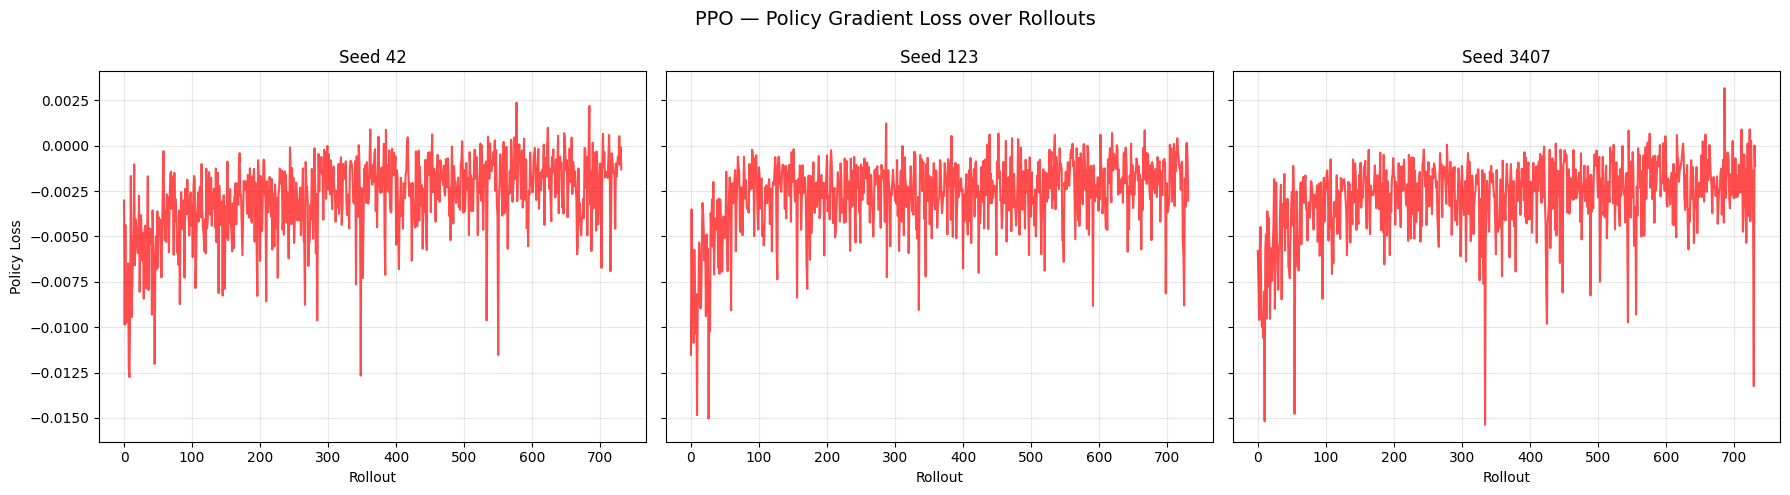

In [16]:
# PPO Only: Policy Loss over Rollouts

fig, axes = plt.subplots(1, len(SEED_LIST), figsize=(6 * len(SEED_LIST), 5), sharey=True)
if len(SEED_LIST) == 1:
    axes = [axes]

for ax, seed in zip(axes, SEED_LIST):
    ax.plot(training_results["ppo"][seed].policy_loss, alpha=0.7, color="red")
    ax.set_title(f"Seed {seed}")
    ax.set_xlabel("Rollout")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Policy Loss")
fig.suptitle("PPO \u2014 Policy Gradient Loss over Rollouts", fontsize=14)
plt.tight_layout()
plt.show()

**Figure 11** - PPO policy gradient loss across seeds 42, 123, and 3407.

Figure 11 presents the evolution of the policy gradient loss for PPO across seeds 42, 123, and 3407. The policy loss reflects the magnitude and direction of gradient-based updates applied to the actor network and provides insight into the stability and consistency of policy optimization over time.

Across all seeds, the policy loss exhibits a characteristic pattern: relatively large-magnitude updates during the initial training phase, followed by a gradual reduction in magnitude as training progresses. This behaviour is consistent with the early stage of learning, where the policy undergoes substantial adjustments to move from near-random behaviour towards competent control strategies. As the policy approaches a stable solution, the magnitude of updates decreases, indicating convergence towards a locally optimal policy.

Importantly, the policy loss remains bounded throughout training for all seeds. While sporadic negative spikes are visible, reflecting occasional larger corrective updates, there is no evidence of sustained divergence or instability. This bounded behaviour is consistent with the design of PPO’s clipped surrogate objective, which explicitly constrains the magnitude of policy updates to prevent destructive parameter changes. The presence of clipping ensures that even when gradient signals are large, the effective update applied to the policy remains within a trust region, promoting stable learning dynamics.

Minor fluctuations in the policy loss persist throughout training, reflecting ongoing fine-tuning of the policy in response to stochastic transitions and residual variability in advantage estimates. The overall similarity of the loss trajectories across seeds further indicates that PPO’s optimization process is robust to random initialization, reinforcing the cross-seed stability observed in reward and episode length curves.

## 10.6 Q-Value Overestimation in DQN Across

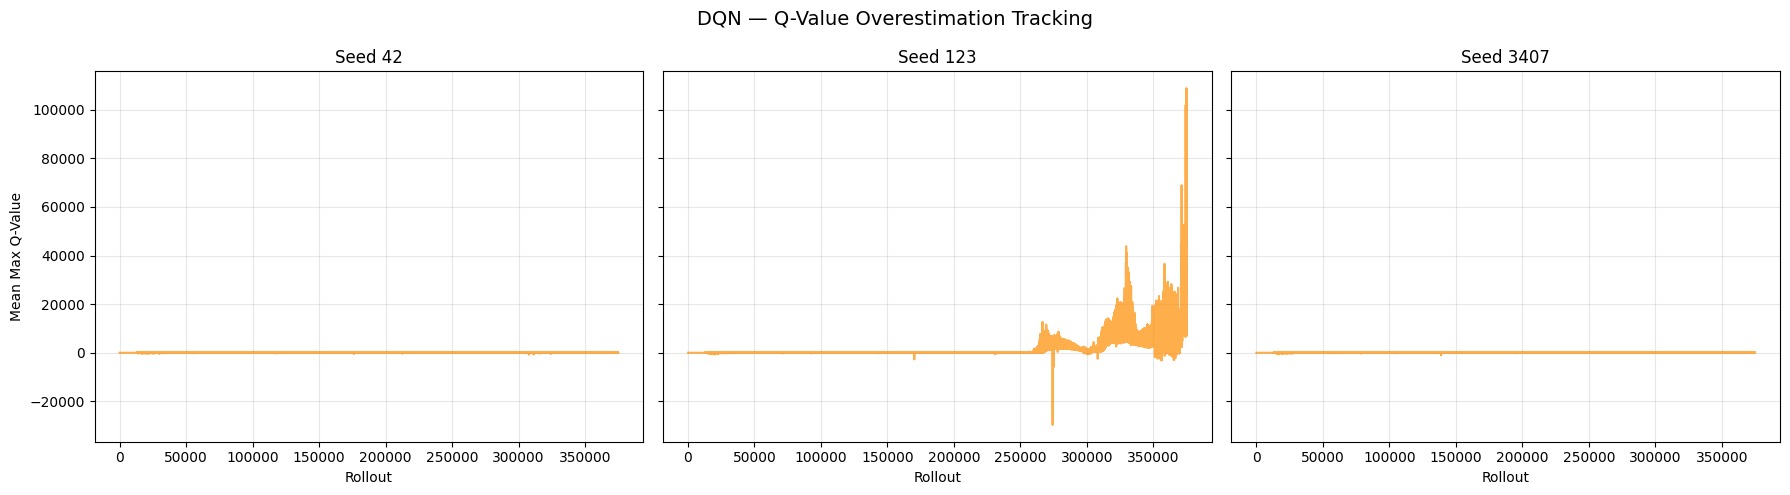

Note: Steadily rising Q-values that diverge from actual returns indicate overestimation.
A stable or slowly growing curve suggests the target network is controlling overestimation.


In [17]:
# DQN Overestimation: Mean Max Q-Value over Training

fig, axes = plt.subplots(1, len(SEED_LIST), figsize=(6 * len(SEED_LIST), 5), sharey=True)
if len(SEED_LIST) == 1:
    axes = [axes]

for ax, seed in zip(axes, SEED_LIST):
    q_vals = training_results["dqn"][seed].mean_q_values
    if q_vals:
        ax.plot(q_vals, alpha=0.7, color="darkorange")
    ax.set_title(f"Seed {seed}")
    ax.set_xlabel("Rollout")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Mean Max Q-Value")
fig.suptitle("DQN \u2014 Q-Value Overestimation Tracking", fontsize=14)
plt.tight_layout()
plt.show()

print("Note: Steadily rising Q-values that diverge from actual returns indicate overestimation.")
print("A stable or slowly growing curve suggests the target network is controlling overestimation.")

**Figure 12** - DQN mean max Q‑value over rollouts for seeds 42, 123, and 3407.

Figure 12 illustrates the evolution of the mean maximum predicted Q-values during training for DQN across seeds 42, 123, and 3407. This diagnostic provides an approximate empirical proxy for tracking overestimation bias in value-based reinforcement learning, where the max operator in the Bellman target can systematically bias Q-value estimates upward.

For seeds 42 and 3407, the mean maximum Q-values remain within a relatively bounded range throughout training, exhibiting only modest growth over time. This suggests that the target network updates and replay-buffer sampling dynamics are effectively constraining runaway overestimation. The stability of Q-value magnitudes in these runs is consistent with the observed stable learning trajectories and sustained high performance after convergence.

In contrast, seed 123 exhibits a pronounced late-stage escalation in the magnitude of predicted Q-values, with sharp spikes and large excursions both above and below the typical range observed in the other seeds. This behaviour coincides temporally with the explosion in value loss and the catastrophic performance collapse observed in the reward and episode-length curves for this seed. The divergence of Q-value magnitudes is indicative of severe overestimation and instability in the bootstrapped target updates, where erroneous value predictions can be amplified through the max operator and propagated across training updates.

These empirical patterns provide direct evidence of the overestimation pathology commonly associated with DQN. While target networks mitigate rapid drift, they do not fully eliminate the risk of runaway overestimation under certain stochastic conditions and replay-buffer dynamics. The instability observed for seed 123 highlights how value overestimation can lead to brittle policies and eventual training collapse, reinforcing the motivation for algorithmic extensions such as Double DQN, clipped targets, or distributional value methods to further stabilize value estimation.

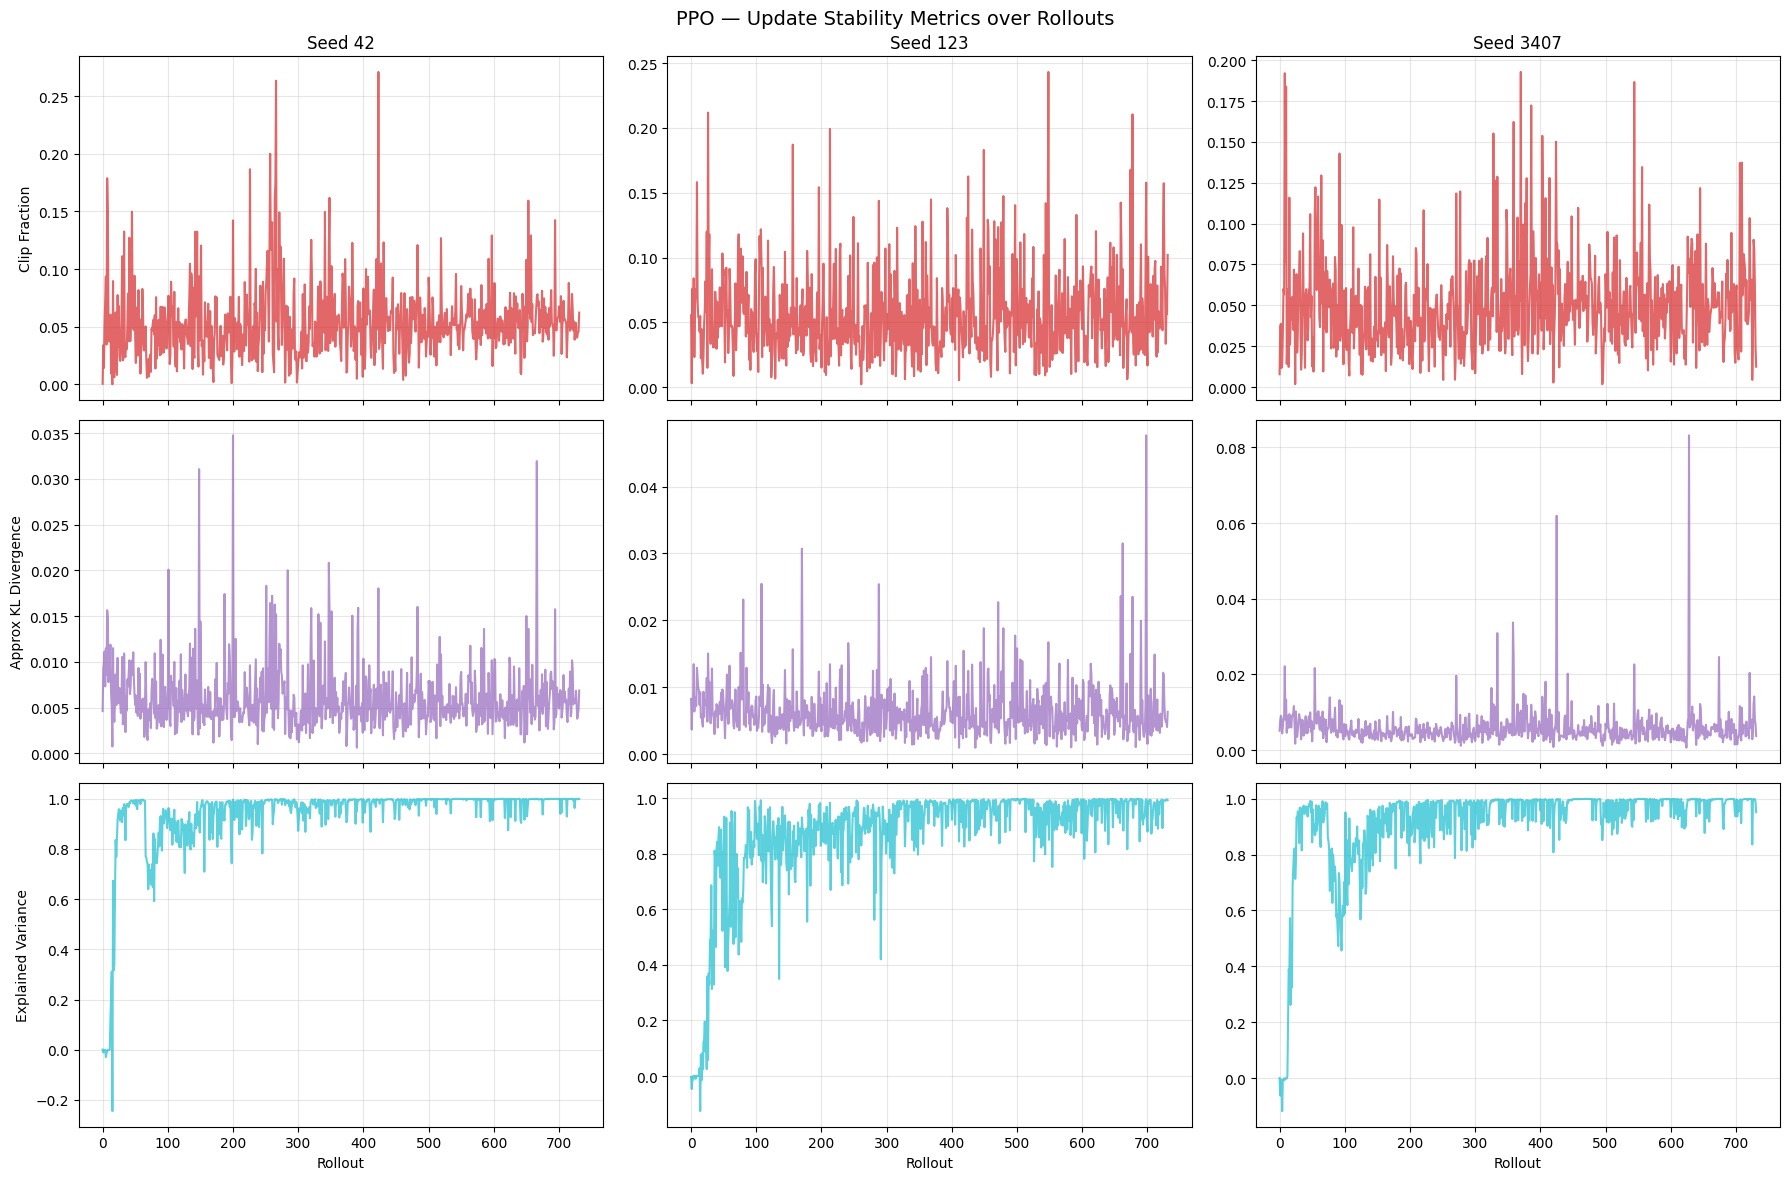

  Clip Fraction: Fraction of policy updates clipped by PPO. High values suggest the policy is changing too fast.
  Approx KL Divergence: KL divergence between old and new policy. Spikes indicate large policy shifts.
  Explained Variance: How well the value function predicts returns. 1.0 = perfect, 0 = no better than mean.


In [18]:
# PPO Update Stability: Clip Fraction, Approx KL, Explained Variance

fig, axes = plt.subplots(3, len(SEED_LIST), figsize=(6 * len(SEED_LIST), 12), sharex=True)
if len(SEED_LIST) == 1:
    axes = axes.reshape(3, 1)

metrics = [
    ("clip_fraction", "Clip Fraction", "tab:red",
     "Fraction of policy updates clipped by PPO. High values suggest the policy is changing too fast."),
    ("approx_kl", "Approx KL Divergence", "tab:purple",
     "KL divergence between old and new policy. Spikes indicate large policy shifts."),
    ("explained_variance", "Explained Variance", "tab:cyan",
     "How well the value function predicts returns. 1.0 = perfect, 0 = no better than mean."),
]

for row, (attr, ylabel, color, _) in enumerate(metrics):
    for col, seed in enumerate(SEED_LIST):
        data = getattr(training_results["ppo"][seed], attr)
        if data:
            axes[row][col].plot(data, alpha=0.7, color=color)
        if row == 0:
            axes[row][col].set_title(f"Seed {seed}")
        if row == 2:
            axes[row][col].set_xlabel("Rollout")
        axes[row][col].grid(True, alpha=0.3)
    axes[row][0].set_ylabel(ylabel)

fig.suptitle("PPO \u2014 Update Stability Metrics over Rollouts", fontsize=14)
plt.tight_layout()
plt.show()

for _, ylabel, _, description in metrics:
    print(f"  {ylabel}: {description}")

**Figure 13** - PPO clip fraction, KL divergence, and explained variance over rollouts for seeds 42, 123, and 3407.

## 10.7 PPO Update Stability Metrics

Figure 13 reports three complementary PPO-specific stability diagnostics across seeds 42, 123, and 3407: (i) clip fraction, (ii) approximate KL divergence between successive policies, and (iii) explained variance of the value function. Together, these metrics provide a detailed view of how constrained policy updates and critic learning evolve during training. 

Across all seeds, the clip fraction remains at moderate levels for most of training, with occasional short-lived spikes. This indicates that PPO’s clipping mechanism is actively constraining updates when the policy change becomes too large, while not excessively saturating the objective. The absence of sustained high clip fractions suggests that policy updates remain within the intended trust region for the majority of training, supporting stable learning dynamics.

The approximate KL divergence stays low and relatively stable across seeds, with rare transient peaks. These occasional spikes correspond to moments where the policy undergoes larger adjustments, typically early in training or when adapting to improved value estimates. Importantly, there is no evidence of runaway KL divergence, indicating that PPO’s clipped objective effectively prevents destructive policy updates and maintains continuity between successive policies.

The explained variance of the value function increases rapidly from low or negative values during early training to values close to 1.0 for all seeds, indicating that the critic learns to accurately predict returns. High and sustained explained variance throughout training reflects stable and reliable value function approximation, which is crucial for producing low-variance advantage estimates and supporting consistent policy improvement. Minor dips in explained variance correspond to transient mismatches between the critic and rapidly improving policy but are quickly corrected.

Collectively, these stability metrics provide strong empirical evidence that PPO’s constrained update mechanism (via clipping) and advantage-based optimization lead to well-behaved training dynamics. The bounded clip fraction and KL divergence indicate that policy updates remain controlled, while the high explained variance demonstrates effective critic learning. These properties help explain the smoother learning curves, absence of catastrophic collapse, and cross-seed robustness observed for PPO in the reward and episode-length analyses.

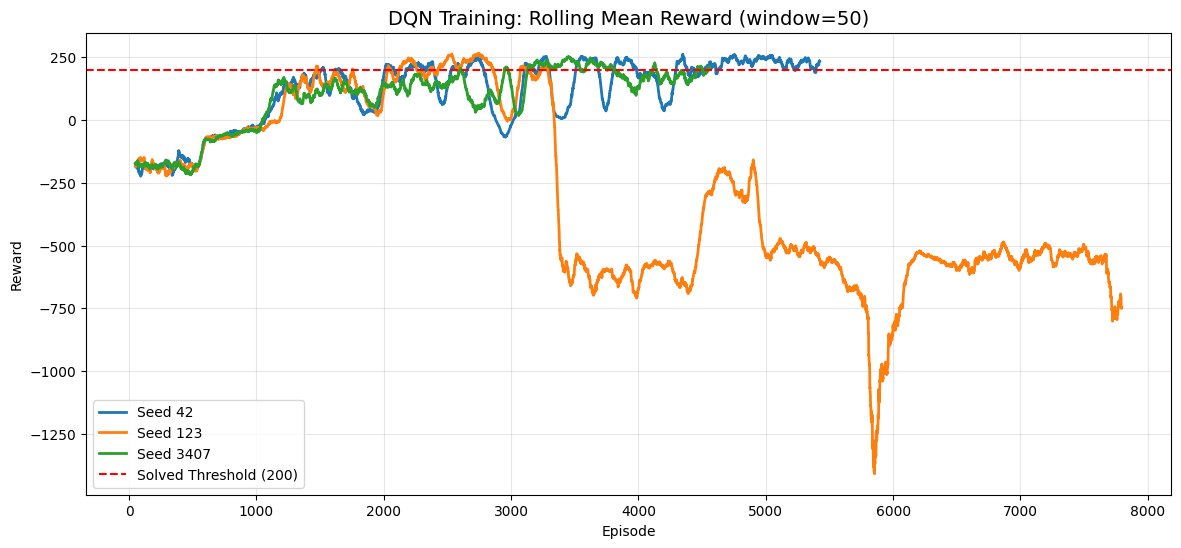

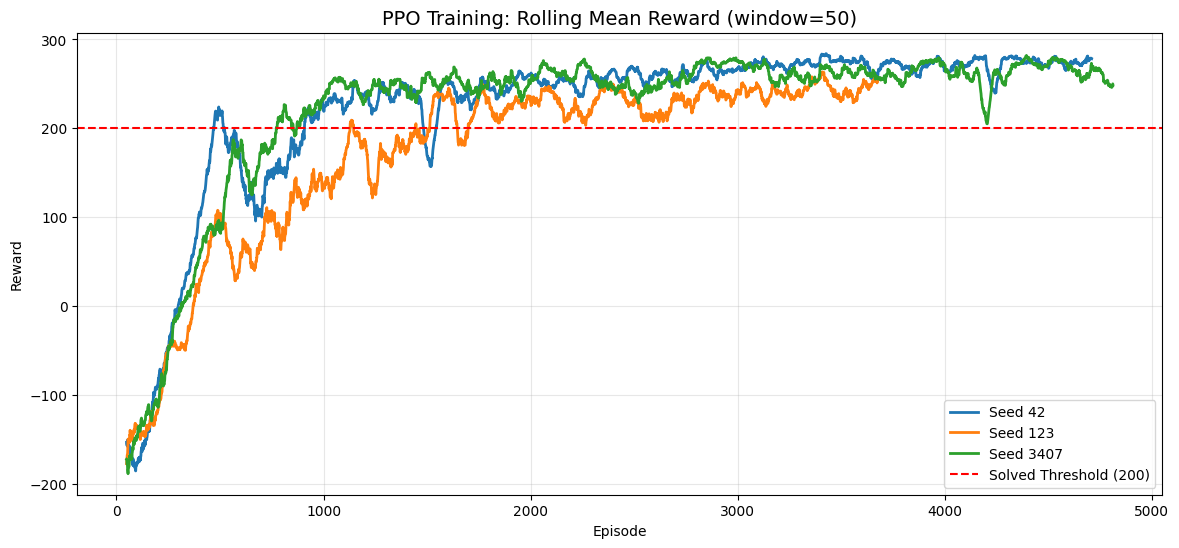

In [19]:
# Aggregated: Rolling Reward Overlay — per algorithm (all seeds on one chart)

seed_colors = list(plt.colormaps["tab10"](range(10)))  # type: ignore[arg-type]

for algo_name in ALGORITHM_MAP:
    plt.figure(figsize=(14, 6))
    for i, seed in enumerate(SEED_LIST):
        rewards = training_results[algo_name][seed].episode_rewards
        rolling = pd.Series(rewards).rolling(50).mean()
        plt.plot(rolling, color=seed_colors[i], linewidth=2, label=f"Seed {seed}")

    plt.axhline(y=200, color='red', linestyle='--', label='Solved Threshold (200)')
    plt.title(f"{algo_name.upper()} Training: Rolling Mean Reward (window=50)", fontsize=14)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

**Figure 14** - Rolling mean reward for DQN (top) and PPO (bottom) across seeds 42, 123, and 3407, with solved threshold at 200.

## 10.8 Cross-Seed Rolling Reward Comparison

Figure 14 overlay the rolling mean episodic reward (window = 50 episodes) across the three seeds for DQN and PPO, respectively. By smoothing short-term variance, these plots provide a clear view of sample efficiency, convergence speed, and cross-seed stability relative to the solved threshold (mean return ≥ 200).

In the DQN overlay (Figure X), seeds 42 and 3407 follow broadly successful learning trajectories: after an initial low-return regime, both curves rise towards the solved threshold and remain mostly above it in later training, indicating convergence to competent policies. However, the trajectories exhibit multiple oscillations and temporary drops, reflecting the characteristic volatility of bootstrapped value learning.

The most critical behaviour is observed for seed 123. Although the rolling reward initially improves and reaches the solved threshold, it undergoes a dramatic collapse around mid-training and never recovers to sustained competent performance. The rolling mean falls deep into negative values and remains unstable, exhibiting additional severe drops later in training. This pattern confirms that DQN’s learning process can become unstable after initially successful learning, reinforcing the earlier evidence from value loss divergence and Q-value explosion. Importantly, this also demonstrates why selecting the best checkpoint via periodic evaluation was essential: high-performing DQN behaviour can be transient and may degrade if training continues.

In contrast, the PPO overlay (Figure Y) shows highly consistent behaviour across seeds. All three seeds rise smoothly from negative returns to the solved region and remain stably above the threshold thereafter. While some seeds converge slightly faster than others, the variability is moderate and no catastrophic collapse is observed. Once PPO crosses the solved threshold, performance remains in a stable high-return regime, typically between ~230 and ~290 in rolling average terms.

The rolling overlays provide one of the clearest empirical contrasts between the algorithms. Both methods can solve LunarLander-v3, but PPO demonstrates substantially stronger robustness across random seeds, achieving stable solved performance in all runs and maintaining that performance once reached. DQN can match PPO’s peak performance in favourable runs, but exhibits significantly weaker stability, including clear evidence of collapse under seed 123. This difference aligns with the theoretical expectations: PPO’s clipped objective and advantage-based updates tend to produce smoother, safer policy improvements, whereas DQN’s bootstrapped targets and max-based value estimation can lead to unstable feedback loops and performance degradation.

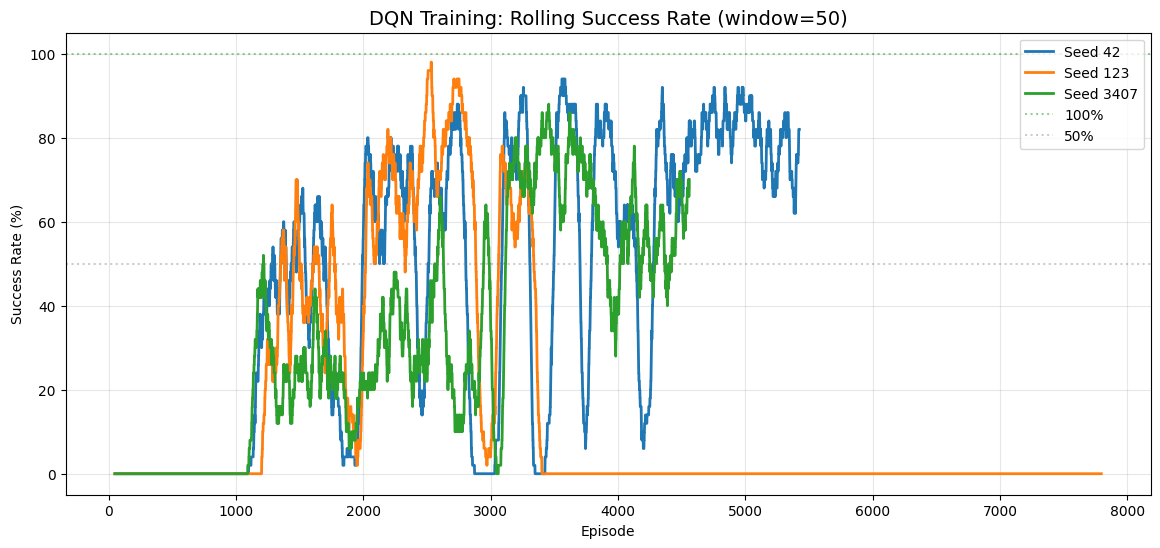

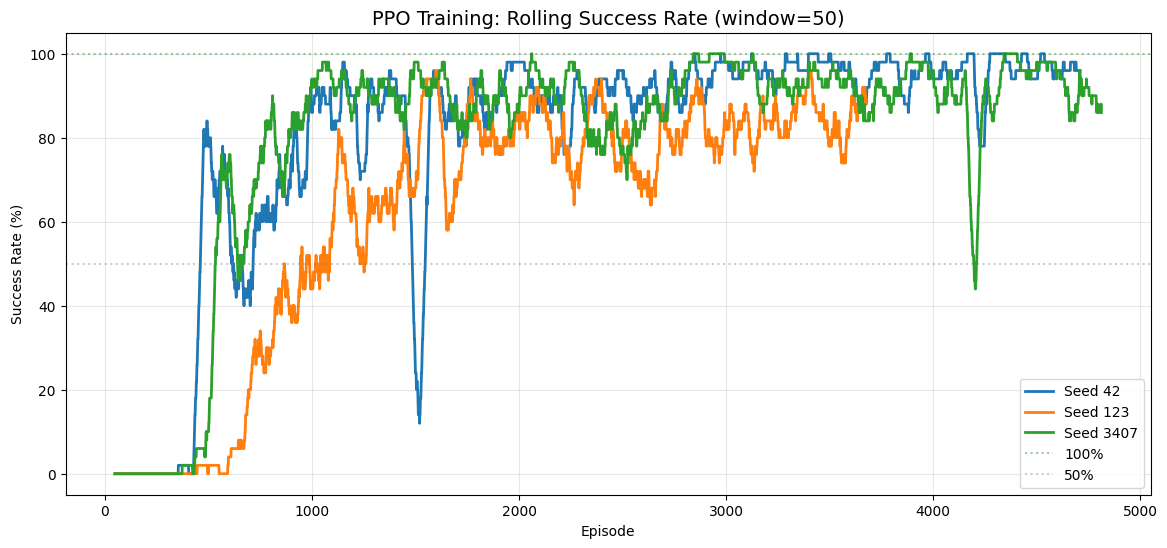

In [20]:
# Per-Algorithm: Rolling Success Rate over Training (window=50)

for algo_name in ALGORITHM_MAP:
    plt.figure(figsize=(14, 6))
    for i, seed in enumerate(SEED_LIST):
        rewards = np.array(training_results[algo_name][seed].episode_rewards)
        success = (rewards >= 200).astype(float)
        rolling_success = pd.Series(success).rolling(50).mean() * 100
        plt.plot(rolling_success, color=seed_colors[i], linewidth=2, label=f"Seed {seed}")

    plt.axhline(y=100, color='green', linestyle=':', alpha=0.4, label='100%')
    plt.axhline(y=50, color='gray', linestyle=':', alpha=0.4, label='50%')
    plt.title(f"{algo_name.upper()} Training: Rolling Success Rate (window=50)", fontsize=14)
    plt.xlabel("Episode")
    plt.ylabel("Success Rate (%)")
    plt.ylim(-5, 105)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

**Figure 15** - Rolling success rate for DQN (top) and PPO (bottom) across seeds 42, 123, and 3407.

## 10.9 Rolling Success Rate 

Figure 15 report the rolling success rate (window = 50 episodes) for DQN and PPO, respectively, across seeds 42, 123, and 3407. Success was defined as an episode achieving a total return ≥ 200, consistent with the environment’s solved criterion. This metric complements reward curves by translating performance into an interpretable behavioural indicator: the proportion of recent episodes in which the agent reliably executes a competent landing policy.

For DQN, seeds 42 and 3407 show a gradual increase in success rate as learning progresses, eventually reaching high success regimes (often between ~60% and ~90% in the rolling window). However, both seeds exhibit pronounced oscillations, reflecting intermittent failure episodes even after achieving competent behaviour. These oscillations indicate that DQN policies can remain brittle during training, with occasional regressions that reduce short-term reliability.

Seed 123 exhibits a qualitatively different outcome. While the success rate rises significantly during early-to-mid training (approaching very high values at one point), it abruptly collapses and remains near 0% for the remainder of training. This sustained failure regime confirms that the agent no longer produces competent landings and aligns directly with the reward collapse, value loss explosion, and Q-value divergence observed previously. In practice, this strongly reinforces the need for checkpoint-based model selection and early stopping when training DQN, as the final policy after full training may be substantially worse than earlier checkpoints.
 
For PPO, all seeds show rapid improvement in success rate and converge to consistently high reliability. After the initial learning phase, success rates stabilize predominantly in the ~80%–100% range, indicating that PPO learns not only high-return behaviour but also a robust landing strategy that generalizes across episodes. Occasional transient dips are visible (e.g., isolated drops for seeds 42 and 3407), but these are short-lived and do not lead to persistent collapse. Overall, PPO demonstrates markedly stronger reliability over training compared to DQN.
 
The rolling success rate plots provide a clear behavioural stability comparison. While mean reward can remain high despite sporadic failures, success rate directly measures how consistently the agent achieves solved-level performance. PPO achieves stronger and more stable success rates across seeds, whereas DQN displays higher volatility and, in the case of seed 123, complete late-stage failure. These findings further support the broader conclusion that PPO provides a more robust training process, while DQN requires careful monitoring and best-checkpoint selection to avoid instability.

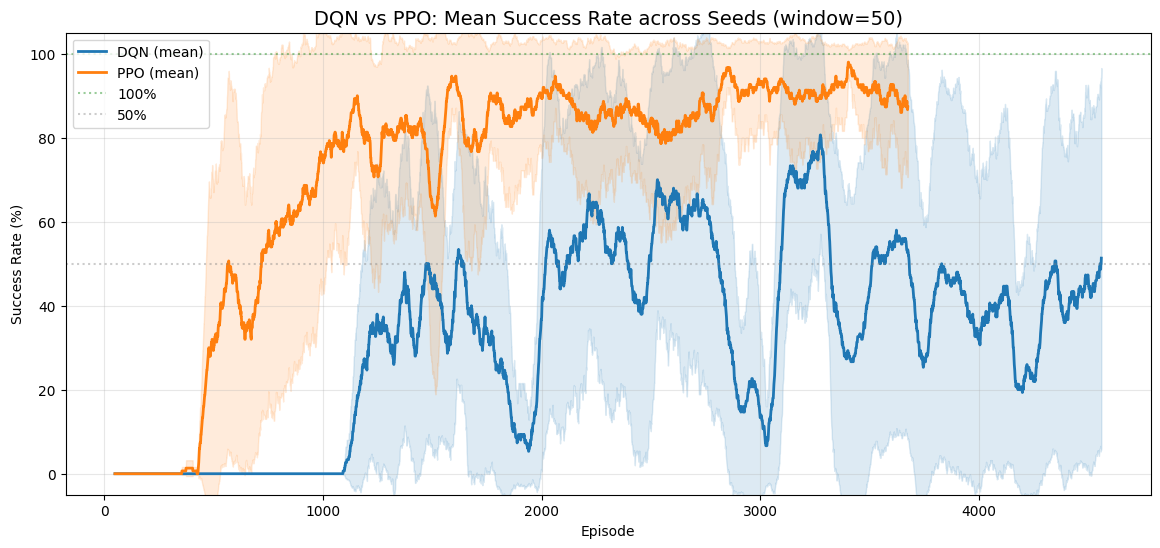

In [21]:
# Cross-Algorithm Comparison: Success Rate over Training (averaged across seeds)

algo_colors = {"dqn": "tab:blue", "ppo": "tab:orange"}

plt.figure(figsize=(14, 6))
for algo_name in ALGORITHM_MAP:
    min_len = min(len(training_results[algo_name][s].episode_rewards) for s in SEED_LIST)
    all_rewards = np.array([training_results[algo_name][s].episode_rewards[:min_len] for s in SEED_LIST])
    all_success = (all_rewards >= 200).astype(float)

    mean_success = pd.Series(all_success.mean(axis=0)).rolling(50).mean() * 100
    std_success = pd.Series(all_success.std(axis=0)).rolling(50).mean() * 100

    episodes = np.arange(len(mean_success))
    plt.plot(episodes, mean_success, color=algo_colors[algo_name], linewidth=2,
             label=f"{algo_name.upper()} (mean)")
    plt.fill_between(episodes, mean_success - std_success, mean_success + std_success,
                     color=algo_colors[algo_name], alpha=0.15)

plt.axhline(y=100, color='green', linestyle=':', alpha=0.4, label='100%')
plt.axhline(y=50, color='gray', linestyle=':', alpha=0.4, label='50%')
plt.title("DQN vs PPO: Mean Success Rate across Seeds (window=50)", fontsize=14)
plt.xlabel("Episode")
plt.ylabel("Success Rate (%)")
plt.ylim(-5, 105)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Figure 16** - Mean success rate for DQN and PPO across seeds.

## 10.10 Cross-Algorithm Comparison: Mean Rolling Success

Figure 16 provides a direct algorithm-level comparison by averaging the rolling success rate (window = 50 episodes) across seeds for DQN and PPO, and displaying mean ± std as a shaded band. This plot compresses seed-level variability into a single view that emphasizes (i) sample efficiency (how quickly each method becomes reliably competent), (ii) robustness (variance across seeds), and (iii) sustained reliability over training.

PPO exhibits a steep and early increase in success rate, reaching high-reliability regimes (≈80–95% rolling success) relatively quickly. After this transition, the mean success rate remains consistently high, and the uncertainty band (± std across seeds) is comparatively narrow. This indicates that PPO not only learns a competent policy earlier, but also does so consistently across random initializations. The stability of the curve around the 90%+ region supports the conclusion that PPO produces robust policies that reliably achieve solved-level episodes throughout training.

DQN increases its success rate later and more gradually. More importantly, the mean trajectory is strongly affected by cross-seed instability, as reflected in the wide shaded band. This wide variance is largely driven by the catastrophic collapse observed in seed 123, which reduces the average success rate and increases dispersion. Even when DQN reaches moderate-to-high success in favourable runs, the overall mean remains unstable and the uncertainty band indicates that performance is far less predictable across seeds than PPO.
 
This aggregated view reinforces the central comparative message of the project. While both algorithms can achieve solved-level performance, PPO reaches reliable success earlier and maintains it more consistently across seeds. DQN remains significantly more sensitive to stochasticity and initialization, showing larger oscillations and a materially higher risk of late-stage failure. From an applied perspective,where reproducibility and stability matter, PPO demonstrates superior robustness under the controlled experimental setup used in this study.

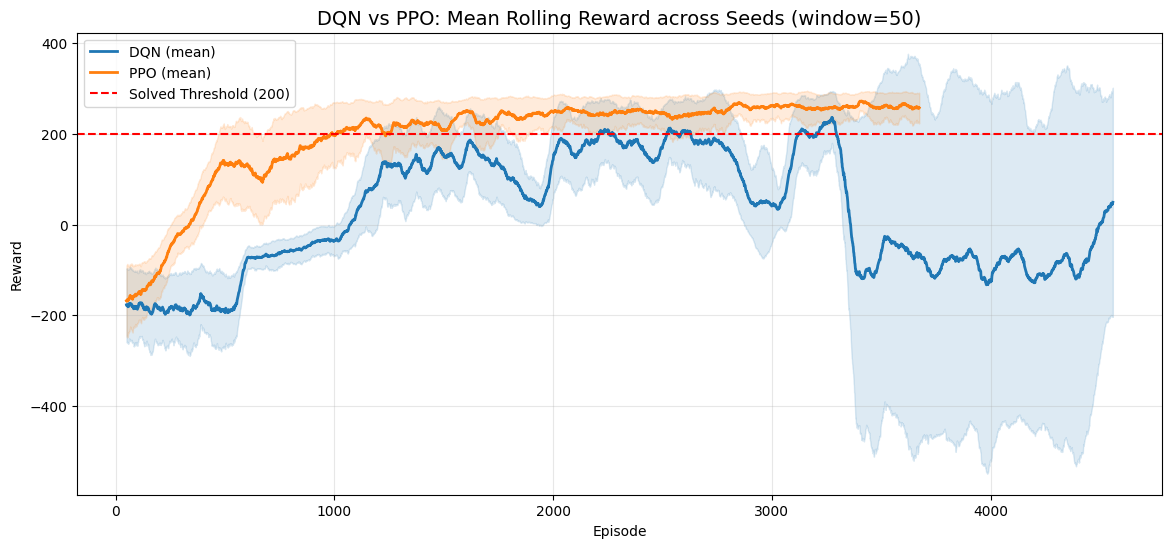

In [22]:
# Cross-Algorithm Comparison: Rolling Reward (averaged across seeds)

algo_colors = {"dqn": "tab:blue", "ppo": "tab:orange"}

plt.figure(figsize=(14, 6))
for algo_name in ALGORITHM_MAP:
    # Find the shortest episode count across seeds for alignment
    min_len = min(len(training_results[algo_name][s].episode_rewards) for s in SEED_LIST)
    all_rewards = np.array([training_results[algo_name][s].episode_rewards[:min_len] for s in SEED_LIST])
    mean_rewards = pd.Series(all_rewards.mean(axis=0)).rolling(50).mean()
    std_rewards = pd.Series(all_rewards.std(axis=0)).rolling(50).mean()

    episodes = np.arange(len(mean_rewards))
    plt.plot(episodes, mean_rewards, color=algo_colors[algo_name], linewidth=2, label=f"{algo_name.upper()} (mean)")
    plt.fill_between(episodes, mean_rewards - std_rewards, mean_rewards + std_rewards,
                     color=algo_colors[algo_name], alpha=0.15)

plt.axhline(y=200, color='red', linestyle='--', label='Solved Threshold (200)')
plt.title("DQN vs PPO: Mean Rolling Reward across Seeds (window=50)", fontsize=14)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Figure 17** - Mean rolling reward for DQN and PPO across seeds.

## 10.11 Cross-Algorithm Comparison: Mean Rolling Reward

Figure 17 compares DQN and PPO by plotting the rolling mean episodic reward (window = 50) averaged across seeds, together with a shaded ± std band that captures variability across random initializations. The solved threshold (return ≥ 200) is shown as a reference line, enabling a direct assessment of sample efficiency, convergence, and stability.  

PPO shows a rapid increase in mean reward during early training and crosses the solved threshold substantially earlier than DQN. After surpassing the threshold, the mean curve remains consistently above 200, typically stabilizing in the ~240–280 range. The dispersion band around PPO is comparatively narrow, indicating that PPO’s learning dynamics are consistent across seeds. This pattern supports the claim that PPO provides both high performance and reliable convergence under the same training budget.

DQN’s average reward increases more slowly and crosses the solved threshold later. More importantly, the mean trajectory is far less stable: the curve displays large oscillations and eventually drops well below the solved threshold in the second half of training. The shaded band expands dramatically at later episodes, reflecting substantial cross-seed variability and instability. This widening is consistent with the catastrophic collapse observed in seed 123, which pulls the mean downward and increases variance, even though other seeds maintained competent performance for long segments of training.

This aggregated reward comparison highlights a key trade-off. DQN can achieve high rewards and even match PPO’s peak performance in favourable runs, but its learning process is more fragile and less reproducible across seeds. PPO not only reaches solved performance earlier (higher sample efficiency in terms of episodes) but also maintains it consistently with lower variance, reflecting a more stable optimization process. These results align with theoretical expectations: PPO’s clipped objective constrains destructive policy updates, whereas DQN’s bootstrapped max-based updates can amplify estimation errors and destabilize training under unlucky replay/initialization dynamics.

# 11. Evaluation

---

The following tables summarize the evaluation performance of each algorithm across all seeds. Each model was evaluated over 20 deterministic episodes. The overall row aggregates all episodes across seeds.

In [5]:
# Discovery functions — scan models/ folders for saved artifacts

TRAJECTORY_EPISODES = 3

# LunarLander-v3 action labels
ACTION_LABELS = ["Do Nothing", "Fire Left", "Fire Main", "Fire Right"]

algo_colors = {"dqn": "tab:blue", "ppo": "tab:orange"}
algo_names = list(ALGORITHM_MAP.keys())
seed_colors = list(plt.colormaps["tab10"](range(10)))


def discover_best_models(session_prefix):
    """
    Scan models/{algo}/{timestamp}/ folders and return a dict:
        {algo: {seed: path_to_best_model}}
    Only considers runs whose final model filename starts with session_prefix.
    """
    models_root = os.path.join(NOTEBOOK_DIR, "../models")
    best_models = {}

    for algo_name in ALGORITHM_MAP:
        best_models[algo_name] = {}
        algo_dir = os.path.join(models_root, algo_name)
        if not os.path.isdir(algo_dir):
            continue

        for run_folder in sorted(glob.glob(os.path.join(algo_dir, "????-??-??_??_??_??"))):
            best_model_path = os.path.join(run_folder, "best_model.zip")
            if not os.path.isfile(best_model_path):
                continue

            for f in os.listdir(run_folder):
                if f.startswith(session_prefix) and f.endswith(".zip") and f != "best_model.zip":
                    seed_str = f.replace(".zip", "").split("_")[-1]
                    if seed_str.isdigit():
                        seed_int = int(seed_str)
                        if seed_int in SEED_LIST:
                            best_models[algo_name][seed_int] = best_model_path
                    break

    return best_models


def discover_final_models(session_prefix):
    """
    Scan models/{algo}/{timestamp}/ folders and return a dict:
        {algo: {seed: path_to_final_model}}
    """
    models_root = os.path.join(NOTEBOOK_DIR, "../models")
    final_models = {}

    for algo_name in ALGORITHM_MAP:
        final_models[algo_name] = {}
        algo_dir = os.path.join(models_root, algo_name)
        if not os.path.isdir(algo_dir):
            continue

        for run_folder in sorted(glob.glob(os.path.join(algo_dir, "????-??-??_??_??_??"))):
            for f in os.listdir(run_folder):
                if f.startswith(session_prefix) and f.endswith(".zip") and f != "best_model.zip":
                    seed_str = f.replace(".zip", "").split("_")[-1]
                    if seed_str.isdigit():
                        seed_int = int(seed_str)
                        if seed_int in SEED_LIST:
                            final_models[algo_name][seed_int] = os.path.join(run_folder, f)
                    break

    return final_models


def discover_eval_logs(session_prefix):
    """
    Scan models/{algo}/{timestamp}/eval_log/evaluations.npz and return a dict:
        {algo: {seed: path_to_evaluations_npz}}
    """
    models_root = os.path.join(NOTEBOOK_DIR, "../models")
    eval_logs = {}

    for algo_name in ALGORITHM_MAP:
        eval_logs[algo_name] = {}
        algo_dir = os.path.join(models_root, algo_name)
        if not os.path.isdir(algo_dir):
            continue

        for run_folder in sorted(glob.glob(os.path.join(algo_dir, "????-??-??_??_??_??"))):
            eval_log_path = os.path.join(run_folder, "eval_log", "evaluations.npz")
            if not os.path.isfile(eval_log_path):
                continue

            for f in os.listdir(run_folder):
                if f.startswith(session_prefix) and f.endswith(".zip") and f != "best_model.zip":
                    seed_str = f.replace(".zip", "").split("_")[-1]
                    if seed_str.isdigit():
                        seed_int = int(seed_str)
                        if seed_int in SEED_LIST:
                            eval_logs[algo_name][seed_int] = eval_log_path
                    break

    return eval_logs


def discover_training_logs(session_prefix):
    """
    Scan models/{algo}/{timestamp}/training_log.npz and return a dict:
        {algo: {seed: path_to_training_log}}
    """
    models_root = os.path.join(NOTEBOOK_DIR, "../models")
    logs = {}

    for algo_name in ALGORITHM_MAP:
        logs[algo_name] = {}
        algo_dir = os.path.join(models_root, algo_name)
        if not os.path.isdir(algo_dir):
            continue

        for run_folder in sorted(glob.glob(os.path.join(algo_dir, "????-??-??_??_??_??"))):
            log_path = os.path.join(run_folder, "training_log.npz")
            if not os.path.isfile(log_path):
                continue

            for f in os.listdir(run_folder):
                if f.startswith(session_prefix) and f.endswith(".zip") and f != "best_model.zip":
                    seed_str = f.replace(".zip", "").split("_")[-1]
                    if seed_str.isdigit():
                        seed_int = int(seed_str)
                        if seed_int in SEED_LIST:
                            logs[algo_name][seed_int] = log_path
                    break

    return logs


# Discover models and logs
best_model_paths = discover_best_models(SESSION_PREFIX)
final_model_paths = discover_final_models(SESSION_PREFIX)
eval_log_paths = discover_eval_logs(SESSION_PREFIX)
training_log_paths = discover_training_logs(SESSION_PREFIX)

print(f"Session: {SESSION_PREFIX}")
print(f"Algorithms: {list(ALGORITHM_MAP.keys())}")
print(f"Seeds: {SEED_LIST}")
print()
print("Discovered best models:")
for algo_name in ALGORITHM_MAP:
    for seed in SEED_LIST:
        path = best_model_paths.get(algo_name, {}).get(seed)
        status = path if path else "NOT FOUND"
        print(f"  {algo_name.upper()} seed {seed}: {status}")
print()
print("Discovered eval logs:")
for algo_name in ALGORITHM_MAP:
    for seed in SEED_LIST:
        path = eval_log_paths.get(algo_name, {}).get(seed)
        status = path if path else "NOT FOUND"
        print(f"  {algo_name.upper()} seed {seed}: {status}")
print()
print("Discovered training logs:")
for algo_name in ALGORITHM_MAP:
    for seed in SEED_LIST:
        path = training_log_paths.get(algo_name, {}).get(seed)
        status = path if path else "NOT FOUND"
        print(f"  {algo_name.upper()} seed {seed}: {status}")

Session: dqn_ppo
Algorithms: ['dqn', 'ppo']
Seeds: [42, 123, 3407]

Discovered best models:
  DQN seed 42: /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_02_53_32/best_model.zip
  DQN seed 123: /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_03_41_09/best_model.zip
  DQN seed 3407: /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_04_28_07/best_model.zip
  PPO seed 42: /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_15_27/best_model.zip
  PPO seed 123: /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_35_37/best_model.zip
  PPO seed 3407: /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_58_38/best_model.zip

Discovered eval logs:
  DQN seed 42: /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_02_53_32/eval_log/evaluations.npz
  DQN seed 123: /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_03_41_09/eval_log/evaluations.npz
  DQN seed 3407: /home/logus/env/iscte/taap_p2/rep

In [25]:
# Load all best models and evaluate

evaluation_results = {}  # {algo: {seed: np.array}}

for algo_name, algo_class in ALGORITHM_MAP.items():
    evaluation_results[algo_name] = {}

    for seed in SEED_LIST:
        load_path = best_model_paths.get(algo_name, {}).get(seed)
        if load_path is None:
            print(f"SKIPPING {algo_name.upper()} seed {seed} - best model not found")
            continue

        print(f"Loading and evaluating {algo_name.upper()} seed {seed} (best model)...")

        def make_env(s=seed):
            env = gym.make(GYMNASIUM_MODEL, render_mode="rgb_array", enable_wind=WIND_ENABLED)
            env.reset(seed=s)
            return env

        model = algo_class.load(load_path, env=DummyVecEnv([make_env]), device=DEVICE)

        eval_env = Monitor(gym.make(GYMNASIUM_MODEL, enable_wind=WIND_ENABLED))
        eval_env.reset(seed=seed)

        rewards, _ = evaluate_policy(
            model,
            eval_env,
            n_eval_episodes=EVALUATION_EPISODES,
            deterministic=True,
            return_episode_rewards=True
        )

        evaluation_results[algo_name][seed] = np.array(rewards)
        eval_env.close()

    print(f"{algo_name.upper()}: evaluation complete.\n")

print(f"All evaluations complete.")

Loading and evaluating DQN seed 42 (best model)...
Loading and evaluating DQN seed 123 (best model)...
Loading and evaluating DQN seed 3407 (best model)...
DQN: evaluation complete.

Loading and evaluating PPO seed 42 (best model)...
Loading and evaluating PPO seed 123 (best model)...
Loading and evaluating PPO seed 3407 (best model)...
PPO: evaluation complete.

All evaluations complete.


In [26]:
# Per-Algorithm: Evaluation Summary Tables

for algo_name in ALGORITHM_MAP:
    rows = []
    for seed in SEED_LIST:
        r = evaluation_results[algo_name][seed]
        rows.append({
            "Seed": seed,
            "Mean Reward": f"{np.mean(r):.2f}",
            "Std Dev": f"{np.std(r):.2f}",
            "Min Reward": f"{np.min(r):.2f}",
            "Max Reward": f"{np.max(r):.2f}",
            "Success Rate": f"{(r >= 200).sum() / len(r) * 100:.1f}%"
        })

    all_r = np.concatenate([evaluation_results[algo_name][s] for s in SEED_LIST])
    rows.append({
        "Seed": "Overall",
        "Mean Reward": f"{np.mean(all_r):.2f}",
        "Std Dev": f"{np.std(all_r):.2f}",
        "Min Reward": f"{np.min(all_r):.2f}",
        "Max Reward": f"{np.max(all_r):.2f}",
        "Success Rate": f"{(all_r >= 200).sum() / len(all_r) * 100:.1f}%"
    })

    print(f"*** {algo_name.upper()} MULTI-SEED EVALUATION SUMMARY ***")
    print(f"Episodes per seed: {EVALUATION_EPISODES} | Total: {len(all_r)}")
    print(pd.DataFrame(rows).to_string(index=False))
    print()

*** DQN MULTI-SEED EVALUATION SUMMARY ***
Episodes per seed: 20 | Total: 60
   Seed Mean Reward Std Dev Min Reward Max Reward Success Rate
     42      278.51   23.70     228.67     318.97       100.0%
    123      283.34   18.19     250.33     319.93       100.0%
   3407      261.22   25.88     215.37     310.74       100.0%
Overall      274.36   24.72     215.37     319.93       100.0%

*** PPO MULTI-SEED EVALUATION SUMMARY ***
Episodes per seed: 20 | Total: 60
   Seed Mean Reward Std Dev Min Reward Max Reward Success Rate
     42      278.43   14.56     251.45     311.70       100.0%
    123      270.83   14.06     242.53     292.55       100.0%
   3407      279.56   19.83     236.91     314.95       100.0%
Overall      276.27   16.81     236.91     314.95       100.0%



## 11.1 Deterministic Evaluation Summary and Cross-Algorithm Interpretation

Tables 7 and 8 summarize the final deterministic evaluation of the selected best checkpoints for DQN and PPO. Each model was evaluated for 20 deterministic episodes per seed, resulting in 60 episodes per algorithm, and success was defined as return ≥ 200.

| Seed   | Mean Reward | Std Dev | Min Reward | Max Reward | Success Rate |
|--------|------------:|--------:|-----------:|-----------:|-------------:|
| 42     | 278.51      | 23.70   | 228.67     | 318.97     | 100.0%       |
| 123    | 283.34      | 18.19   | 250.33     | 319.93     | 100.0%       |
| 3407   | 261.22      | 25.88   | 215.37     | 310.74     | 100.0%       |
| Overall| 274.36      | 24.72   | 215.37     | 319.93     | 100.0%       |

**Table 7** — DQN Multi-Seed Deterministic Evaluation Summary (20 episodes per seed)

| Seed   | Mean Reward | Std Dev | Min Reward | Max Reward | Success Rate |
|--------|------------:|--------:|-----------:|-----------:|-------------:|
| 42     | 278.43      | 14.56   | 251.45     | 311.70     | 100.0%       |
| 123    | 270.83      | 14.06   | 242.53     | 292.55     | 100.0%       |
| 3407   | 279.56      | 19.83   | 236.91     | 314.95     | 100.0%       |
| Overall| 276.27      | 16.81   | 236.91     | 314.95     | 100.0%       |

**Table 8** — PPO Multi-Seed Deterministic Evaluation Summary (20 episodes per seed)  

Both algorithms achieved a 100% success rate across all seeds, confirming that the selected checkpoints for both DQN and PPO consistently met the “solved” criterion under deterministic evaluation. In terms of average return aggregated across all evaluation episodes, PPO (276.27) and DQN (274.36) were very close, indicating comparable *final* policy quality once the best checkpoints were selected.

Despite similar mean performance, PPO exhibits lower dispersion in evaluation outcomes overall (Std = 16.81) compared to DQN (Std = 24.72). This suggests that PPO’s final behaviour is more consistent across episodes and seeds, aligning with the training-time evidence of smoother learning and fewer instability events. DQN shows larger variability—most notably driven by higher spread in seeds 42 and 3407—indicating a slightly less uniform performance profile even after best-model selection.

* **DQN:** Seed 123 achieved the highest mean (283.34) among DQN seeds, but DQN also produced the lowest minimum across all its evaluations (215.37, seed 3407). This reflects a wider performance envelope.  
* **PPO:** Seed 3407 achieved the highest PPO mean (279.56), while seed 123 was lowest (270.83). Importantly, PPO’s minima remain well above the threshold and comparatively tighter.

The deterministic evaluation results must be interpreted together with training curves. DQN’s final evaluation is strong because the best checkpoint was selected during training; however, earlier analyses showed that DQN could experience late-stage collapse (notably for seed 123) if training continued unchecked. PPO, in contrast, produced both strong final evaluation and stable learning trajectories, meaning it depended less on “catching” a good checkpoint at the right time.
 
Under the project’s controlled evaluation protocol, both methods produced solved-level agents with excellent deterministic performance. The main differentiator is not final competence but robustness and stability: PPO delivered similar final scores with lower variance and more reliable training behaviour, whereas DQN required stricter monitoring and checkpoint selection to avoid instability.

## 11.2 Evaluation Results (Deterministic Policy Rollouts)

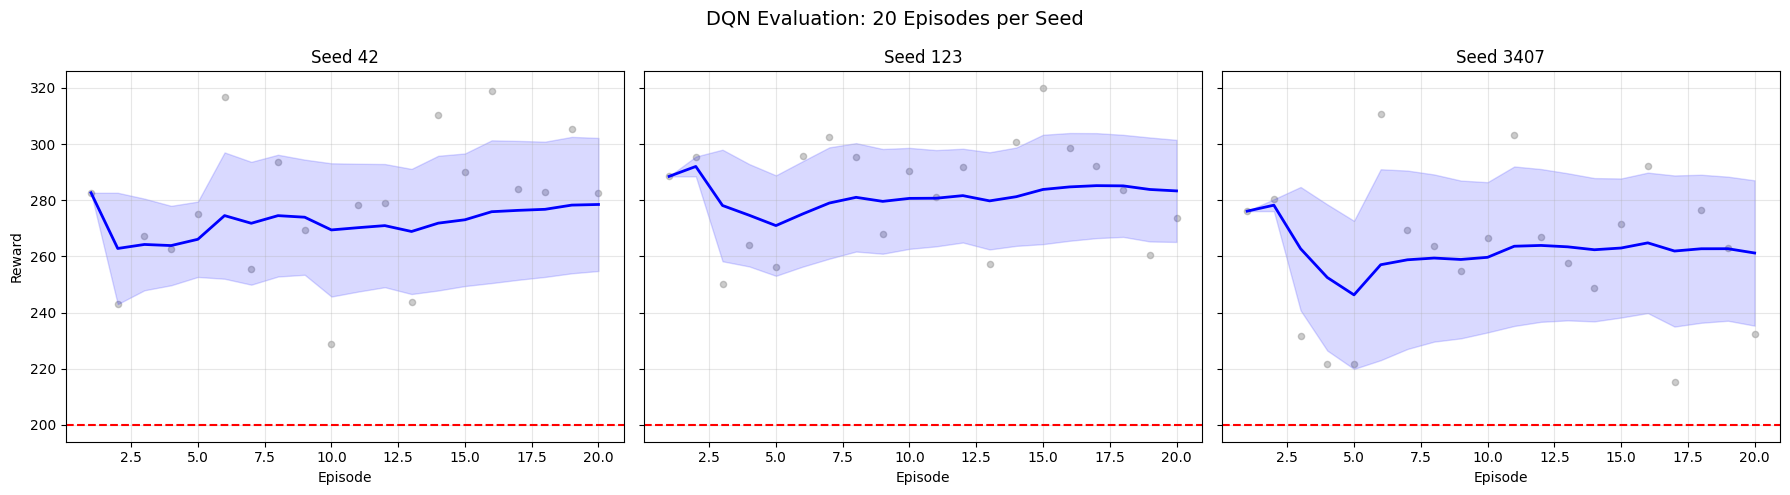

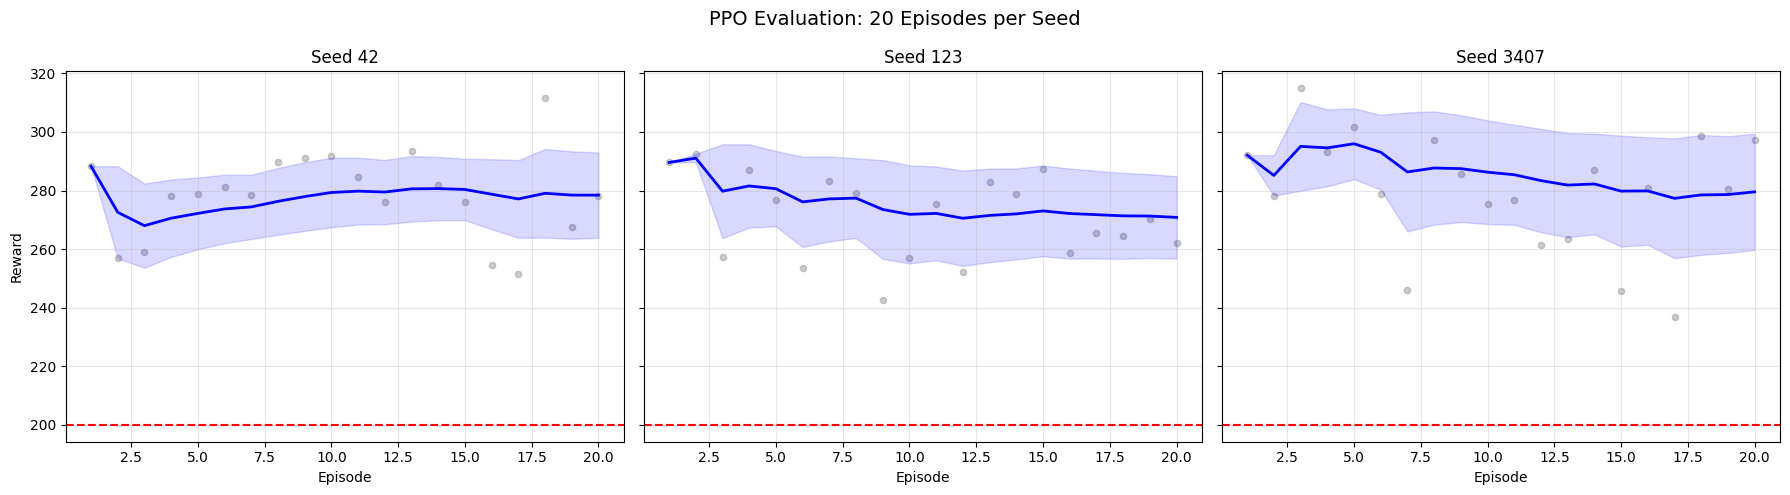

In [28]:
# Per-Algorithm, Per-Seed: Evaluation Convergence Plots

for algo_name in ALGORITHM_MAP:
    fig, axes = plt.subplots(1, len(SEED_LIST), figsize=(6 * len(SEED_LIST), 5), sharey=True)
    if len(SEED_LIST) == 1:
        axes = [axes]

    for ax, seed in zip(axes, SEED_LIST):
        rewards = evaluation_results[algo_name][seed]
        episodes = np.arange(1, len(rewards) + 1)
        running_mean = np.cumsum(rewards) / episodes
        running_std = np.array([np.std(rewards[:i]) for i in episodes])

        ax.scatter(episodes, rewards, color='gray', alpha=0.4, s=20, label='Episode Reward')
        ax.plot(episodes, running_mean, color='blue', linewidth=2, label='Running Mean')
        ax.fill_between(episodes, running_mean - running_std, running_mean + running_std,
                        color='blue', alpha=0.15)
        ax.axhline(y=200, color='red', linestyle='--')
        ax.set_title(f"Seed {seed}")
        ax.set_xlabel("Episode")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Reward")
    fig.suptitle(f"{algo_name.upper()} Evaluation: {EVALUATION_EPISODES} Episodes per Seed", fontsize=14)
    plt.tight_layout()
    plt.show()

**Figure 18** - Evaluation rewards over 20 episodes for DQN (top) and PPO (bottom) across seeds 42, 123, and 3407.

This section reports the final evaluation performance of DQN and PPO using deterministic action selection over 20 evaluation episodes per seed (seeds 42, 123, and 3407). The objective is to assess final policy quality, robustness, and consistency after training, using the best checkpoint selected by the combined score criterion (mean − std), see Figure 18.

The dashed horizontal line at 200 represents the solved threshold of the LunarLander-v3 environment.

### 11.2.1 DQN Evaluation Performance (20 Episodes per Seed)

Across all three seeds, the DQN agents achieve 100% success rate in evaluation, with episode returns consistently above the solved threshold. However, qualitative inspection of the reward dispersion reveals non-negligible variability across episodes and seeds:

* **Seed 42:** Stable performance around ~270–280 reward, with moderate dispersion. Occasional lower-return episodes remain well above the solved threshold.
* **Seed 123:** Highest mean performance among DQN seeds, but with visible variability across episodes, indicating sensitivity to state-specific trajectories.
* **Seed 3407:** Slightly lower mean return and higher variance compared to the other seeds, reflecting residual instability despite successful convergence.

Although DQN reaches competent final policies, the spread of rewards indicates that value-based learning retains higher stochastic variability at evaluation time, even under deterministic execution. This aligns with earlier training-phase observations of instability and sensitivity to random initialization.

### 11.2.2 PPO Evaluation Performance (20 Episodes per Seed)

The PPO agents also achieve 100% success rate across all seeds, with consistently high returns above the solved threshold. Compared to DQN, PPO exhibits tighter reward distributions and more homogeneous performance across episodes:

* **Seed 42:** High and stable returns (~275–285), with relatively narrow confidence bands.
* **Seed 123:** Slightly lower mean performance than the other PPO seeds, but still consistently above threshold with low variance.
* **Seed 3407:** Strong and stable performance, comparable to seed 42, with limited dispersion.

PPO demonstrates more robust and consistent final policies across seeds. The reduced variance in evaluation rewards suggests that policy-based optimization with clipped updates generalizes more reliably to deterministic execution, yielding stable landing behaviours with fewer outliers.

### 11.2.3 DQN vs PPO Comparative Analysis

While both algorithms solve the task reliably at evaluation time, qualitative comparison of the evaluation curves highlights clear differences:

* PPO achieves slightly higher or comparable mean returns across seeds relative to DQN.
* PPO shows lower dispersion of episode rewards, indicating more stable and predictable behaviour. DQN, although successful, exhibits greater variability, reflecting residual sensitivity in value estimates.
* PPO performance is more uniform across seeds, whereas DQN shows noticeable seed-dependent differences (particularly in seed 3407).

Both DQN and PPO achieve 100% success rates in deterministic evaluation, confirming that both methods can learn effective landing policies in LunarLander-v3. However, PPO demonstrates superior robustness and consistency in final performance, reinforcing the conclusion drawn from training dynamics that policy-based methods with constrained updates provide more stable and reliable solutions for this continuous-state control problem.

## 11.3  Mean Reward Per Seed

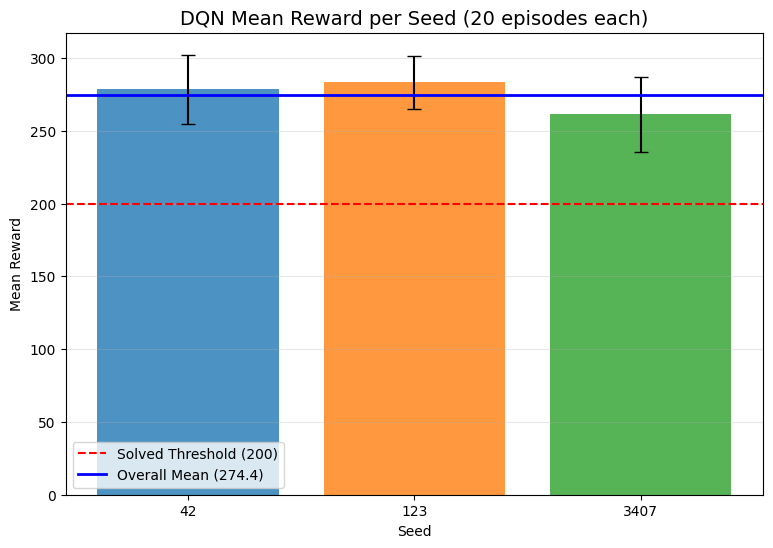

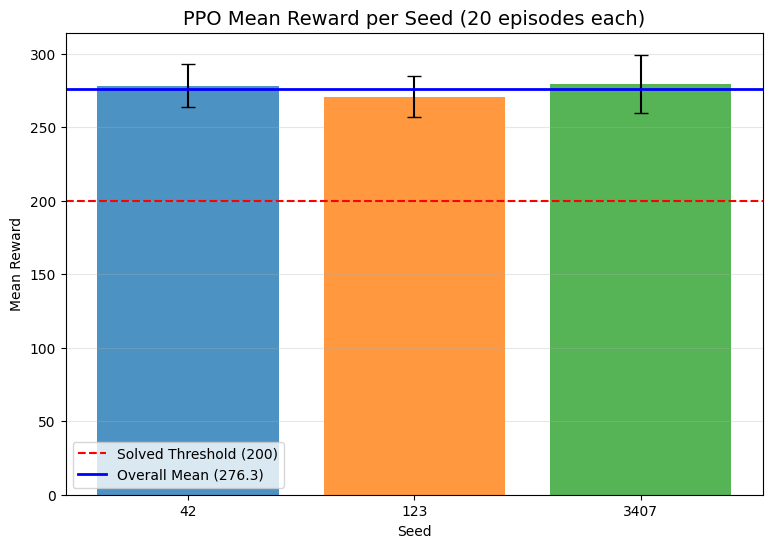

In [30]:
# Per-Algorithm: Evaluation Bar Chart (mean reward per seed with error bars)

for algo_name in ALGORITHM_MAP:
    all_r = np.concatenate([evaluation_results[algo_name][s] for s in SEED_LIST])
    means = [np.mean(evaluation_results[algo_name][s]) for s in SEED_LIST]
    stds = [np.std(evaluation_results[algo_name][s]) for s in SEED_LIST]
    labels = [str(s) for s in SEED_LIST]

    plt.figure(figsize=(max(8, 3 * len(SEED_LIST)), 6))
    plt.bar(labels, means, yerr=stds, capsize=5, color=seed_colors[:len(SEED_LIST)], alpha=0.8)
    plt.axhline(y=200, color='red', linestyle='--', label='Solved Threshold (200)')
    plt.axhline(y=float(np.mean(all_r)), color='blue', linestyle='-', linewidth=2,
                label=f'Overall Mean ({np.mean(all_r):.1f})')

    plt.title(f"{algo_name.upper()} Mean Reward per Seed ({EVALUATION_EPISODES} episodes each)", fontsize=14)
    plt.xlabel("Seed")
    plt.ylabel("Mean Reward")
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.show()

**Figure 19** - Mean evaluation reward per seed for DQN (top) and PPO (bottom), with solved threshold at 200.

Figure 19 shows the evaluation reward per seed for each model. In DQN, the per-seed evaluation plots for DQN show that all selected best checkpoints achieve returns well above the solved threshold (200) across all evaluation episodes. However, the dispersion of points and the width of the confidence band vary by seed. In particular, seed 3407 exhibits larger variability across evaluation episodes, with a few lower-return outliers closer to the threshold. This indicates that while the final DQN policies are competent, their performance is more sensitive to episode-level stochasticity, reflecting residual instability in the learned Q-function.
 
PPO evaluation curves are consistently above the solved threshold across all seeds, with tighter confidence bands compared to DQN. The per-episode scatter shows fewer low-return outliers and more concentrated performance around the mean. This suggests that PPO’s final policies are not only high-performing but also more consistent across evaluation episodes, aligning with the stability observed during training.

## 11.4 Per-Algorithm: Reward Distribution Histograms

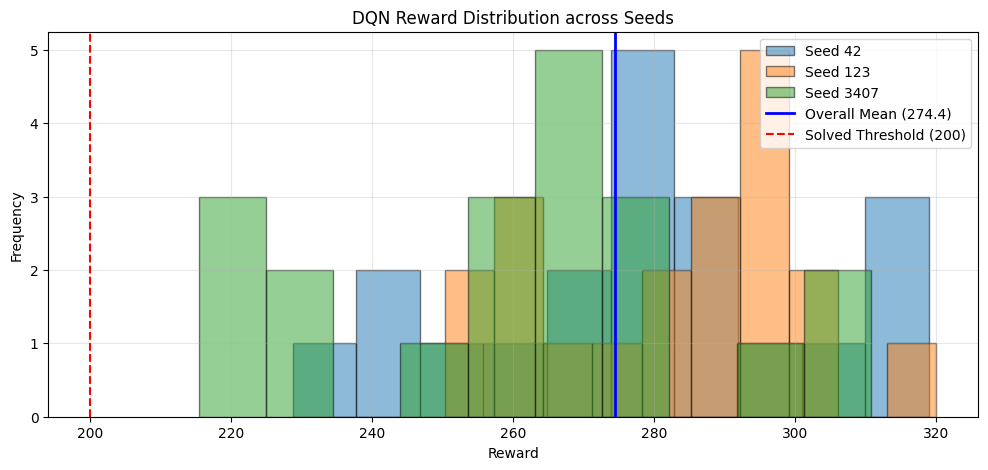

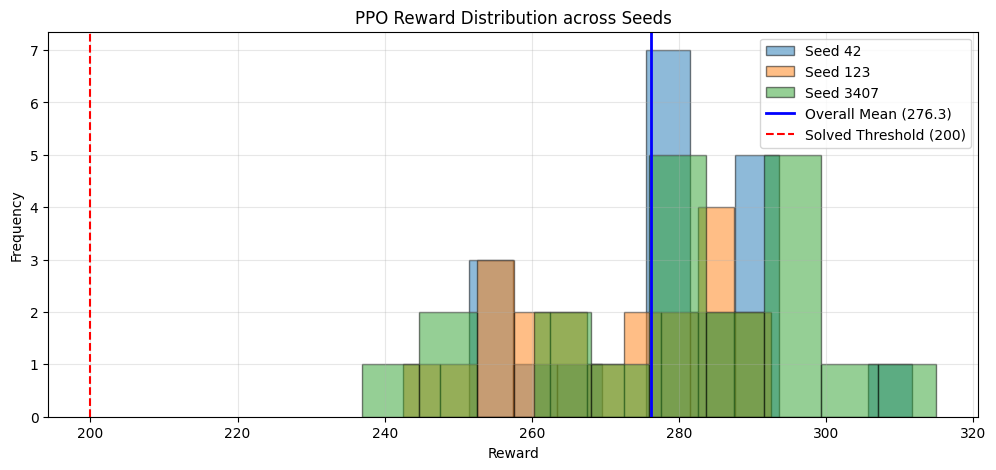

In [31]:
# Per-Algorithm: Reward Distribution Histograms (overlaid per seed)

for algo_name in ALGORITHM_MAP:
    all_r = np.concatenate([evaluation_results[algo_name][s] for s in SEED_LIST])

    plt.figure(figsize=(12, 5))
    for i, seed in enumerate(SEED_LIST):
        plt.hist(evaluation_results[algo_name][seed], bins=10, alpha=0.5,
                 color=seed_colors[i], edgecolor='black', label=f"Seed {seed}")

    plt.axvline(x=float(np.mean(all_r)), color='blue', linestyle='-', linewidth=2,
                label=f'Overall Mean ({np.mean(all_r):.1f})')
    plt.axvline(x=200, color='red', linestyle='--', label='Solved Threshold (200)')
    plt.title(f'{algo_name.upper()} Reward Distribution across Seeds')
    plt.xlabel('Reward')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

**Figure 20** -Reward distributions for DQN (top) and PPO (bottom) across seeds, with overall mean and solved threshold indicated.

In Figure 20, the reward distributions across seeds illustrate the final performance consistency of both algorithms. 

In DQN, the reward distribution shows broader spread across seeds, with noticeable variability between runs. While all seeds are well above the solved threshold (200), the dispersion indicates higher sensitivity to initialization, with some lower-tail mass compared to PPO.

The PPO distribution is more concentrated around higher rewards, with tighter clustering across seeds. This suggests more consistent performance and lower variance in final policy quality.

Both algorithms achieve strong post-training performance, but PPO exhibits a narrower distribution and slightly higher central tendency, indicating more reliable and stable outcomes across random seeds.

# 12. Cross-Algorithm Evaluation

In [32]:
# Cross-Algorithm: Combined Summary Table

rows = []
for algo_name in ALGORITHM_MAP:
    all_r = np.concatenate([evaluation_results[algo_name][s] for s in SEED_LIST])
    rows.append({
        "Algorithm": algo_name.upper(),
        "Mean Reward": f"{np.mean(all_r):.2f}",
        "Std Dev": f"{np.std(all_r):.2f}",
        "Min Reward": f"{np.min(all_r):.2f}",
        "Max Reward": f"{np.max(all_r):.2f}",
        "Success Rate": f"{(all_r >= 200).sum() / len(all_r) * 100:.1f}%"
    })

print(f"*** CROSS-ALGORITHM EVALUATION SUMMARY ***")
print(f"Seeds: {SEED_LIST} | Episodes per seed: {EVALUATION_EPISODES}")
print(f"Total episodes per algorithm: {EVALUATION_EPISODES * len(SEED_LIST)}")
print()
print(pd.DataFrame(rows).to_string(index=False))

*** CROSS-ALGORITHM EVALUATION SUMMARY ***
Seeds: [42, 123, 3407] | Episodes per seed: 20
Total episodes per algorithm: 60

Algorithm Mean Reward Std Dev Min Reward Max Reward Success Rate
      DQN      274.36   24.72     215.37     319.93       100.0%
      PPO      276.27   16.81     236.91     314.95       100.0%


## 12.1 Cross-Algorithm Evaluation – Discussion

| Algorithm | Mean Reward | Std Dev | Min Reward | Max Reward | Success Rate |
|-----------|-------------|---------|------------|------------|--------------|
| DQN       | 274.36      | 24.72   | 215.37     | 319.93     | 100.0%       |
| PPO       | 276.27      | 16.81   | 236.91     | 314.95     | 100.0%       |

**Table 9** – Cross-Algorithm Evaluation Summary (60 evaluation episodes per algorithm)

Both algorithms achieve a 100% success rate in the final evaluation (60 episodes per algorithm), confirming that both DQN and PPO are capable of learning effective landing policies for the LunarLander environment. The average returns are very close (≈274 for DQN and ≈276 for PPO), indicating no clear advantage in terms of final mean performance.

However, a relevant difference emerges in terms of performance variability and robustness. PPO exhibits a substantially lower standard deviation (16.81 vs. 24.72 for DQN) and a higher minimum reward (236.91 vs. 215.37), suggesting that PPO produces more consistent and reliable policies across evaluation episodes. In practical terms, this means PPO is less prone to occasional poor landings or suboptimal behaviours at deployment time.

Therefore, although both algorithms reach comparable peak performance, PPO demonstrates superior stability and robustness in execution, reinforcing the conclusions drawn from the training dynamics and stability analyses.

## 12.2 Cross-Algorithm Evaluation: Mean Reward

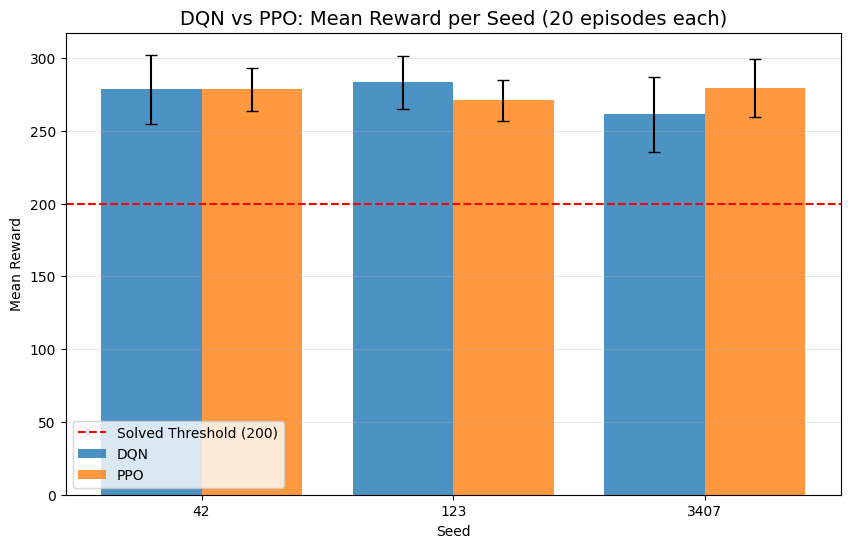

In [33]:
# Cross-Algorithm: Grouped Bar Chart (DQN vs PPO per seed)

n_algos = len(algo_names)
n_seeds = len(SEED_LIST)
bar_width = 0.8 / n_algos
x = np.arange(n_seeds)

plt.figure(figsize=(max(10, 3 * n_seeds), 6))
for i, algo_name in enumerate(algo_names):
    means = [np.mean(evaluation_results[algo_name][s]) for s in SEED_LIST]
    stds = [np.std(evaluation_results[algo_name][s]) for s in SEED_LIST]
    offset = (i - (n_algos - 1) / 2) * bar_width
    plt.bar(x + offset, means, bar_width, yerr=stds, capsize=4,
            label=algo_name.upper(), alpha=0.8)

plt.axhline(y=200, color='red', linestyle='--', label='Solved Threshold (200)')
plt.xticks(x, [str(s) for s in SEED_LIST])
plt.title(f"DQN vs PPO: Mean Reward per Seed ({EVALUATION_EPISODES} episodes each)", fontsize=14)
plt.xlabel("Seed")
plt.ylabel("Mean Reward")
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

**Figure 21** - Mean evaluation reward per seed for DQN and PPO, with solved threshold at 200.

Figure 21 compares the final evaluation performance of DQN and PPO across the three random seeds (42, 123, 3407), using the mean reward over 20 deterministic evaluation episodes per seed. The dashed red line indicates the solved threshold (reward = 200).

Across all seeds, both algorithms comfortably surpass the solved threshold, confirming that the selected best checkpoints correspond to fully converged policies. However, important differences emerge in terms of cross-seed robustness and relative performance stability:

- **Seed 42:** DQN and PPO achieve very similar mean rewards, with overlapping error bars. This suggests comparable final performance under this initialization, with no clear advantage for either algorithm.

- **Seed 123:** DQN exhibits a slightly higher mean reward than PPO, although the confidence intervals still overlap. This indicates that, for this seed, DQN converged to a marginally better-performing policy, but without strong statistical separation.

- **Seed 3407:** PPO clearly outperforms DQN in terms of mean reward, and the gap is larger than in the other seeds. Moreover, DQN shows wider error bars, pointing to higher variability in evaluation returns and reduced robustness for this particular initialization.

While both DQN and PPO achieve solved performance in all cases, PPO demonstrates more consistent behavior across seeds, whereas DQN shows greater sensitivity to initialization. The performance advantage alternates depending on the seed (DQN slightly stronger for seed 123, PPO stronger for seed 3407), but PPO displays lower variability in the final evaluation stage. 

## 12.3 Overall Evaluation: Mean Reward Aggregated

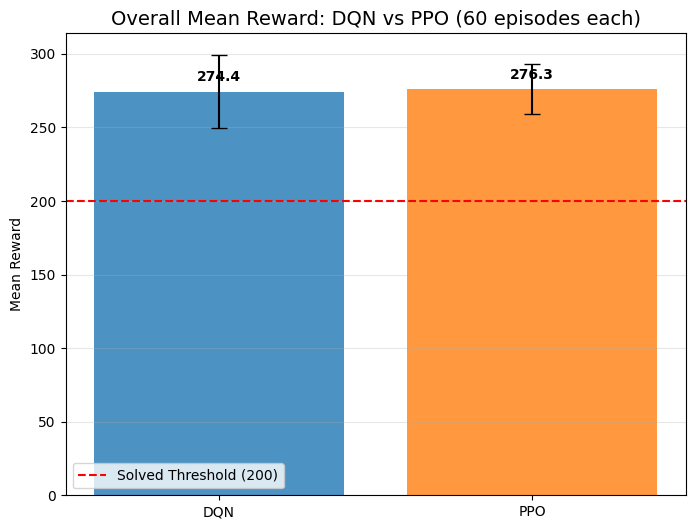

In [34]:
# Cross-Algorithm: Overall Mean Reward Bar Chart

overall_means = []
overall_stds = []
for algo_name in algo_names:
    all_r = np.concatenate([evaluation_results[algo_name][s] for s in SEED_LIST])
    overall_means.append(np.mean(all_r))
    overall_stds.append(np.std(all_r))

plt.figure(figsize=(8, 6))
bars = plt.bar([a.upper() for a in algo_names], overall_means, yerr=overall_stds,
               capsize=6, color=[algo_colors[a] for a in algo_names], alpha=0.8)
plt.axhline(y=200, color='red', linestyle='--', label='Solved Threshold (200)')

for bar, mean in zip(bars, overall_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f'{mean:.1f}', ha='center', va='bottom', fontweight='bold')

plt.title(f"Overall Mean Reward: DQN vs PPO ({EVALUATION_EPISODES * len(SEED_LIST)} episodes each)", fontsize=14)
plt.ylabel("Mean Reward")
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

**Figure 22** - Overall mean evaluation reward for DQN and PPO, with solved threshold at 200.

Both algorithms achieve a mean reward substantially above the solved threshold, see Figure 22, confirming that they learned stable and high-performing policies. The overall mean rewards are very close, with PPO achieving a slightly higher average return than DQN:

- **DQN:** Mean reward ≈ 274.4  
- **PPO:** Mean reward ≈ 276.3  

The difference in average performance is marginal and falls within the range of variability indicated by the error bars, suggesting no statistically significant performance gap under the chosen evaluation protocol. However, when combined with the per-seed analysis (Figure 11.5), this aggregated result highlights two complementary aspects:

- **Peak performance:** Both algorithms are capable of reaching similarly high final performance levels.  
- **Robustness:** PPO exhibits slightly lower dispersion in the aggregated evaluation, indicating more consistent behavior across different random seeds.
 
At convergence, DQN and PPO achieve comparable final performance in terms of mean reward. The small advantage observed for PPO in the aggregated evaluation should be interpreted as a robustness effect rather than a clear superiority in asymptotic performance. This reinforces the conclusion that PPO provides more stable and reliable convergence across random initializations, while DQN can reach equally strong performance in favorable conditions.

## 12.4  DQN vs PPO Evaluation Reward Distribution

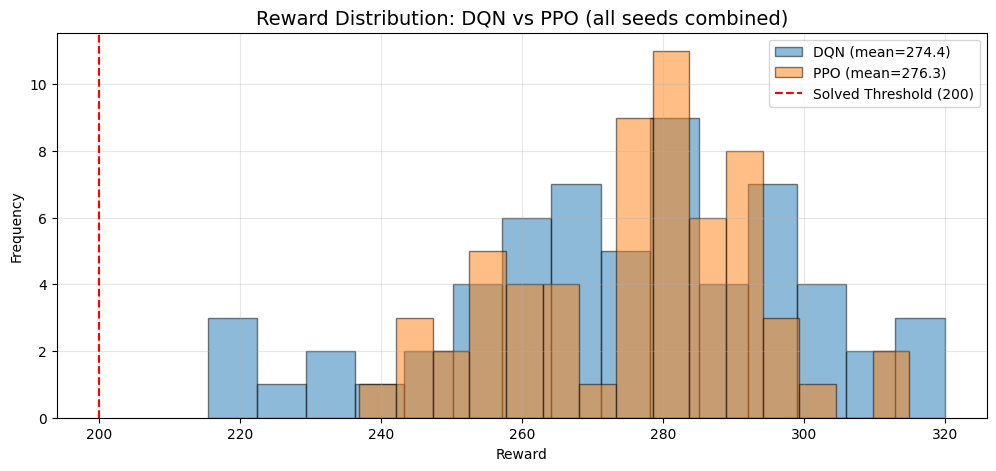

In [35]:
# Cross-Algorithm: Reward Distribution Comparison (overlaid histograms)

plt.figure(figsize=(12, 5))
for algo_name in algo_names:
    all_r = np.concatenate([evaluation_results[algo_name][s] for s in SEED_LIST])
    plt.hist(all_r, bins=15, alpha=0.5, color=algo_colors[algo_name],
             edgecolor='black', label=f"{algo_name.upper()} (mean={np.mean(all_r):.1f})")

plt.axvline(x=200, color='red', linestyle='--', label='Solved Threshold (200)')
plt.title('Reward Distribution: DQN vs PPO (all seeds combined)', fontsize=14)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Figure 23** - Reward distributions for DQN and PPO across all seeds, with overall means and solved threshold indicated.

The distributions of both algorithms are clearly shifted well to the right of the solved threshold see Figure 23, confirming that all evaluated policies consistently operate in the solved regime. Most of the mass of both distributions lies approximately in the range [250, 300], with occasional higher-reward episodes extending above 300.

Several observations can be drawn:

* The distributions largely overlap, which is consistent with the very close mean rewards reported previously (DQN ≈ 274.4, PPO ≈ 276.3). This indicates that both methods achieve comparable average performance at evaluation time.

* PPO exhibits a slightly more concentrated distribution around its mean, whereas DQN shows marginally heavier tails, including both lower outliers (closer to 220–240) and higher peaks (above 300). This suggests that DQN can occasionally achieve very high rewards but with somewhat larger variability.

* No evaluation episode falls below the solved threshold, indicating that both algorithms produce robustly solved policies under deterministic evaluation.
 
The reward distributions reinforce the conclusions drawn from the mean-based analysis: DQN and PPO reach comparable final performance levels, while PPO displays slightly tighter concentration around its mean, pointing to marginally higher consistency across evaluation episodes. DQN, in contrast, exhibits broader dispersion, reflecting higher variance in episodic outcomes despite similar average performance.

## 12.5 DQN vs PPO Reward Distribution

/tmp/ipykernel_6515/3208474440.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[a.upper() for a in algo_names], patch_artist=True)
/tmp/ipykernel_6515/3208474440.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[a.upper() for a in algo_names], patch_artist=True)
/tmp/ipykernel_6515/3208474440.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[a.upper() for a in algo_names], patch_artist=True)


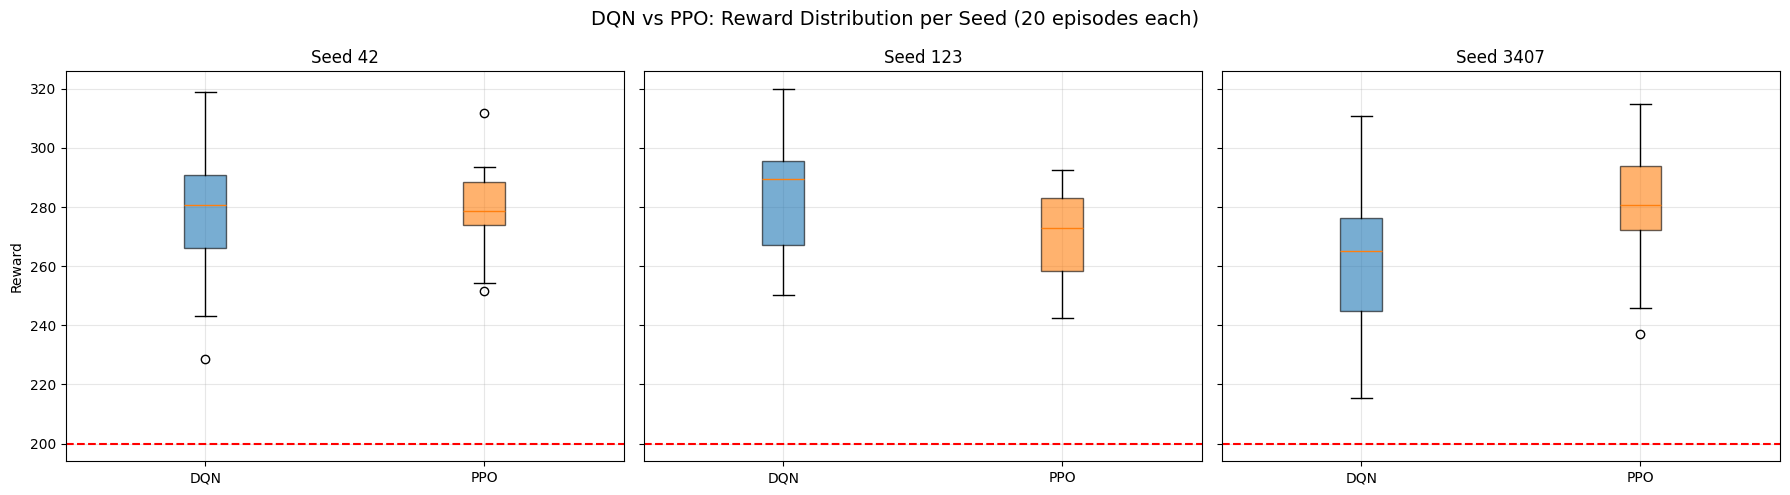

In [36]:
# Cross-Algorithm: Box Plot Comparison per Seed

fig, axes = plt.subplots(1, len(SEED_LIST), figsize=(6 * len(SEED_LIST), 5), sharey=True)
if len(SEED_LIST) == 1:
    axes = [axes]

for ax, seed in zip(axes, SEED_LIST):
    data = [evaluation_results[algo_name][seed] for algo_name in algo_names]
    bp = ax.boxplot(data, tick_labels=[a.upper() for a in algo_names], patch_artist=True)
    for patch, algo_name in zip(bp['boxes'], algo_names):
        patch.set_facecolor(algo_colors[algo_name])
        patch.set_alpha(0.6)
    ax.axhline(y=200, color='red', linestyle='--')
    ax.set_title(f"Seed {seed}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Reward")
fig.suptitle(f"DQN vs PPO: Reward Distribution per Seed ({EVALUATION_EPISODES} episodes each)", fontsize=14)
plt.tight_layout()
plt.show()

**Figure 24** - Boxplots of evaluation rewards for DQN and PPO across seeds 42, 123, and 3407.

In Figure 24, the per-seed boxplots compare the reward distributions of DQN and PPO over 20 evaluation episodes. PPO shows a tighter interquartile range and fewer low-end outliers across seeds, indicating more consistent performance. DQN achieves comparable or slightly higher medians in some seeds, but with larger dispersion, reflecting higher sensitivity to stochasticity and occasional lower-reward episodes.

# 13. Statistical Significance

Two statistical tests assess whether the observed performance difference between DQN and PPO is significant. The Mann-Whitney U test compares reward distributions (non-parametric, no normality assumption). The Chi-squared test compares success rates as a proportion.

In [37]:
# Statistical Significance: Mann-Whitney U Tests

algo_all_rewards = {}
for algo_name in algo_names:
    algo_all_rewards[algo_name] = np.concatenate([evaluation_results[algo_name][s] for s in SEED_LIST])

# Reward comparison (Mann-Whitney U)
mwu_result = stats.mannwhitneyu(
    algo_all_rewards[algo_names[0]],
    algo_all_rewards[algo_names[1]],
    alternative='two-sided'
)
stat_reward = float(mwu_result.statistic)
p_reward = float(mwu_result.pvalue)

# Success rate comparison (Chi-squared)
successes = []
totals = []
for algo_name in algo_names:
    r = algo_all_rewards[algo_name]
    successes.append(int((r >= 200).sum()))
    totals.append(len(r))

failures = [t - s for t, s in zip(totals, successes)]
contingency = np.array([successes, failures])

if np.all(contingency.sum(axis=1) > 0) and np.all(contingency.sum(axis=0) > 0):
    chi2_result = stats.chi2_contingency(contingency)
    chi2 = float(chi2_result[0])
    p_success = float(chi2_result[1])
    chi2_valid = True
else:
    chi2, p_success = 0.0, 1.0
    chi2_valid = False

chi2_note = "" if chi2_valid else " (skipped: zero row/col)"
rows = [
    {
        "Metric": "Mean Reward",
        f"{algo_names[0].upper()} Value": f"{np.mean(algo_all_rewards[algo_names[0]]):.2f}",
        f"{algo_names[1].upper()} Value": f"{np.mean(algo_all_rewards[algo_names[1]]):.2f}",
        "Test": "Mann-Whitney U",
        "Statistic": f"{stat_reward:.1f}",
        "p-value": f"{p_reward:.4f}",
        "Significant (p<0.05)": "Yes" if p_reward < 0.05 else "No"
    },
    {
        "Metric": "Success Rate (>=200)",
        f"{algo_names[0].upper()} Value": f"{successes[0]/totals[0]*100:.1f}%",
        f"{algo_names[1].upper()} Value": f"{successes[1]/totals[1]*100:.1f}%",
        "Test": f"Chi-squared{chi2_note}",
        "Statistic": f"{chi2:.2f}",
        "p-value": f"{p_success:.4f}",
        "Significant (p<0.05)": "Yes" if (chi2_valid and p_success < 0.05) else "No"
    },
]

print("*** STATISTICAL SIGNIFICANCE TESTS ***")
print(f"Sample size per algorithm: {totals[0]} episodes ({EVALUATION_EPISODES} episodes x {len(SEED_LIST)} seeds)")
print()
print(pd.DataFrame(rows).to_string(index=False))

*** STATISTICAL SIGNIFICANCE TESTS ***
Sample size per algorithm: 60 episodes (20 episodes x 3 seeds)

              Metric DQN Value PPO Value                                Test Statistic p-value Significant (p<0.05)
         Mean Reward    274.36    276.27                      Mann-Whitney U    1771.0  0.8811                   No
Success Rate (>=200)    100.0%    100.0% Chi-squared (skipped: zero row/col)      0.00  1.0000                   No


| Metric                | DQN Value | PPO Value | Statistical Test                  | Test Statistic | p-value | Significant (p < 0.05) |
|-----------------------|-----------|-----------|-----------------------------------|----------------|---------|-------------------------|
| Mean Reward           | 274.36    | 276.27    | Mann–Whitney U                    | 1771.0         | 0.8811  | No                      |
| Success Rate (≥ 200)  | 100.0%    | 100.0%    | Chi-squared (not applicable\*)    | –              | 1.0000  | No                      |

**Table 10** - Sample size per algorithm: 60 evaluation episodes (20 episodes × 3 seeds)

The statistical significance tests indicate that there is no evidence of a meaningful performance difference between DQN and PPO under the evaluation protocol adopted. Although PPO achieved a slightly higher mean reward (276.27) than DQN (274.36), the Mann–Whitney U test yielded a high p-value (p = 0.8811), showing that this difference is not statistically significant and can be attributed to sampling variability, see Table 10.

Regarding task success, both algorithms achieved a 100% success rate across all evaluation episodes and seeds. As a consequence, the chi-squared test is not informative in this setting due to the absence of variance in the success outcomes. This result indicates that, once trained, both DQN and PPO consistently solve the environment, and the evaluation phase does not reveal systematic failures for either method.

These findings suggest that performance differences observed during training dynamics do not translate into statistically distinguishable outcomes at evaluation time. In practical terms, both algorithms can be considered equally effective in terms of final policy quality for this environment, with PPO offering advantages mainly in terms of training stability and sample efficiency rather than final asymptotic performance.

# 14. Baseline Comparison

In [38]:
# Random Agent Baseline Evaluation

random_results = {}

for seed in SEED_LIST:
    print(f"Running random agent with seed {seed}...")
    env = gym.make(GYMNASIUM_MODEL, enable_wind=WIND_ENABLED)
    env.action_space.seed(seed)
    episode_rewards = []

    for ep in range(EVALUATION_EPISODES):
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0.0
        done = False

        while not done:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += float(reward)
            done = terminated or truncated

        episode_rewards.append(total_reward)

    random_results[seed] = np.array(episode_rewards)
    env.close()

print("Random baseline evaluation complete.")

Running random agent with seed 42...
Running random agent with seed 123...
Running random agent with seed 3407...
Random baseline evaluation complete.


*** BASELINE COMPARISON ***
 Agent Mean Reward Std Dev     Min    Max Success Rate
Random     -207.06  110.45 -416.10  15.45         0.0%
   DQN      274.36   24.72  215.37 319.93       100.0%
   PPO      276.27   16.81  236.91 314.95       100.0%



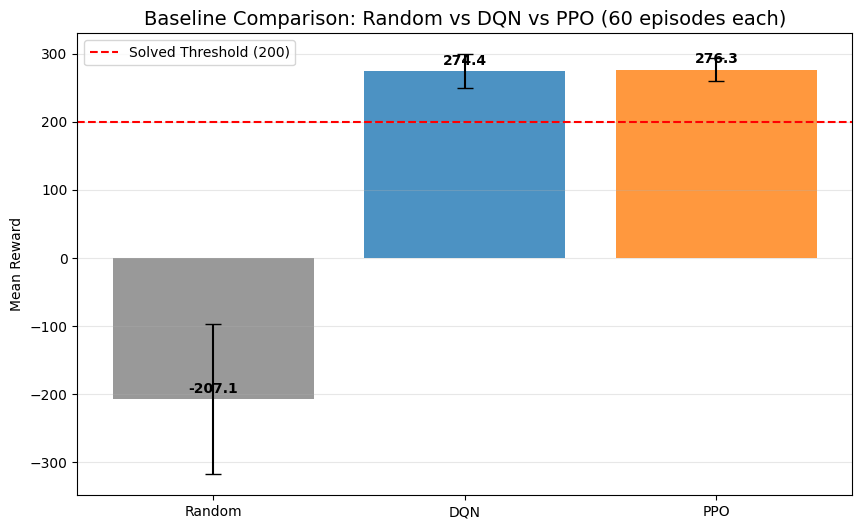

In [39]:
# Baseline Comparison: Table + Chart

algo_all_rewards = {a: np.concatenate([evaluation_results[a][s] for s in SEED_LIST]) for a in algo_names}
all_random = np.concatenate([random_results[s] for s in SEED_LIST])

rows = [
    {
        "Agent": "Random",
        "Mean Reward": f"{np.mean(all_random):.2f}",
        "Std Dev": f"{np.std(all_random):.2f}",
        "Min": f"{np.min(all_random):.2f}",
        "Max": f"{np.max(all_random):.2f}",
        "Success Rate": f"{(all_random >= 200).sum() / len(all_random) * 100:.1f}%"
    }
]
for algo_name in algo_names:
    all_r = algo_all_rewards[algo_name]
    rows.append({
        "Agent": algo_name.upper(),
        "Mean Reward": f"{np.mean(all_r):.2f}",
        "Std Dev": f"{np.std(all_r):.2f}",
        "Min": f"{np.min(all_r):.2f}",
        "Max": f"{np.max(all_r):.2f}",
        "Success Rate": f"{(all_r >= 200).sum() / len(all_r) * 100:.1f}%"
    })

print("*** BASELINE COMPARISON ***")
print(pd.DataFrame(rows).to_string(index=False))
print()

# Bar chart
agent_labels = ["Random"] + [a.upper() for a in algo_names]
agent_means = [np.mean(all_random)] + [np.mean(algo_all_rewards[a]) for a in algo_names]
agent_stds = [np.std(all_random)] + [np.std(algo_all_rewards[a]) for a in algo_names]
bar_colors = ["gray"] + [algo_colors[a] for a in algo_names]

plt.figure(figsize=(10, 6))
bars = plt.bar(agent_labels, agent_means, yerr=agent_stds, capsize=6,
               color=bar_colors, alpha=0.8)
plt.axhline(y=200, color='red', linestyle='--', label='Solved Threshold (200)')

for bar, mean in zip(bars, agent_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f'{mean:.1f}', ha='center', va='bottom', fontweight='bold')

plt.title(f"Baseline Comparison: Random vs DQN vs PPO ({EVALUATION_EPISODES * len(SEED_LIST)} episodes each)", fontsize=14)
plt.ylabel("Mean Reward")
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

**Figure 25** - Mean reward comparison for Random, DQN, and PPO over 60 episodes, with solved threshold at 200.

| Agent  | Mean Reward | Std Dev | Min Reward | Max Reward | Success Rate |
|--------|-------------|---------|------------|------------|---------------|
| Random | -207.06     | 110.45  | -416.10    | 15.45      | 0.0%          |
| DQN    | 274.36      | 24.72   | 215.37     | 319.93     | 100.0%        |
| PPO    | 276.27      | 16.81   | 236.91     | 314.95     | 100.0%        |

**Table 11** - Agent Baseline Comparison (Mean, Std, Min, Max)



The baseline comparison highlights a clear and substantial performance gap between the learned policies (DQN and PPO) and the random agent. The random policy yields a strongly negative mean reward (−207.06) with very high variance, failing in all evaluation episodes (0% success rate). This confirms that the task is non-trivial and cannot be solved without learning structured control policies, see Table 11.

In contrast, both DQN and PPO achieve consistently high mean rewards well above the solved threshold (200), with a 100% success rate across all evaluation episodes. This demonstrates that both reinforcement learning methods successfully learned effective landing strategies for the LunarLander environment.

While the average rewards of DQN (274.36) and PPO (276.27) are very similar, PPO exhibits lower variance in performance (standard deviation 16.81 vs 24.72 for DQN), indicating more consistent behaviour across episodes. This suggests that PPO produces more stable policies at evaluation time, even though the final mean performance of both algorithms is comparable.

Overall, this comparison confirms that:

* The improvements over the random baseline are large and unequivocal.
* Both DQN and PPO reliably solve the task.
* PPO offers slightly higher robustness and consistency, whereas DQN achieves comparable peak performance but with higher variability.

# 15. Agent Behavior Analysis

Beyond aggregate performance metrics (reward, success rate and stability), it is important to analyse how the agents behave at a decision-making level. In reinforcement learning, similar performance outcomes can emerge from different control strategies, and understanding these behavioural patterns provides additional insight into the nature of the learned policies.

This section focuses on the action-level behaviour of the trained agents, comparing DQN and PPO in terms of how frequently each action is selected during evaluation. By analysing the distribution of actions (e.g., *Do Nothing*, *Fire Left*, *Fire Main*, *Fire Right*) across all evaluation episodes and seeds, we aim to characterise:

* The degree of conservativeness vs. actuation intensity in each policy,  
* Potential differences in control smoothness and stability,  
* Whether distinct action usage patterns may help explain observed differences in learning dynamics, variance, and robustness.


In [40]:
# Collect per-step data: actions and trajectories

action_counts = {}       # {algo: np.array of shape (4,)} total action counts
trajectory_data = {}     # {algo: list of (x_positions, y_positions)} one per TRAJECTORY_EPISODES

for algo_name, algo_class in ALGORITHM_MAP.items():
    action_counts[algo_name] = np.zeros(len(ACTION_LABELS), dtype=int)
    trajectory_data[algo_name] = []

    for seed in SEED_LIST:
        load_path = best_model_paths.get(algo_name, {}).get(seed)
        if load_path is None:
            continue

        def make_env(s=seed):
            env = gym.make(GYMNASIUM_MODEL, render_mode="rgb_array", enable_wind=WIND_ENABLED)
            env.reset(seed=s)
            return env

        model = algo_class.load(load_path, env=DummyVecEnv([make_env]), device=DEVICE)
        env = gym.make(GYMNASIUM_MODEL, enable_wind=WIND_ENABLED)

        for ep in range(EVALUATION_EPISODES):
            obs, info = env.reset(seed=seed + ep)
            done = False
            x_pos, y_pos = [obs[0]], [obs[1]]

            while not done:
                action, _ = model.predict(obs, deterministic=True)
                action_int = int(action)
                action_counts[algo_name][action_int] += 1

                obs, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                x_pos.append(obs[0])
                y_pos.append(obs[1])

            if seed == SEED_LIST[0] and ep < TRAJECTORY_EPISODES:
                trajectory_data[algo_name].append((np.array(x_pos), np.array(y_pos)))

        env.close()

    total_actions = action_counts[algo_name].sum()
    print(f"{algo_name.upper()}: {total_actions:,} total actions collected across {EVALUATION_EPISODES * len(SEED_LIST)} episodes")

print("\nBehavior data collection complete.")

DQN: 14,451 total actions collected across 60 episodes
PPO: 16,544 total actions collected across 60 episodes

Behavior data collection complete.


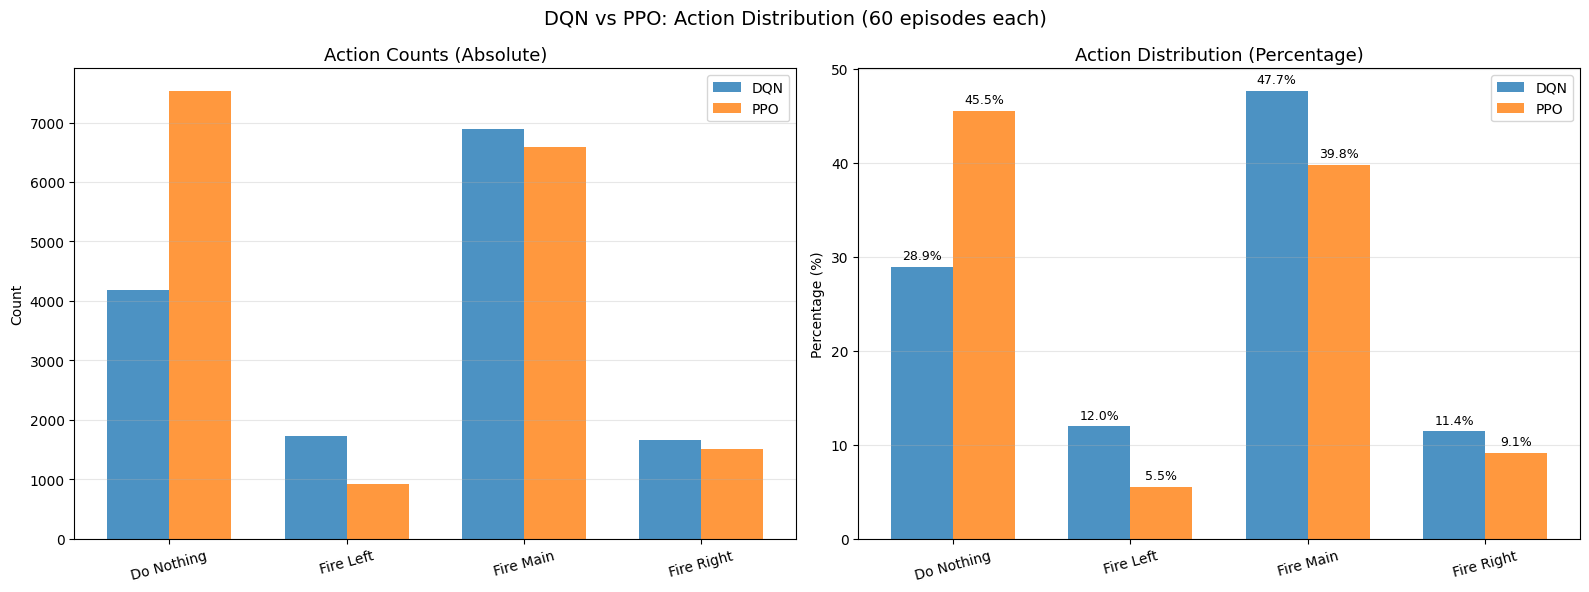

In [41]:
# Action Distribution: DQN vs PPO

n_actions = len(ACTION_LABELS)
x = np.arange(n_actions)
bar_width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts
for i, algo_name in enumerate(algo_names):
    offset = (i - 0.5) * bar_width
    ax1.bar(x + offset, action_counts[algo_name], bar_width,
            label=algo_name.upper(), color=algo_colors[algo_name], alpha=0.8)

ax1.set_xticks(x)
ax1.set_xticklabels(ACTION_LABELS, rotation=15)
ax1.set_title("Action Counts (Absolute)", fontsize=13)
ax1.set_ylabel("Count")
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Percentage distribution
for i, algo_name in enumerate(algo_names):
    pcts = action_counts[algo_name] / action_counts[algo_name].sum() * 100
    offset = (i - 0.5) * bar_width
    bars = ax2.bar(x + offset, pcts, bar_width,
                   label=algo_name.upper(), color=algo_colors[algo_name], alpha=0.8)
    for bar, pct in zip(bars, pcts):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(ACTION_LABELS, rotation=15)
ax2.set_title("Action Distribution (Percentage)", fontsize=13)
ax2.set_ylabel("Percentage (%)")
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

fig.suptitle(f"DQN vs PPO: Action Distribution ({EVALUATION_EPISODES * len(SEED_LIST)} episodes each)", fontsize=14)
plt.tight_layout()
plt.show()

**Figure 26** - Absolute and percentage action distributions for DQN and PPO across 60 episodes.

## 15.1 Action Distribution Analysis

Figure 26 presents the action distribution of the trained agents during evaluation, aggregated across all seeds and episodes. Two complementary views are provided: absolute action counts and relative frequencies (percentages), allowing a direct comparison between DQN and PPO in terms of behavioural tendencies.

Overall, both agents exhibit a dominant preference for the *Fire Main* action, which is consistent with the objective of maintaining continuous thrust to stabilize and control the lander. However, clear behavioural differences emerge in the secondary actions and in the balance between active control and inaction.

PPO displays a substantially higher proportion of *Do Nothing* actions (≈45.5%) compared to DQN (≈28.9%). This suggests that PPO learned a more conservative and smooth control policy, relying more frequently on inaction to maintain stability once a favourable trajectory is achieved. Such behaviour is coherent with PPO’s policy-gradient optimisation and entropy-regularised updates, which tend to promote smoother action distributions and reduced oscillatory control.

In contrast, DQN shows a higher relative usage of corrective actions, particularly *Fire Left* (≈12.0% vs. ≈5.5% for PPO) and *Fire Right* (≈11.4% vs. ≈9.1%). This indicates a more reactive control strategy, where the agent performs frequent fine-grained adjustments to maintain balance. This behavioural pattern is consistent with value-based policies, which may respond more sharply to local state-action value differences.

Despite these behavioural differences, both agents achieve comparable performance in terms of mean reward and success rate (Section 11), indicating that multiple control strategies can lead to similarly optimal outcomes in this environment. Nevertheless, the PPO policy appears to favour smoother and more conservative trajectories, whereas DQN exhibits a more interventionist style with higher actuation frequency.

These findings highlight the importance of behavioural analysis in reinforcement learning evaluation, as performance metrics alone may obscure qualitative differences in how agents interact with the environment and execute control policies.

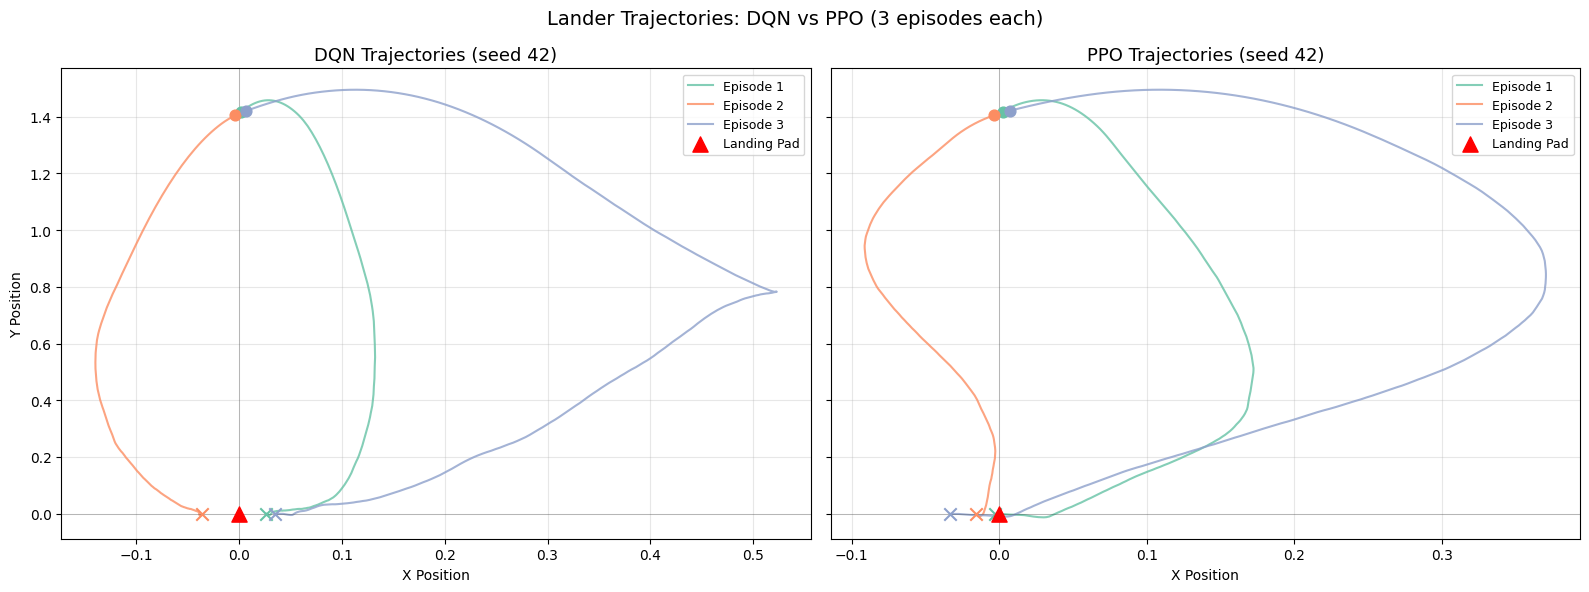

In [42]:
# Trajectory Plots: x-y paths of the lander

fig, axes = plt.subplots(1, len(algo_names), figsize=(8 * len(algo_names), 6), sharey=True)
if len(algo_names) == 1:
    axes = [axes]

traj_colors = list(plt.colormaps["Set2"](range(8)))

for ax, algo_name in zip(axes, algo_names):
    for i, (x_pos, y_pos) in enumerate(trajectory_data[algo_name]):
        ax.plot(x_pos, y_pos, color=traj_colors[i], linewidth=1.5, alpha=0.8,
                label=f"Episode {i+1}")
        ax.scatter(x_pos[0], y_pos[0], color=traj_colors[i], marker='o', s=60, zorder=5)
        ax.scatter(x_pos[-1], y_pos[-1], color=traj_colors[i], marker='x', s=80, zorder=5)

    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.scatter(0, 0, color='red', marker='^', s=120, zorder=10, label='Landing Pad')

    ax.set_title(f"{algo_name.upper()} Trajectories (seed {SEED_LIST[0]})", fontsize=13)
    ax.set_xlabel("X Position")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Y Position")
fig.suptitle(f"Lander Trajectories: DQN vs PPO ({TRAJECTORY_EPISODES} episodes each)", fontsize=14)
plt.tight_layout()
plt.show()

**Figure 27** - Lander trajectories for DQN and PPO (three episodes, seed 42), with landing pad marked in red.

## 15.2 Trajectory Analysis

Figure 27 illustrates representative lander trajectories generated by DQN and PPO over three evaluation episodes (same seed), highlighting qualitative differences in spatial control and descent dynamics. Each curve represents the two-dimensional path followed by the lander from initial descent to touchdown on the landing pad.

Both agents successfully reach the target region, confirming that the learned policies achieve the task objective. However, the geometry of the trajectories reveals distinct control styles.

The DQN trajectories exhibit more pronounced lateral excursions and curved paths, particularly in the horizontal (X) dimension. This indicates a more reactive control strategy, where the agent performs frequent corrective manoeuvres to re-align with the landing pad. Such behaviour is consistent with value-based decision-making, where local action-value differences may lead to sharper directional adjustments. In some episodes, the DQN agent overshoots laterally before correcting its trajectory, resulting in longer and less direct descent paths.

In contrast, PPO trajectories tend to be smoother and more direct, with fewer abrupt changes in direction. The descent paths show a more continuous and stable convergence towards the landing pad, suggesting that the learned policy emphasises gradual corrections and controlled descent. This behaviour aligns with the policy-gradient optimisation of PPO, which typically yields smoother control policies due to clipped updates and entropy-regularised exploration during training.

These qualitative differences complement the quantitative findings reported in Section 11 and the behavioural statistics discussed in Section 14.1. While both agents achieve comparable performance in terms of final reward and success rate, PPO demonstrates more stable and smooth trajectory profiles, whereas DQN relies on more aggressive corrective actions. This reinforces the interpretation that PPO favours smoother control strategies, while DQN adopts a more interventionist and reactive control style.

Overall, trajectory visualisation provides an intuitive perspective on policy behaviour that is not captured by scalar performance metrics alone, highlighting the importance of combining quantitative evaluation with qualitative behavioural analysis in reinforcement learning studies.

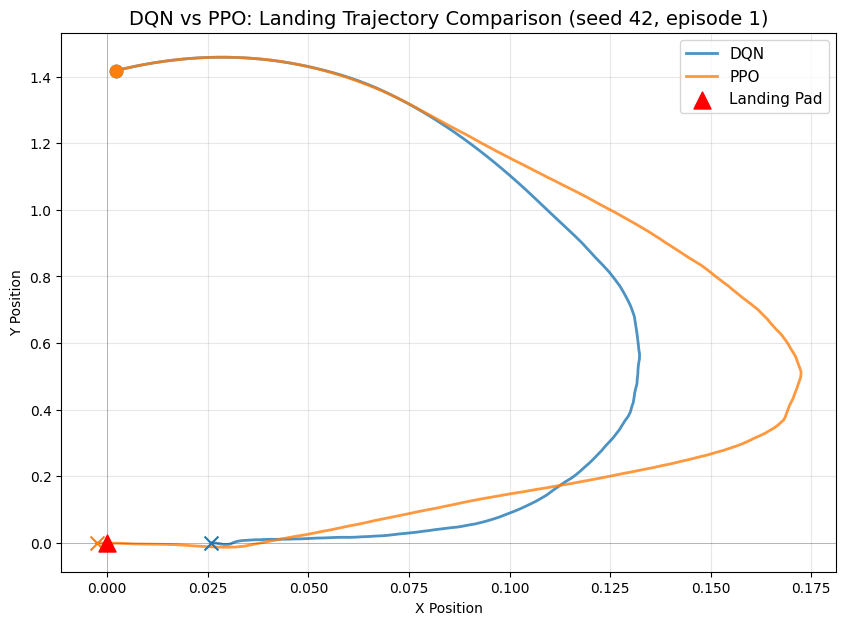

In [43]:
# Trajectory Comparison: DQN vs PPO overlaid on one chart

plt.figure(figsize=(10, 7))

for algo_name in algo_names:
    x_pos, y_pos = trajectory_data[algo_name][0]
    plt.plot(x_pos, y_pos, color=algo_colors[algo_name], linewidth=2, alpha=0.8,
             label=f"{algo_name.upper()}")
    plt.scatter(x_pos[0], y_pos[0], color=algo_colors[algo_name], marker='o', s=80, zorder=5)
    plt.scatter(x_pos[-1], y_pos[-1], color=algo_colors[algo_name], marker='x', s=100, zorder=5)

plt.scatter(0, 0, color='red', marker='^', s=150, zorder=10, label='Landing Pad')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)

plt.title(f"DQN vs PPO: Landing Trajectory Comparison (seed {SEED_LIST[0]}, episode 1)", fontsize=14)
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

**Figure 28** - Landing trajectories for DQN and PPO (seed 42), with landing pad marked in red.

## 15.3 Direct Trajectory Comparison

Figure 28 presents a direct comparison between DQN and PPO trajectories for the same initial condition (seed 42, episode 1). By overlaying both paths in the same coordinate space, it becomes possible to isolate behavioural differences that are otherwise masked when analysing multiple episodes independently.

Although both agents start from identical initial conditions and reach the landing pad successfully, their control strategies differ visibly. The DQN trajectory exhibits a sharper curvature during the final descent phase, with a more abrupt lateral correction close to the ground. This behaviour reflects a more reactive control pattern, where the agent compensates for positional drift using stronger corrective actions near touchdown.

In contrast, the PPO trajectory shows a smoother and more progressive descent path. The lateral deviation is corrected earlier and more gradually, resulting in a wider but more continuous arc towards the landing pad. This suggests that PPO learns a policy that anticipates the need for alignment earlier in the descent, reducing the magnitude of last-moment corrections.

This single-episode comparison reinforces the qualitative trends observed in the multi-trajectory analysis. While both algorithms achieve comparable final performance in terms of reward and success rate, PPO demonstrates smoother spatial control, whereas DQN tends to concentrate corrective actions closer to the terminal phase of the landing manoeuvre.

Such qualitative differences are relevant from a control and safety perspective, as smoother trajectories are typically associated with lower control effort and reduced risk of instability in real-world deployment scenarios.

# 16. Sample Efficiency Analysis

Sample efficiency refers to how quickly an agent improves its performance as a function of the number of interactions with the environment. In reinforcement learning settings, this criterion is particularly relevant, as environment steps are often expensive in real-world applications. In this section, the learning efficiency of DQN and PPO is compared in terms of reward accumulation and success rate as training progresses.


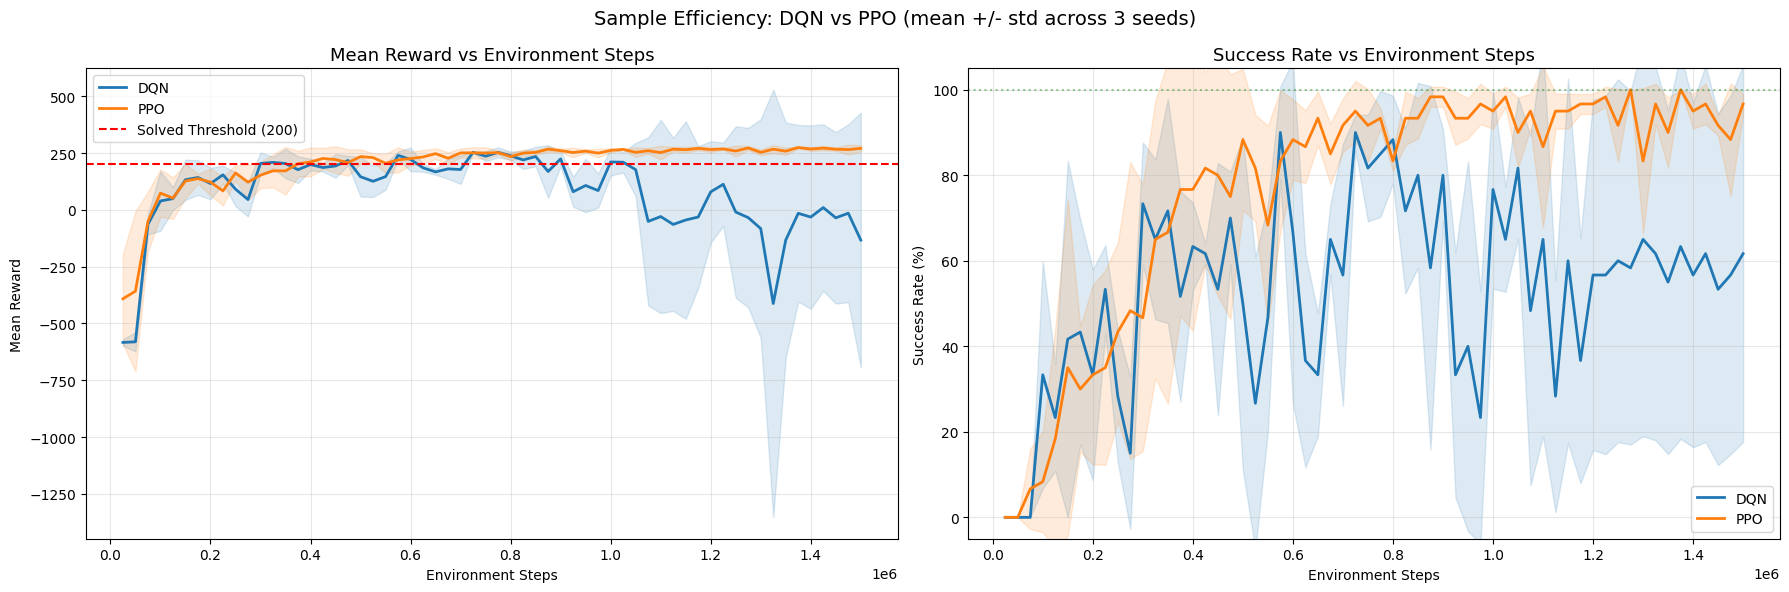

In [44]:
# Sample Efficiency: Mean Reward and Success Rate vs Training Timesteps
# Extracted from the EvalCallback logs (evaluations.npz)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for algo_name in algo_names:
    all_timesteps = None
    all_mean_rewards = []
    all_success_rates = []

    for seed in SEED_LIST:
        log_path = eval_log_paths.get(algo_name, {}).get(seed)
        if log_path is None:
            continue

        data = np.load(log_path, allow_pickle=True)
        timesteps = data["timesteps"]
        results = data["results"]

        mean_rewards = np.array([np.mean(r) for r in results])
        success_rates = np.array([np.sum(r >= 200) / len(r) * 100 for r in results])

        if all_timesteps is None:
            all_timesteps = timesteps
        all_mean_rewards.append(mean_rewards[:len(all_timesteps)])
        all_success_rates.append(success_rates[:len(all_timesteps)])

    if all_timesteps is None or not all_mean_rewards:
        continue

    # Align to shortest
    min_len = min(len(a) for a in all_mean_rewards)
    all_timesteps = all_timesteps[:min_len]
    all_mean_rewards = np.array([a[:min_len] for a in all_mean_rewards])
    all_success_rates = np.array([a[:min_len] for a in all_success_rates])

    mean_r = all_mean_rewards.mean(axis=0)
    std_r = all_mean_rewards.std(axis=0)
    mean_s = all_success_rates.mean(axis=0)
    std_s = all_success_rates.std(axis=0)

    ax1.plot(all_timesteps, mean_r, color=algo_colors[algo_name], linewidth=2, label=algo_name.upper())
    ax1.fill_between(all_timesteps, mean_r - std_r, mean_r + std_r, color=algo_colors[algo_name], alpha=0.15)

    ax2.plot(all_timesteps, mean_s, color=algo_colors[algo_name], linewidth=2, label=algo_name.upper())
    ax2.fill_between(all_timesteps, mean_s - std_s, mean_s + std_s, color=algo_colors[algo_name], alpha=0.15)

ax1.axhline(y=200, color='red', linestyle='--', label='Solved Threshold (200)')
ax1.set_title("Mean Reward vs Environment Steps", fontsize=13)
ax1.set_xlabel("Environment Steps")
ax1.set_ylabel("Mean Reward")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.axhline(y=100, color='green', linestyle=':', alpha=0.4)
ax2.set_title("Success Rate vs Environment Steps", fontsize=13)
ax2.set_xlabel("Environment Steps")
ax2.set_ylabel("Success Rate (%)")
ax2.set_ylim(-5, 105)
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle(f"Sample Efficiency: DQN vs PPO (mean +/- std across {len(SEED_LIST)} seeds)", fontsize=14)
plt.tight_layout()
plt.show()

**Figure 29** - Sample efficiency of DQN vs PPO in terms of mean reward and success rate across environment steps.

## 16.1 Mean Reward and Success Rate vs Environment Steps

Figure 29 reports the evolution of the mean episodic reward and the success rate as a function of the total number of environment steps, averaged across three independent random seeds (mean ± standard deviation). The solved threshold (average reward ≥ 200) is indicated as a reference level.

PPO demonstrates substantially higher sample efficiency than DQN. In the early training phase, PPO reaches the solved threshold with fewer environment interactions, showing a steeper initial improvement in both reward and success rate. The success rate curve for PPO rises more smoothly and stabilizes near 100% at earlier stages of training, indicating faster convergence to a consistently successful policy.

In contrast, DQN exhibits slower initial learning and significantly higher variability across seeds, as reflected by the wider confidence bands. Although DQN temporarily reaches high reward and success levels, its performance is less stable, with noticeable drops in both metrics at later stages of training. This behaviour suggests that, while DQN can achieve strong performance, it requires more environment interactions and is more sensitive to training instability.

Overall, these results indicate that PPO is more sample-efficient and robust in the LunarLander environment, achieving reliable performance with fewer environment steps and exhibiting more stable learning dynamics across random initializations.

In [45]:
# Sample Efficiency: Timestep at which each algorithm first crossed the solved threshold
# per seed and on average

solved_threshold = 200

rows = []
for algo_name in algo_names:
    first_solved_steps = []

    for seed in SEED_LIST:
        log_path = eval_log_paths.get(algo_name, {}).get(seed)
        if log_path is None:
            first_solved_steps.append(None)
            continue

        data = np.load(log_path, allow_pickle=True)
        timesteps = data["timesteps"]
        results = data["results"]

        found = False
        for i, r in enumerate(results):
            if np.mean(r) >= solved_threshold:
                first_solved_steps.append(int(timesteps[i]))
                rows.append({
                    "Algorithm": algo_name.upper(),
                    "Seed": seed,
                    "First Solved at Step": f"{int(timesteps[i]):,}",
                })
                found = True
                break

        if not found:
            first_solved_steps.append(None)
            rows.append({
                "Algorithm": algo_name.upper(),
                "Seed": seed,
                "First Solved at Step": "Not reached",
            })

    valid = [s for s in first_solved_steps if s is not None]
    if valid:
        rows.append({
            "Algorithm": algo_name.upper(),
            "Seed": "Mean",
            "First Solved at Step": f"{int(np.mean(valid)):,}",
        })

print("*** SAMPLE EFFICIENCY: FIRST SOLVED TIMESTEP ***")
print(f"Solved = mean evaluation reward >= {solved_threshold}")
print(f"Evaluated every {25_000:,} timesteps with {20} episodes")
print()
print(pd.DataFrame(rows).to_string(index=False))

*** SAMPLE EFFICIENCY: FIRST SOLVED TIMESTEP ***
Solved = mean evaluation reward >= 200
Evaluated every 25,000 timesteps with 20 episodes

Algorithm Seed First Solved at Step
      DQN   42              300,000
      DQN  123              300,000
      DQN 3407              150,000
      DQN Mean              250,000
      PPO   42              150,000
      PPO  123              525,000
      PPO 3407              325,000
      PPO Mean              333,333


 | Algorithm | Seed  | First Solved Step |
|-----------|-------|-------------------|
| DQN       | 42    | 300,000           |
| DQN       | 123   | 300,000           |
| DQN       | 3407  | 150,000           |
| **DQN (Mean)** | — | **250,000**       |
| PPO       | 42    | 150,000           |
| PPO       | 123   | 525,000           |
| PPO       | 3407  | 325,000           |
| **PPO (Mean)** | — | **333,333**       |

**Table 12** – First timestep at which the solved threshold was reached (mean evaluation reward ≥ 200)

# 17. Training Milestone Timeline

This chart overlays the training reward curves with vertical milestone markers showing when each algorithm reached key performance thresholds. The background curves show the rolling mean reward (window=100 episodes) plotted against cumulative environment steps, reconstructed from the per-episode training logs. Three milestones are marked per algorithm:

* Best model (solid line): the checkpoint selected by the combined metric (mean - std) during training
* First solved (dashed line): first point where the rolling 100-episode mean reward >= 200
* First all-pass (dotted line): first point where all 100 consecutive episodes scored >= 200

Discovered training logs:
  DQN seed 42: /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_02_53_32/training_log.npz
  DQN seed 123: /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_03_41_09/training_log.npz
  DQN seed 3407: /home/logus/env/iscte/taap_p2/report/../models/dqn/2026-02-23_04_28_07/training_log.npz
  PPO seed 42: /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_15_27/training_log.npz
  PPO seed 123: /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_35_37/training_log.npz
  PPO seed 3407: /home/logus/env/iscte/taap_p2/report/../models/ppo/2026-02-23_05_58_38/training_log.npz


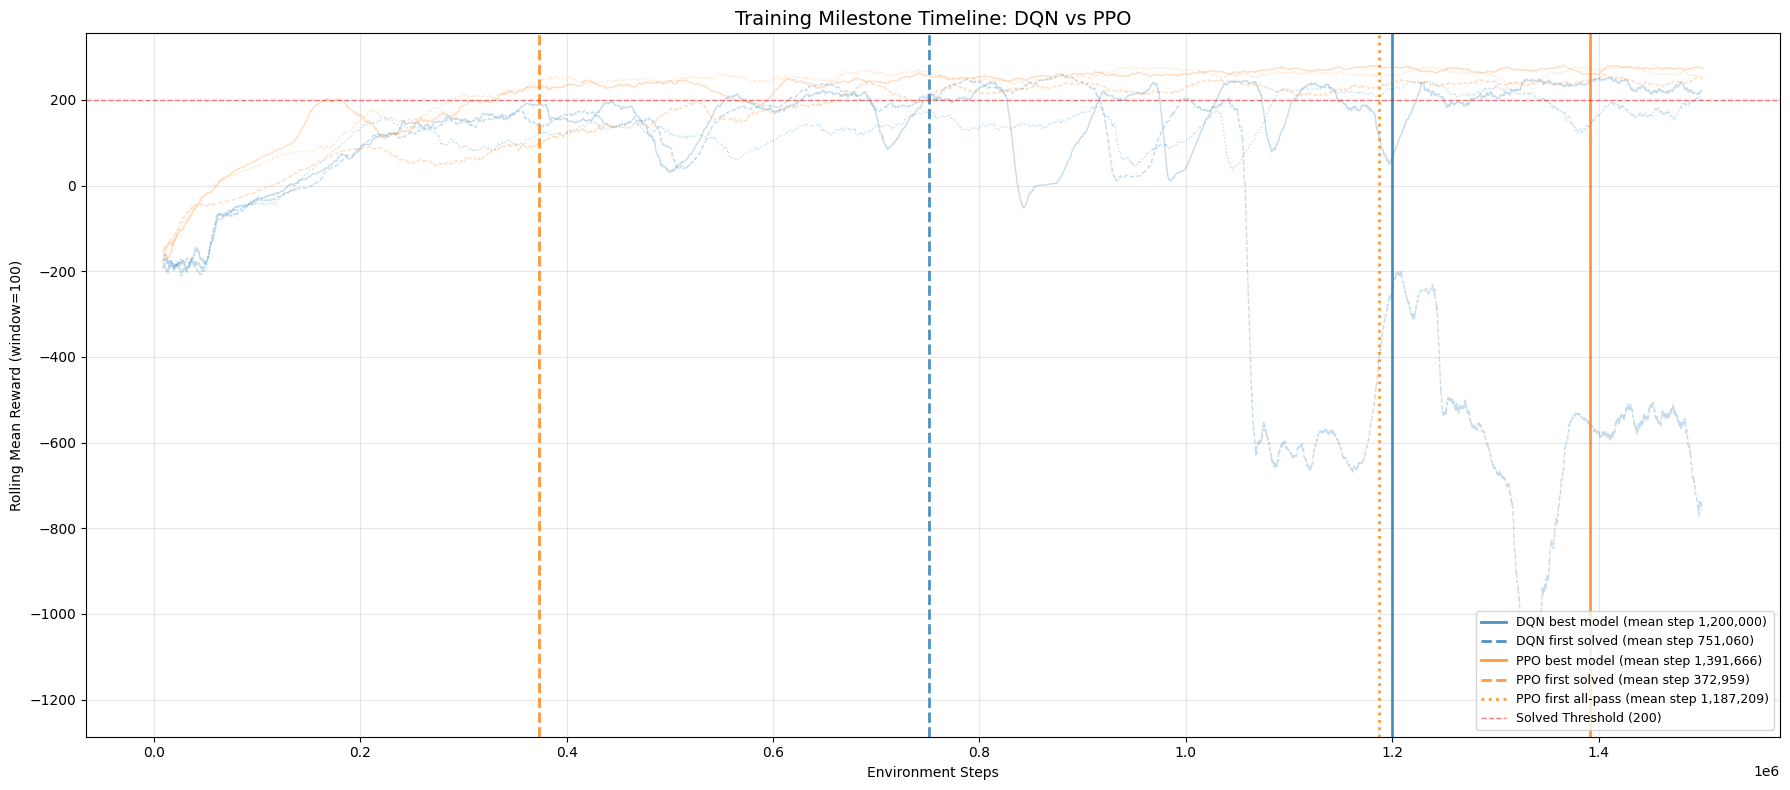

In [ ]:
# Training Milestone Timeline
# Uses: training_log.npz (episode_rewards, episode_lengths) per run
#       evaluations.npz (timesteps, results) per run

def discover_training_logs(session_prefix):
    """
    Scan models/{algo}/{timestamp}/training_log.npz and return a dict:
        {algo: {seed: path_to_training_log}}
    """
    models_root = os.path.join(NOTEBOOK_DIR, "../models")
    logs = {}

    for algo_name in ALGORITHM_MAP:
        logs[algo_name] = {}
        algo_dir = os.path.join(models_root, algo_name)
        if not os.path.isdir(algo_dir):
            continue

        for run_folder in sorted(glob.glob(os.path.join(algo_dir, "????-??-??_??_??_??"))):
            log_path = os.path.join(run_folder, "training_log.npz")
            if not os.path.isfile(log_path):
                continue

            for f in os.listdir(run_folder):
                if f.startswith(session_prefix) and f.endswith(".zip") and f != "best_model.zip":
                    seed_str = f.replace(".zip", "").split("_")[-1]
                    if seed_str.isdigit():
                        seed_int = int(seed_str)
                        if seed_int in SEED_LIST:
                            logs[algo_name][seed_int] = log_path
                    break

    return logs


training_log_paths = discover_training_logs(SESSION_PREFIX)

print("Discovered training logs:")
for algo_name in ALGORITHM_MAP:
    for seed in SEED_LIST:
        path = training_log_paths.get(algo_name, {}).get(seed)
        status = path if path else "NOT FOUND"
        print(f"  {algo_name.upper()} seed {seed}: {status}")

# --- Compute milestones and build chart ---

ROLLING_WINDOW = 100
SOLVED_THRESHOLD = 200

fig, ax = plt.subplots(figsize=(18, 8))

# Lighter per-seed colors
seed_alpha = 0.25
seed_line_styles = ['-', '--', ':']

milestone_summary = []  # for the summary table

for algo_name in algo_names:
    color = algo_colors[algo_name]

    for si, seed in enumerate(SEED_LIST):
        log_path = training_log_paths.get(algo_name, {}).get(seed)
        if log_path is None:
            continue

        data = np.load(log_path)
        ep_rewards = data['episode_rewards']
        ep_lengths = data['episode_lengths']

        # Cumulative environment steps at end of each episode
        cum_steps = np.cumsum(ep_lengths)

        # Rolling mean reward (window=100)
        rolling_mean = pd.Series(ep_rewards).rolling(ROLLING_WINDOW).mean().values

        # Plot per-seed curve (light)
        ax.plot(cum_steps, rolling_mean, color=color, alpha=seed_alpha,
                linestyle=seed_line_styles[si], linewidth=1)

        # --- Milestone: first rolling mean >= 200 ---
        first_solved_step = None
        for j in range(ROLLING_WINDOW, len(ep_rewards)):
            if rolling_mean[j] >= SOLVED_THRESHOLD:
                first_solved_step = int(cum_steps[j])
                break

        # --- Milestone: first 100 consecutive all >= 200 ---
        first_allpass_step = None
        for j in range(ROLLING_WINDOW, len(ep_rewards)):
            window = ep_rewards[j - ROLLING_WINDOW + 1 : j + 1]
            if np.all(window >= SOLVED_THRESHOLD):
                first_allpass_step = int(cum_steps[j])
                break

        milestone_summary.append({
            'Algorithm': algo_name.upper(),
            'Seed': seed,
            'First Solved (rolling mean >= 200)': f'{first_solved_step:,}' if first_solved_step else 'Not reached',
            'First All-Pass (all 100 >= 200)': f'{first_allpass_step:,}' if first_allpass_step else 'Not reached',
        })

    # --- Best model milestone (from evaluations.npz, averaged across seeds) ---
    best_steps = []
    for seed in SEED_LIST:
        eval_path = eval_log_paths.get(algo_name, {}).get(seed)
        if eval_path is None:
            continue
        edata = np.load(eval_path, allow_pickle=True)
        timesteps = edata['timesteps']
        results = edata['results']
        best_score = -np.inf
        best_step = 0
        for k in range(len(timesteps)):
            score = np.mean(results[k]) - np.std(results[k])
            if score > best_score:
                best_score = score
                best_step = int(timesteps[k])
        best_steps.append(best_step)

    # --- Draw aggregate milestone lines ---
    # Collect per-seed first-solved steps for this algorithm
    algo_milestones = [m for m in milestone_summary if m['Algorithm'] == algo_name.upper()]

    solved_steps = []
    allpass_steps = []
    for m in algo_milestones:
        v = m['First Solved (rolling mean >= 200)']
        if v != 'Not reached':
            solved_steps.append(int(v.replace(',', '')))
        v = m['First All-Pass (all 100 >= 200)']
        if v != 'Not reached':
            allpass_steps.append(int(v.replace(',', '')))

    label_prefix = algo_name.upper()

    if best_steps:
        mean_best = int(np.mean(best_steps))
        ax.axvline(x=mean_best, color=color, linestyle='-', linewidth=2, alpha=0.8,
                   label=f'{label_prefix} best model (mean step {mean_best:,})')

    if solved_steps:
        mean_solved = int(np.mean(solved_steps))
        ax.axvline(x=mean_solved, color=color, linestyle='--', linewidth=2, alpha=0.8,
                   label=f'{label_prefix} first solved (mean step {mean_solved:,})')

    if allpass_steps:
        mean_allpass = int(np.mean(allpass_steps))
        ax.axvline(x=mean_allpass, color=color, linestyle=':', linewidth=2, alpha=0.8,
                   label=f'{label_prefix} first all-pass (mean step {mean_allpass:,})')

# Solved threshold line
ax.axhline(y=SOLVED_THRESHOLD, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Solved Threshold (200)')

ax.set_title('Training Milestone Timeline: DQN vs PPO', fontsize=14)
ax.set_xlabel('Environment Steps')
ax.set_ylabel('Rolling Mean Reward (window=100)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 30** - Training milestone timeline showing rolling mean reward curves (per-seed, light lines) with vertical markers for best model selection, first solved (rolling 100-episode mean >= 200), and first all-pass (all 100 consecutive episodes >= 200) milestones.

In [49]:
# Milestone Summary Table

print('*** TRAINING MILESTONES PER SEED ***')
print(f'Rolling window: {ROLLING_WINDOW} episodes')
print(f'Solved threshold: mean reward >= {SOLVED_THRESHOLD}')
print(f'All-pass threshold: every episode in window >= {SOLVED_THRESHOLD}')
print()
print(pd.DataFrame(milestone_summary).to_string(index=False))

*** TRAINING MILESTONES PER SEED ***
Rolling window: 100 episodes
Solved threshold: mean reward >= 200
All-pass threshold: every episode in window >= 200

Algorithm  Seed First Solved (rolling mean >= 200) First All-Pass (all 100 >= 200)
      DQN    42                            553,533                     Not reached
      DQN   123                            614,569                     Not reached
      DQN  3407                          1,085,079                     Not reached
      PPO    42                            166,110                       1,407,532
      PPO   123                            662,791                     Not reached
      PPO  3407                            289,977                         966,886


#  18. Final vs Best Model Comparison

In [50]:
# Evaluate final models (end-of-training) and compare against best models

final_evaluation_results = {}

for algo_name, algo_class in ALGORITHM_MAP.items():
    final_evaluation_results[algo_name] = {}

    for seed in SEED_LIST:
        load_path = final_model_paths.get(algo_name, {}).get(seed)
        if load_path is None:
            print(f"SKIPPING {algo_name.upper()} seed {seed} - final model not found")
            continue

        print(f"Evaluating {algo_name.upper()} seed {seed} (final model)...")

        def make_env(s=seed):
            env = gym.make(GYMNASIUM_MODEL, render_mode="rgb_array", enable_wind=WIND_ENABLED)
            env.reset(seed=s)
            return env

        model = algo_class.load(load_path, env=DummyVecEnv([make_env]), device=DEVICE)

        eval_env = Monitor(gym.make(GYMNASIUM_MODEL, enable_wind=WIND_ENABLED))
        eval_env.reset(seed=seed)

        rewards, _ = evaluate_policy(
            model, eval_env,
            n_eval_episodes=EVALUATION_EPISODES,
            deterministic=True,
            return_episode_rewards=True
        )
        final_evaluation_results[algo_name][seed] = np.array(rewards)
        eval_env.close()

print("\nFinal model evaluation complete.")

Evaluating DQN seed 42 (final model)...
Evaluating DQN seed 123 (final model)...
Evaluating DQN seed 3407 (final model)...
Evaluating PPO seed 42 (final model)...
Evaluating PPO seed 123 (final model)...
Evaluating PPO seed 3407 (final model)...

Final model evaluation complete.


In [51]:
# Final vs Best Model Comparison Table

rows = []
for algo_name in algo_names:
    for seed in SEED_LIST:
        best_r = evaluation_results.get(algo_name, {}).get(seed)
        final_r = final_evaluation_results.get(algo_name, {}).get(seed)

        if best_r is None or final_r is None:
            continue

        rows.append({
            "Algorithm": algo_name.upper(),
            "Seed": seed,
            "Best Mean": f"{np.mean(best_r):.2f}",
            "Best Success": f"{(best_r >= 200).sum() / len(best_r) * 100:.0f}%",
            "Final Mean": f"{np.mean(final_r):.2f}",
            "Final Success": f"{(final_r >= 200).sum() / len(final_r) * 100:.0f}%",
            "Delta Mean": f"{np.mean(best_r) - np.mean(final_r):+.2f}",
        })

print("*** BEST MODEL vs FINAL MODEL ***")
print(f"Episodes per evaluation: {EVALUATION_EPISODES}")
print()
print(pd.DataFrame(rows).to_string(index=False))
print()
print("Positive Delta Mean = best model selection improved over end-of-training snapshot.")

*** BEST MODEL vs FINAL MODEL ***
Episodes per evaluation: 20

Algorithm  Seed Best Mean Best Success Final Mean Final Success Delta Mean
      DQN    42    278.51         100%     266.82           95%     +11.69
      DQN   123    283.34         100%    -935.49            0%   +1218.83
      DQN  3407    261.22         100%     286.92          100%     -25.70
      PPO    42    278.43         100%     276.39           95%      +2.04
      PPO   123    270.83         100%     247.72           85%     +23.11
      PPO  3407    279.56         100%     267.67           95%     +11.88

Positive Delta Mean = best model selection improved over end-of-training snapshot.


| Algorithm | Seed | Best Mean | Best Success | Final Mean | Final Success | Delta Mean |
|------------|------|-----------|--------------|------------|--------------|------------|
| DQN | 42 | 278.51 | 100% | 266.82 | 95% | +11.69 |
| DQN | 123 | 283.34 | 100% | -935.49 | 0% | +1218.83 |
| DQN | 3407 | 261.22 | 100% | 286.92 | 100% | -25.70 |
| PPO | 42 | 278.43 | 100% | 276.39 | 95% | +2.04 |
| PPO | 123 | 270.83 | 100% | 247.72 | 85% | +23.11 |
| PPO | 3407 | 279.56 | 100% | 267.67 | 95% | +11.88 |

**Table 13** - Best model vs final model (20 episodes per evaluation)

> Positive Delta Mean = best model selection improved over end-of-training snapshot.

# 19. Hyperparameter Exploration Summary

In [52]:
# Hyperparameter Tables: Final Configuration

for algo_name in ALGORITHM_MAP:
    params = ALGO_PARAMS[algo_name]
    rows = [{"Parameter": k, "Value": str(v)} for k, v in params.items()]
    rows.append({"Parameter": "total_timesteps", "Value": f"{TOTAL_TIMESTEPS:,}"})
    rows.append({"Parameter": "device", "Value": DEVICE})
    rows.append({"Parameter": "policy", "Value": "MlpPolicy"})

    print(f"*** {algo_name.upper()} Final Hyperparameters ***")
    print(pd.DataFrame(rows).to_string(index=False))
    print()

*** DQN Final Hyperparameters ***
             Parameter                                                      Value
                policy                                                  MlpPolicy
         learning_rate <function linear_schedule.<locals>.func at 0x75da6d15cc20>
       learning_starts                                                      50000
           buffer_size                                                     750000
            batch_size                                                        128
                 gamma                                                       0.99
  exploration_fraction                                                       0.12
 exploration_final_eps                                                        0.1
target_update_interval                                                        250
            train_freq                                                          4
        gradient_steps                                          

| Parameter               | Value                      |
|-------------------------|----------------------------|
| policy                  | MlpPolicy                  |
| learning_rate           | linear_schedule(...)       |
| learning_starts         | 50,000                     |
| buffer_size             | 750,000                    |
| batch_size              | 128                        |
| gamma                   | 0.99                       |
| exploration_fraction    | 0.12                       |
| exploration_final_eps   | 0.1                        |
| target_update_interval  | 250                        |
| train_freq              | 4                          |
| gradient_steps          | 4                          |
| policy_kwargs           | `{'net_arch': [256, 256]}` |
| total_timesteps         | 1,500,000                  |
| device                  | cpu                        |

**Table 14** – DQN Final Hyperparameters




| Parameter       | Value     |
|-----------------|-----------|
| policy          | MlpPolicy |
| learning_rate   | 0.00025   |
| n_steps         | 2048      |
| batch_size      | 64        |
| n_epochs        | 10        |
| gamma           | 0.999     |
| gae_lambda      | 0.95      |
| ent_coef        | 0.01      |
| clip_range      | 0.2       |
| total_timesteps | 1,500,000 |
| device          | cpu       |

**Table 15** – PPO Final Hyperparameters

In [53]:
# Hyperparameter Exploration Journey
# Summary of configurations tested across lab sessions and their results.
# Fill in the actual results from your earlier experiments (lab004, lab009, etc.)

print("*** DQN HYPERPARAMETER EXPLORATION ***")
print()

dqn_configs = [
    {
        "Config": "A (baseline)",
        "Key Changes": "lr=6.3e-4, buffer=100k, eps_final=0.01, explore=0.5, soft updates (tau=0.005)",
        "Success Rate": "84.0%",
        "Mean Reward": "245.47",
        "Notes": "Slow exploration decay, soft target updates",
    },
    {
        "Config": "B (Zoo-style)",
        "Key Changes": "lr=linear(6.3e-4), buffer=1M, eps_final=0.1, explore=0.12, hard updates (250)",
        "Success Rate": "96.0%",
        "Mean Reward": "263.02",
        "Notes": "Short exploration, high final epsilon, hard target updates",
    },
    {
        "Config": "C (final)",
        "Key Changes": "lr=linear(6.3e-4), buffer=750k, eps_final=0.1, explore=0.12, hard updates (250), learning_starts=50k",
        "Success Rate": "TBD (lab011)",
        "Mean Reward": "TBD (lab011)",
        "Notes": "Added learning_starts buffer fill, gradient_steps=4 explicit",
    },
]
print(pd.DataFrame(dqn_configs).to_string(index=False))

print()
print("*** PPO HYPERPARAMETER EXPLORATION ***")
print()

ppo_configs = [
    {
        "Config": "A (final)",
        "Key Changes": "lr=2.5e-4, gamma=0.999, n_steps=2048, batch=64, n_epochs=10, ent_coef=0.01",
        "Success Rate": "98.0%",
        "Mean Reward": "269.21",
        "Notes": "Standard config, single environment",
    },
]
print(pd.DataFrame(ppo_configs).to_string(index=False))
print()
print("Note: Update Config C results and add any additional configs tested during lab011 runs.")

*** DQN HYPERPARAMETER EXPLORATION ***

       Config                                                                                          Key Changes Success Rate  Mean Reward                                                        Notes
 A (baseline)                        lr=6.3e-4, buffer=100k, eps_final=0.01, explore=0.5, soft updates (tau=0.005)        84.0%       245.47                  Slow exploration decay, soft target updates
B (Zoo-style)                        lr=linear(6.3e-4), buffer=1M, eps_final=0.1, explore=0.12, hard updates (250)        96.0%       263.02   Short exploration, high final epsilon, hard target updates
    C (final) lr=linear(6.3e-4), buffer=750k, eps_final=0.1, explore=0.12, hard updates (250), learning_starts=50k TBD (lab011) TBD (lab011) Added learning_starts buffer fill, gradient_steps=4 explicit

*** PPO HYPERPARAMETER EXPLORATION ***

   Config                                                                Key Changes Success Rate Mean Reward  

# 20. Future Works

Several extensions can be pursued to deepen and broaden the scope of this study:

* Stability-Enhanced Value-Based Methods: extend the comparison by including improved variants of DQN, such as Double DQN, Dueling DQN, and Prioritized Experience Replay. These methods explicitly address overestimation bias and sample inefficiency, and would allow a more nuanced assessment of whether the observed instabilities of vanilla DQN persist when modern stabilization techniques are applied.

* Comprehensive Hyperparameter Sensitivity Analysis: perform systematic hyperparameter sweeps for both DQN and PPO (e.g., learning rate, network depth and width, target network update frequency, clipping range, entropy coefficient). This would clarify how sensitive each algorithm is to configuration choices and whether PPO’s apparent robustness is preserved under less carefully tuned settings.

* Cross-Environment Generalization: replicate the experimental protocol across environments with different dynamics and reward structures, including continuous-control benchmarks (e.g., BipedalWalker, MuJoCo tasks) and sparse-reward settings. This would test the external validity of the conclusions and assess whether PPO’s stability advantage generalizes beyond LunarLander.

* Scalability and Compute-Efficiency Trade-offs: analyze wall-clock training time, computational cost, and energy consumption across algorithms and hardware configurations (CPU vs GPU). Such analysis is critical for understanding practical deployment trade-offs, especially in resource-constrained or real-time learning scenarios.

* Robustness Under Distribution Shift and Noise: introduce controlled perturbations to the environment (e.g., sensor noise, altered gravity, reward shaping changes) to evaluate the robustness and adaptability of learned policies. This would provide insights into the resilience of value-based versus policy-gradient methods under non-stationary conditions.

* Long-Horizon and Safety-Constrained Settings: extend the evaluation to tasks with longer horizons and safety constraints, incorporating risk-sensitive or constrained RL formulations. This would help assess whether PPO’s stable update mechanism translates into safer learning dynamics compared to DQN in safety-critical domains.

* Representation Learning and Architectural Choices: investigate the impact of alternative network architectures (e.g., deeper networks, residual connections, shared encoders) and auxiliary objectives on learning stability and sample efficiency. Jointly learning state representations may reduce variance and improve convergence properties for both algorithm families.

These directions would contribute to a more comprehensive understanding of the robustness, scalability, and practical applicability of value-based and policy-gradient reinforcement learning methods in diverse real-world settings.

# 21. Conclusions

This work presented a systematic empirical comparison between Deep Q-Networks (DQN) and Proximal Policy Optimization (PPO) on the LunarLander-v3 environment, evaluated across multiple random seeds and using a comprehensive set of training and evaluation metrics. Both algorithms were able to solve the task reliably, achieving high mean returns and 100% success rates under deterministic evaluation. These results confirm that, under appropriate configurations, both value-based and policy-gradient methods can learn effective control policies for this benchmark.

Despite comparable final performance, the learning dynamics of the two approaches differed substantially. DQN exhibited pronounced sensitivity to random initialization and training stochasticity, with episodes of instability, late-stage performance collapse in some runs, and evidence of Q-value overestimation. These behaviors highlight the inherent challenges of bootstrapped value estimation and off-policy learning, where divergence can occur even after the task is apparently solved. In contrast, PPO demonstrated smoother and more monotonic learning curves, bounded loss dynamics, and more consistent success rates across seeds, reflecting the stabilizing effect of clipped policy updates and on-policy optimization.

From a practical perspective, PPO showed superior robustness and training stability, as well as more predictable convergence behavior. Although DQN occasionally matched or slightly exceeded PPO in peak performance for specific seeds, this came at the cost of higher variance and reduced reliability over the course of training. The statistical analysis further indicated that the small differences in final average performance between DQN and PPO were not significant, reinforcing the interpretation that stability and robustness—rather than raw peak return—constitute the main differentiating factors between the two methods in this setting.

Generally, the results suggest that PPO is a more dependable choice for practitioners when stability, reproducibility, and consistent convergence are critical requirements. DQN remains competitive in terms of achievable performance but demands careful monitoring, checkpoint selection, and additional stabilization mechanisms to mitigate training instabilities. This comparative analysis underscores the importance of evaluating reinforcement learning algorithms not only by their final scores, but also by their learning dynamics, robustness across seeds, and practical reliability in realistic experimental pipelines.

# 22. Lunar Lander Visualizations

Generating GIF for DQN seed 42 (best model)...
  Saved: /home/logus/env/iscte/taap_p2/report/outputs_dqn/dqn_seed42.gif


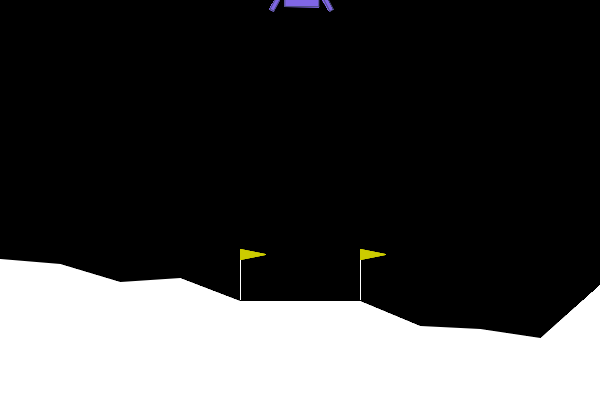

Generating GIF for DQN seed 123 (best model)...
  Saved: /home/logus/env/iscte/taap_p2/report/outputs_dqn/dqn_seed123.gif


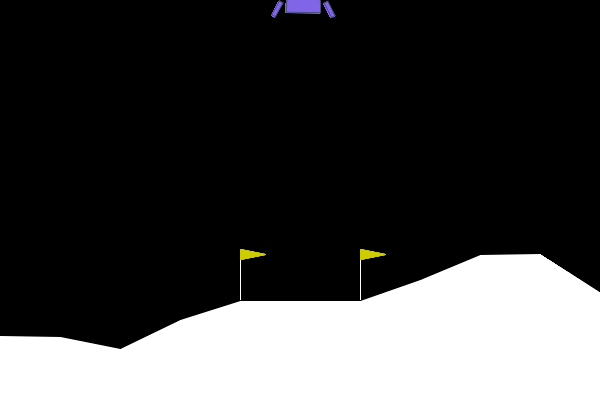

Generating GIF for DQN seed 3407 (best model)...
  Saved: /home/logus/env/iscte/taap_p2/report/outputs_dqn/dqn_seed3407.gif


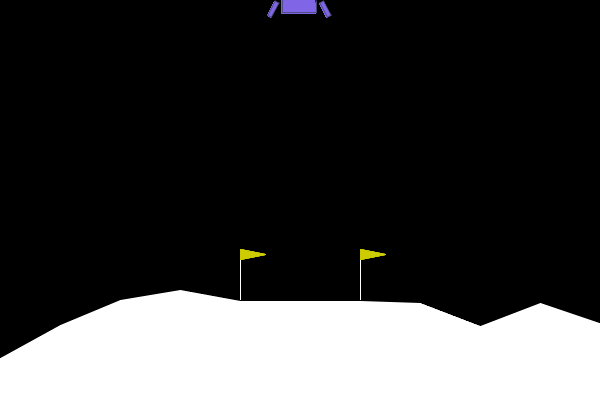

Generating GIF for PPO seed 42 (best model)...
  Saved: /home/logus/env/iscte/taap_p2/report/outputs_ppo/ppo_seed42.gif


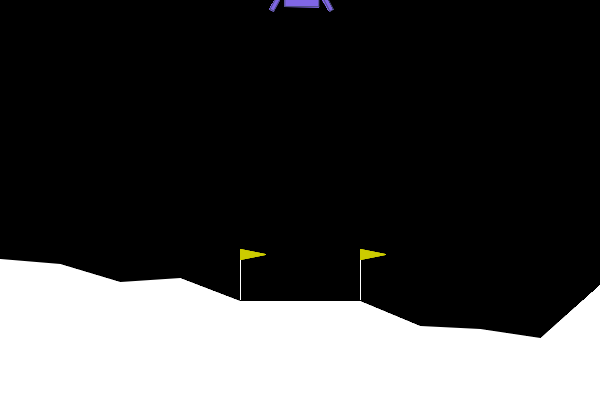

Generating GIF for PPO seed 123 (best model)...
  Saved: /home/logus/env/iscte/taap_p2/report/outputs_ppo/ppo_seed123.gif


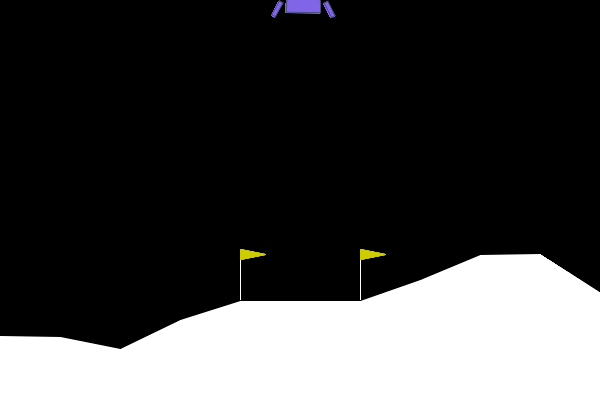

Generating GIF for PPO seed 3407 (best model)...
  Saved: /home/logus/env/iscte/taap_p2/report/outputs_ppo/ppo_seed3407.gif


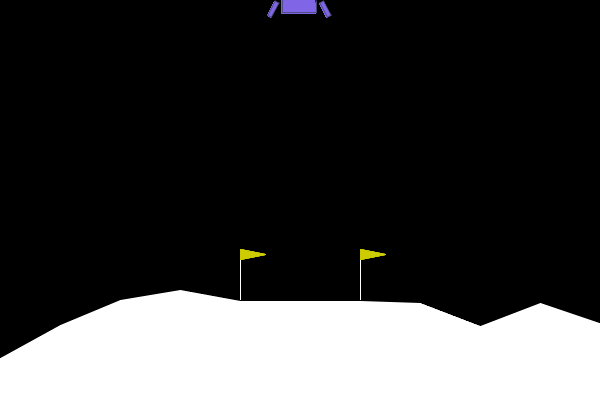

In [54]:
# GIF Visualizations (one per algorithm per seed, best model)

for algo_name, algo_class in ALGORITHM_MAP.items():
    output_dir = os.path.join(NOTEBOOK_DIR, "outputs_" + algo_name)
    os.makedirs(output_dir, exist_ok=True)

    for seed in SEED_LIST:
        load_path = best_model_paths.get(algo_name, {}).get(seed)
        if load_path is None:
            print(f"SKIPPING GIF for {algo_name.upper()} seed {seed} - best model not found")
            continue

        print(f"Generating GIF for {algo_name.upper()} seed {seed} (best model)...")

        def make_vis_env(s=seed):
            env = gym.make(GYMNASIUM_MODEL, render_mode="rgb_array", enable_wind=WIND_ENABLED)
            env.reset(seed=s)
            return env

        vis_model = algo_class.load(load_path, env=DummyVecEnv([make_vis_env]), device=DEVICE)

        vis_env = gym.make(GYMNASIUM_MODEL, render_mode="rgb_array", enable_wind=WIND_ENABLED)
        frames = []
        obs, info = vis_env.reset(seed=seed)
        done = False

        while not done:
            action, _ = vis_model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = vis_env.step(action)
            done = terminated or truncated
            frames.append(vis_env.render())

        vis_env.close()

        gif_path = os.path.join(output_dir, f"{algo_name}_seed{seed}.gif")
        imageio.mimsave(gif_path, frames, fps=30)
        print(f"  Saved: {gif_path}")
        display(Image(filename=gif_path))

# References

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.  
  https://web.stanford.edu/class/psych209/Readings/SuttonBartoIPRLBook2ndEd.pdf

- Audenis, J. (n.d.). *Neuroevolution Lunar Lander* (GitHub repository).  
  https://github.com/josep-audenis/neuroevolution-lunar-lander

- Audenis, J. (n.d.). *Neuroevolution for LunarLander – Project Portfolio*.  
  https://josep-audenis.github.io/portfolio/neuroevolutions/

- Gymnasium (Farama Foundation). *LunarLander-v3 environment.*  
  https://gymnasium.farama.org/environments/box2d/lunar_lander/  
 

- del Río Ponce, A., Jimenez Bermejo, D., & Serrano Romero, J. (2024).  
  *Comparative Analysis of A3C and PPO Algorithms in Reinforcement Learning: A Survey on General Environments.*  
  IEEE Access, PP(99), 1–1.  
  DOI:10.1109/ACCESS.2024.3472473  
